# 3\.3\.1 Construct Time\-Aware Mobility Residual Features

This notebook turns the 1\.3\.1 analysis\-ready mobility panel into a time\-aware residual representation for anomaly detection\. Each Taxi Zone x Date x Temporal Bucket x Metric series is measured against its own local history so predictable temporal structure can be separated from unusual deviations\. The output preserves the daily panel grain and adds expected, residual, and standardized residual features for the 10\-metric anomaly universe\.

## 3\.3\.1\.0 Notebook Setup

Start by loading the shared notebook dependencies, defining the project paths and temporal constants, and setting up the small helper functions used throughout the residual workflow. Keeping this setup explicit keeps the notebook easy to rerun and makes the later modeling sections easier to read and test.

In [1]:
%pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import gc
import time
import warnings

from tqdm.auto import tqdm

import duckdb
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

try:
    from statsmodels.tsa.seasonal import STL, MSTL
except ImportError:
    try:
        from statsmodels.tsa.seasonal import STL
    except ImportError:
        STL = None
    MSTL = None

try:
    import matplotlib.pyplot as plt
    from cycler import cycler
except ImportError:
    plt = None
    cycler = None

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
except ImportError:
    px = None
    go = None
    pio = None

from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_PLOTLY_TEMPLATE,
    BRAND_SEQUENTIAL_HEATMAP_SCALE,
)

warnings.filterwarnings("ignore")

if plt is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=BRAND_COLOR_SEQUENCE)
    plt.rcParams["axes.facecolor"] = BRAND_COLORS["ice"]
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.edgecolor"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["axes.labelcolor"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["xtick.color"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["ytick.color"] = BRAND_COLORS["dark_teal"]
    plt.rcParams["text.color"] = BRAND_COLORS["dark_teal"]

if px is not None:
    px.defaults.template = "plotly_white"
    px.defaults.color_discrete_sequence = BRAND_COLOR_SEQUENCE

if pio is not None:
    pio.renderers.default = "notebook_connected"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("Imports and display settings loaded.")

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Imports and display settings loaded.


In [3]:
# ---------------------------------------------------------------------
# Notebook Toggles
# ---------------------------------------------------------------------

WRITE_OUTPUTS = True
RUN_RESIDUAL_QA = True
REBUILD_SEASONALITY_PROFILE = False
REBUILD_MODELED_COMPONENTS = False
REBUILD_FALLBACK_COMPONENTS = False
REBUILD_RESIDUAL_STANDARDIZATION = False
REBUILD_RESIDUAL_PANEL = False
REBUILD_RESIDUAL_DIAGNOSTICS = False

print(f"Write outputs: {WRITE_OUTPUTS}")
print(f"Run residual QA: {RUN_RESIDUAL_QA}")
print(f"Rebuild seasonality profile: {REBUILD_SEASONALITY_PROFILE}")
print(f"Rebuild modeled components: {REBUILD_MODELED_COMPONENTS}")
print(f"Rebuild fallback components: {REBUILD_FALLBACK_COMPONENTS}")
print(f"Rebuild residual standardization: {REBUILD_RESIDUAL_STANDARDIZATION}")
print(f"Rebuild residual panel: {REBUILD_RESIDUAL_PANEL}")
print(f"Rebuild residual diagnostics: {REBUILD_RESIDUAL_DIAGNOSTICS}")

Write outputs: True
Run residual QA: True
Rebuild seasonality profile: False
Rebuild modeled components: False
Rebuild fallback components: False
Rebuild residual standardization: False
Rebuild residual panel: False
Rebuild residual diagnostics: False


In [4]:
# ---------------------------------------------------------------------
# Paths and Directories
# ---------------------------------------------------------------------

PIPELINE_DATA_DIR = Path("pipeline_data")
INPUT_DIR = PIPELINE_DATA_DIR / "1.3.1.final_tables"
OUTPUT_DIR = PIPELINE_DATA_DIR / "3.3.1.final_tables"
INTERMEDIATE_DIR = PIPELINE_DATA_DIR / "3.3.1.intermediate_tables"

for directory in [OUTPUT_DIR, INTERMEDIATE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ANALYSIS_READY_PANEL_PATH = INPUT_DIR / "analysis_ready_mobility_panel.parquet"
RESIDUAL_PANEL_PATH = OUTPUT_DIR / "temporal_residual_mobility_panel.parquet"
RESIDUAL_DIAGNOSTICS_PATH = OUTPUT_DIR / "temporal_residual_mobility_diagnostics.parquet"
RESIDUAL_MANIFEST_PATH = OUTPUT_DIR / "temporal_residual_mobility_manifest.csv"
RESIDUAL_QA_SUMMARY_PATH = OUTPUT_DIR / "temporal_residual_mobility_qa_summary.csv"

SEASONALITY_SERIES_PROFILE_PATH = INTERMEDIATE_DIR / "daypart_series_seasonality_profile.parquet"
SEASONALITY_SERIES_ASSIGNMENT_SUMMARY_PATH = INTERMEDIATE_DIR / "daypart_series_seasonality_assignment_summary.parquet"
SEASONALITY_SERIES_PRODUCTION_SETTINGS_PATH = INTERMEDIATE_DIR / "daypart_series_seasonality_production_settings.parquet"
SEASONALITY_SERIES_REVIEW_QUEUE_PATH = INTERMEDIATE_DIR / "daypart_series_seasonality_review_queue.parquet"

MODELED_COMPONENT_DIR = INTERMEDIATE_DIR / "daypart_modeled_components"
MODELED_COMPONENT_DIR.mkdir(parents=True, exist_ok=True)
MODELED_COMPONENT_LONG_PATH = INTERMEDIATE_DIR / "daypart_modeled_component_long.parquet"
MODELED_RESIDUAL_FEATURES_PATH = INTERMEDIATE_DIR / "daypart_modeled_residual_features.parquet"
MODELED_COMPONENT_MANIFEST_PATH = INTERMEDIATE_DIR / "daypart_modeled_component_manifest.parquet"

FALLBACK_COMPONENT_DIR = INTERMEDIATE_DIR / "daypart_fallback_components"
FALLBACK_COMPONENT_DIR.mkdir(parents=True, exist_ok=True)
FALLBACK_COMPONENT_LONG_PATH = INTERMEDIATE_DIR / "daypart_fallback_component_long.parquet"
FALLBACK_COMPONENT_MANIFEST_PATH = INTERMEDIATE_DIR / "daypart_fallback_component_manifest.parquet"

RESIDUAL_STANDARDIZATION_PARAMS_PATH = INTERMEDIATE_DIR / "daypart_residual_standardization_params.parquet"
RESIDUAL_STANDARDIZED_FEATURES_PATH = INTERMEDIATE_DIR / "daypart_standardized_residual_features.parquet"
RESIDUAL_STANDARDIZATION_SUMMARY_PATH = INTERMEDIATE_DIR / "daypart_residual_standardization_summary.parquet"

CALIBRATION_PANEL_PATH = OUTPUT_DIR / "daypart_calibration_panel.parquet"
CALIBRATION_SAMPLE_PATH = OUTPUT_DIR / "daypart_calibration_sample.parquet"
CALIBRATION_GROUP_SIZE_SUMMARY_PATH = OUTPUT_DIR / "daypart_calibration_group_size_summary.parquet"
CALIBRATION_MANIFEST_PATH = OUTPUT_DIR / "daypart_calibration_manifest.csv"

print(f"Backbone path: {ANALYSIS_READY_PANEL_PATH}")
print(f"Residual panel path: {RESIDUAL_PANEL_PATH}")
print(f"Residual diagnostics path: {RESIDUAL_DIAGNOSTICS_PATH}")
print(f"Series seasonality profile cache: {SEASONALITY_SERIES_PROFILE_PATH}")
print(f"Series seasonality assignment summary: {SEASONALITY_SERIES_ASSIGNMENT_SUMMARY_PATH}")
print(f"Series seasonality production settings: {SEASONALITY_SERIES_PRODUCTION_SETTINGS_PATH}")
print(f"Series seasonality review queue: {SEASONALITY_SERIES_REVIEW_QUEUE_PATH}")
print(f"Modeled component directory: {MODELED_COMPONENT_DIR}")
print(f"Modeled component manifest: {MODELED_COMPONENT_MANIFEST_PATH}")
print(f"Fallback component directory: {FALLBACK_COMPONENT_DIR}")
print(f"Fallback component manifest: {FALLBACK_COMPONENT_MANIFEST_PATH}")
print(f"Residual standardization params: {RESIDUAL_STANDARDIZATION_PARAMS_PATH}")
print(f"Residual standardized features: {RESIDUAL_STANDARDIZED_FEATURES_PATH}")
print(f"Residual standardization summary: {RESIDUAL_STANDARDIZATION_SUMMARY_PATH}")
print(f"Calibration panel path: {CALIBRATION_PANEL_PATH}")
print(f"Calibration sample path: {CALIBRATION_SAMPLE_PATH}")
print(f"Calibration group summary path: {CALIBRATION_GROUP_SIZE_SUMMARY_PATH}")
print(f"Calibration manifest path: {CALIBRATION_MANIFEST_PATH}")

Backbone path: pipeline_data/1.3.1.final_tables/analysis_ready_mobility_panel.parquet
Residual panel path: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_panel.parquet
Residual diagnostics path: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_diagnostics.parquet
Series seasonality profile cache: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_profile.parquet
Series seasonality assignment summary: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_assignment_summary.parquet
Series seasonality production settings: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_production_settings.parquet
Series seasonality review queue: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_review_queue.parquet
Modeled component directory: pipeline_data/3.3.1.intermediate_tables/daypart_modeled_components
Modeled component manifest: pipeline_data/3.3.1.intermediate_tables/daypart_modeled_component_manifest.parquet

In [5]:
# ---------------------------------------------------------------------
# Global Variables
# ---------------------------------------------------------------------

STUDY_START_DATE = "2023-01-01"
STUDY_END_DATE = "2026-03-31"
CONGESTION_PRICING_START_DATE = "2025-01-05"
CANONICAL_GEOGRAPHY = "Taxi Zone"

DAYPART_ORDER = ["am_peak", "midday", "pm_peak", "evening", "overnight"]

PANEL_GRANULARITY_COLUMNS = [
    "taxi_zone_id",
    "date",
    "temporal_bucket",
]

PANEL_IDENTITY_COLUMNS = [
    "taxi_zone_id",
    "zone",
    "borough",
    "date",
    "temporal_bucket",
    "pre_post_cp",
]

TEMPORAL_ORDERING_COLUMNS = [
    "daypart",
    "daypart_order",
    "temporal_bucket_order",
    "observation_sequence_id",
]

ANOMALY_BASE_METRIC_COLUMNS = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "taxi_avg_trip_duration",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "fhvhv_avg_trip_duration",
    "subway_ridership",
    "subway_transfers",
    "bus_trip_count",
    "avg_bus_speed",
]

RESIDUAL_SUFFIXES = ["expected", "residual", "residual_zscore"]
RESIDUAL_MODEL_INPUT_COLUMNS = [
    f"{metric}_residual_zscore" for metric in ANOMALY_BASE_METRIC_COLUMNS
]
RESIDUAL_VALUE_COLUMNS = [
    f"{metric}_{suffix}"
    for metric in ANOMALY_BASE_METRIC_COLUMNS
    for suffix in RESIDUAL_SUFFIXES
]

RESIDUAL_EXPECTATION_MODE = "local_same_bucket_history"
RESIDUAL_SCALING_MODE = "causal_local_reference"
RESIDUAL_STATUS_VALUES = ["modeled", "fallback", "unavailable"]

SINGLE_SEASONALITY_PERIOD_CANDIDATES = [7, 30, 365]
SEASONALITY_MODEL_CANDIDATES = [
    {"model_type": "none", "primary_period": np.nan, "secondary_period": np.nan},
    {"model_type": "single_7", "primary_period": 7, "secondary_period": np.nan},
    {"model_type": "single_30", "primary_period": 30, "secondary_period": np.nan},
    {"model_type": "single_365", "primary_period": 365, "secondary_period": np.nan},
    {"model_type": "dual_7_365", "primary_period": 7, "secondary_period": 365},
]
SEASONAL_STRENGTH_CUTOFF = 0.35
TREND_STRENGTH_CUTOFF = 0.35
SEASONALITY_COMPLEXITY_PENALTY = 0.02

RESIDUAL_SCALING_MIN_PRE_CP_OBSERVATIONS = 30
RESIDUAL_SCALING_MIN_TOTAL_OBSERVATIONS = 30
RESIDUAL_SCALING_MAD_MULTIPLIER = 1.4826
RESIDUAL_SCALING_FLOOR = 1e-6

CALIBRATION_SAMPLE_ROWS = 12_500
CALIBRATION_SAMPLE_ROWS_PER_GROUP_CAP = 250
CALIBRATION_SAMPLE_RANDOM_STATE = 42

print(f"Study window: {STUDY_START_DATE} to {STUDY_END_DATE}")
print(f"Congestion pricing start date: {CONGESTION_PRICING_START_DATE}")
print(f"Canonical geography: {CANONICAL_GEOGRAPHY}")
print(f"Anomaly metric count: {len(ANOMALY_BASE_METRIC_COLUMNS)}")
print(f"Seasonality model candidates: {[candidate['model_type'] for candidate in SEASONALITY_MODEL_CANDIDATES]}")
print(f"Residual scaling min pre-CP obs: {RESIDUAL_SCALING_MIN_PRE_CP_OBSERVATIONS}")
print(f"Calibration sample target rows: {CALIBRATION_SAMPLE_ROWS}")
print(f"Calibration per-group cap: {CALIBRATION_SAMPLE_ROWS_PER_GROUP_CAP}")

Study window: 2023-01-01 to 2026-03-31
Congestion pricing start date: 2025-01-05
Canonical geography: Taxi Zone
Anomaly metric count: 10
Seasonality model candidates: ['none', 'single_7', 'single_30', 'single_365', 'dual_7_365']
Residual scaling min pre-CP obs: 30
Calibration sample target rows: 12500
Calibration per-group cap: 250


In [6]:
def status_label(condition):
    return "pass" if condition else "review"


def _safe_median(series):
    series = series.dropna()
    return float(series.median()) if len(series) else np.nan
    

def compact_path_status(paths_by_name):
    records = []
    for asset_name, asset_path in paths_by_name.items():
        asset_path = Path(asset_path)
        exists = asset_path.exists()
        records.append(
            {
                "asset": asset_name,
                "path": str(asset_path),
                "exists": exists,
                "status": status_label(exists),
            }
        )
    return pd.DataFrame(records)


def require_columns(df, required_columns, df_name):
    missing_columns = [column for column in required_columns if column not in df.columns]
    assert not missing_columns, f"{df_name} is missing required columns: {missing_columns}"


def require_unique_grain(df, grain_columns, df_name):
    duplicate_rows = int(df.duplicated(grain_columns).sum())
    assert duplicate_rows == 0, (
        f"{df_name} has {duplicate_rows} duplicate rows at grain {grain_columns}"
    )
    return duplicate_rows


def preview_columns(df, preferred_columns, limit=10):
    available_columns = [column for column in preferred_columns if column in df.columns]
    return df.loc[:, available_columns].head(limit)


def validate_date_window(df, date_column, start_date, end_date, df_name):
    dates = pd.to_datetime(df[date_column])
    in_window = dates.between(pd.Timestamp(start_date), pd.Timestamp(end_date))

    return pd.DataFrame(
        {
            "check": [
                "date_min",
                "date_max",
                "all_rows_within_study_period",
            ],
            "value": [
                dates.min().date(),
                dates.max().date(),
                bool(in_window.all()),
            ],
            "status": [
                status_label(dates.min() >= pd.Timestamp(start_date)),
                status_label(dates.max() <= pd.Timestamp(end_date)),
                status_label(in_window.all()),
            ],
        }
    )


def extract_taxi_zone_id_from_series_id(series_id_series):
    # series_id stores the Taxi Zone key in a readable string, so we recover it once here.
    return (
        series_id_series.astype(str)
        .str.extract(r"zone=(\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )


print("Shared helpers ready.")

Shared helpers ready.


## 3\.3\.1\.1 Load Backbone

Load the 1\.3\.1 analysis\-ready mobility panel, confirm the canonical Taxi Zone x Date x Temporal Bucket grain, and establish the 10 mobility metrics that feed the residualization workflow\.

### Load and Inspect

Load the backbone into a working DataFrame and take a quick first look at the identity columns and anomaly metric columns. This keeps the section concrete before we move on to support checks and decomposition decisions.

In [7]:
required_input_paths = {
    "analysis-ready mobility panel": ANALYSIS_READY_PANEL_PATH,
}

path_status_df = compact_path_status(required_input_paths)
display(path_status_df)

assert path_status_df["exists"].all(), (
    "Required 1.3.1 backbone input is missing."
)

mobility_backbone_df = pd.read_parquet(ANALYSIS_READY_PANEL_PATH)
mobility_backbone_df["date"] = pd.to_datetime(mobility_backbone_df["date"])
mobility_backbone_df = mobility_backbone_df.sort_values(
    PANEL_GRANULARITY_COLUMNS
).reset_index(drop=True)

print("Loaded analysis-ready mobility panel.")
print(f"Rows: {len(mobility_backbone_df):,}")
print(f"Columns: {mobility_backbone_df.shape[1]:,}")

display(
    preview_columns(
        mobility_backbone_df,
        PANEL_IDENTITY_COLUMNS + ANOMALY_BASE_METRIC_COLUMNS,
        limit=8,
    )
)

,asset,path,exists,status
0,analysis-ready mobility panel,pipeline_data/1.3.1.final_tables/analysis_read...,True,pass


Loaded analysis-ready mobility panel.
Rows: 1,559,590
Columns: 42


,taxi_zone_id,zone,borough,date,temporal_bucket,pre_post_cp,taxi_trip_count,taxi_avg_trip_speed,taxi_avg_trip_duration,fhvhv_trip_count,fhvhv_avg_trip_speed,fhvhv_avg_trip_duration,subway_ridership,subway_transfers,bus_trip_count,avg_bus_speed
0,1,Newark Airport,EWR,2023-01-01,weekend_am_peak,pre_cp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Newark Airport,EWR,2023-01-01,weekend_evening,pre_cp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Newark Airport,EWR,2023-01-01,weekend_midday,pre_cp,4.0,30.199896,960.500000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Newark Airport,EWR,2023-01-01,weekend_overnight,pre_cp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Newark Airport,EWR,2023-01-01,weekend_pm_peak,pre_cp,4.0,9.335494,308.500000,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,1,Newark Airport,EWR,2023-01-02,weekday_am_peak,pre_cp,3.0,0.417149,287.666667,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6,1,Newark Airport,EWR,2023-01-02,weekday_evening,pre_cp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,Newark Airport,EWR,2023-01-02,weekday_midday,pre_cp,3.0,31.736236,1041.333333,0.0,NaN,NaN,NaN,NaN,NaN,NaN


### Validate Grain and Required Columns

Before we move into same-bucket support checks, we want to verify that the backbone is truly usable as the source panel for residualization. This quick pass confirms the required identity columns, the ten anomaly metrics, the canonical Taxi Zone x Date x Temporal Bucket grain, and the study-period window.

In [8]:
required_columns = PANEL_IDENTITY_COLUMNS + TEMPORAL_ORDERING_COLUMNS + ANOMALY_BASE_METRIC_COLUMNS
require_columns(
    mobility_backbone_df,
    required_columns,
    "mobility_backbone_df",
)

duplicate_grain_rows = require_unique_grain(
    mobility_backbone_df,
    PANEL_GRANULARITY_COLUMNS,
    "mobility_backbone_df",
)

study_period_validation_df = validate_date_window(
    mobility_backbone_df,
    "date",
    STUDY_START_DATE,
    STUDY_END_DATE,
    "mobility_backbone_df",
)

validation_summary_df = pd.DataFrame(
    {
        "check": [
            "required_columns_present",
            "canonical_grain",
            "study_period_window",
            "distinct_taxi_zones",
            "distinct_temporal_buckets",
            "anomaly_metric_count",
        ],
        "value": [
            True,
            "Taxi Zone x Date x Temporal Bucket",
            f"{STUDY_START_DATE} to {STUDY_END_DATE}",
            mobility_backbone_df["taxi_zone_id"].nunique(),
            mobility_backbone_df["temporal_bucket"].nunique(),
            len(ANOMALY_BASE_METRIC_COLUMNS),
        ],
        "status": [
            status_label(True),
            status_label(duplicate_grain_rows == 0),
            status_label(study_period_validation_df["status"].eq("pass").all()),
            status_label(mobility_backbone_df["taxi_zone_id"].nunique() > 0),
            status_label(mobility_backbone_df["temporal_bucket"].nunique() > 0),
            status_label(len(ANOMALY_BASE_METRIC_COLUMNS) == 10),
        ],
    }
)

display(validation_summary_df)
display(study_period_validation_df)

,check,value,status
0,required_columns_present,True,pass
1,canonical_grain,Taxi Zone x Date x Temporal Bucket,pass
2,study_period_window,2023-01-01 to 2026-03-31,pass
3,distinct_taxi_zones,263,pass
4,distinct_temporal_buckets,10,pass
5,anomaly_metric_count,10,pass


,check,value,status
0,date_min,2023-01-01,pass
1,date_max,2026-03-31,pass
2,all_rows_within_study_period,True,pass


**Findings.** the 1.3.1 backbone loaded with the canonical daily grain intact, the required analysis-ready columns are present, and the panel stays inside the study-period window. That gives us a stable starting point for the same-bucket support checks that begin in 3.3.1.2.

## 3\.3\.1\.2 Validate Daypart Series Support

This section checks whether the mobility backbone supports residual modeling at the Taxi Zone × Daypart × Metric grain\. It quantifies series coverage and availability, identifies sparse or structurally absent cases, and routes each series into modeled, fallback, or unavailable so the rest of 3\.3\.1 can use a regular daily series instead of the irregular temporal\-bucket framing\.

> ✅ Decision: temporal buckets are not the right modeling grain for residual support screening because they create variable\-interval series\. For 3\.3\.1\.2 and everything downstream in 3\.3\.1, we work at the daypart grain instead\. We still extract daypart from the backbone, but we do not carry temporal\_bucket forward into the support screen or the fallback workflow\.

### Series Coverage and Observation Availability

Measure how much daypart history each metric series has, along with its missingness, active span, and variance\. This is the first pass at understanding whether a Taxi Zone x Daypart x Metric series has enough support to make residual modeling meaningful\.

In [9]:
# ---------------------------------------------------------------------
# Summarize daypart support for each anomaly metric
# ---------------------------------------------------------------------

def _safe_q25(series):
    series = series.dropna()
    return float(series.quantile(0.25)) if len(series) else 0.0


def _safe_q75(series):
    series = series.dropna()
    return float(series.quantile(0.75)) if len(series) else 0.0


same_bucket_support_frames = []
support_group_columns = ["taxi_zone_id", "daypart"]

for metric in ANOMALY_BASE_METRIC_COLUMNS:
    # Group by Taxi Zone and daypart so each row represents one regular daily series.
    metric_support_df = (
        mobility_backbone_df.loc[
            :, 
            [
                "taxi_zone_id",
                "zone",
                "borough",
                "date",
                "pre_post_cp",
                "daypart",
                metric,
            ],
        ]
        .groupby(support_group_columns, dropna=False)
        .agg(
            zone=("zone", "first"),
            borough=("borough", "first"),
            observation_count=("date", "size"),
            non_null_observation_count=(metric, lambda s: int(s.notna().sum())),
            missing_observation_count=(metric, lambda s: int(s.isna().sum())),
            missing_rate=(metric, lambda s: float(s.isna().mean())),
            observed_value_mean=(metric, "mean"),
            observed_value_median=(metric, "median"),
            observed_value_std=(metric, lambda s: float(s.std(ddof=0)) if s.notna().any() else np.nan),
            observed_value_variance=(metric, lambda s: float(s.var(ddof=0)) if s.notna().any() else np.nan),
            zero_share=(metric, lambda s: float((s == 0).mean()) if s.notna().any() else np.nan),
            first_observation_date=("date", "min"),
            last_observation_date=("date", "max"),
            active_span_days=("date", lambda s: int((s.max() - s.min()).days + 1) if len(s) else 0),
            pre_cp_observation_count=("pre_post_cp", lambda s: int((s == "pre_cp").sum())),
            post_cp_observation_count=("pre_post_cp", lambda s: int((s == "post_cp").sum())),
        )
        .reset_index()
    )

    metric_support_df["metric"] = metric
    metric_support_df["coverage_rate"] = (
        metric_support_df["non_null_observation_count"]
        / metric_support_df["observation_count"].replace(0, np.nan)
    )
    metric_support_df["series_id"] = (
        metric_support_df["metric"]
        + " | zone="
        + metric_support_df["taxi_zone_id"].astype(str)
        + " | daypart="
        + metric_support_df["daypart"].astype(str)
    )
    same_bucket_support_frames.append(metric_support_df)

series_support_df = pd.concat(same_bucket_support_frames, ignore_index=True)

# Use medians and quartiles so the overview reflects a typical series rather than a few outliers.
series_support_overview_df = (
    series_support_df.groupby("metric", as_index=False)
    .agg(
        series_count=("series_id", "size"),
        median_observation_count=("observation_count", "median"),
        q25_observation_count=("observation_count", _safe_q25),
        median_non_null_observation_count=("non_null_observation_count", "median"),
        q25_non_null_observation_count=("non_null_observation_count", _safe_q25),
        median_missing_rate=("missing_rate", "median"),
        q75_missing_rate=("missing_rate", _safe_q75),
        median_active_span_days=("active_span_days", "median"),
        q25_active_span_days=("active_span_days", _safe_q25),
        q75_observed_value_variance=("observed_value_variance", _safe_q75),
        zero_variance_series_count=("observed_value_variance", lambda s: int((s.fillna(0) <= 0).sum())),
    )
    .sort_values("metric")
    .reset_index(drop=True)
)

# Keep the review queue focused on series that need human inspection before we lock eligibility rules.
support_review_queue_df = (
    series_support_df.loc[
        (series_support_df["missing_rate"] > 0)
        | (series_support_df["observed_value_variance"].fillna(0) <= 0)
        | (series_support_df["coverage_rate"] < 1.0),
        [
            "metric",
            "taxi_zone_id",
            "zone",
            "borough",
            "daypart",
            "series_id",
            "observation_count",
            "non_null_observation_count",
            "missing_rate",
            "active_span_days",
            "observed_value_variance",
            "first_observation_date",
            "last_observation_date",
        ],
    ]
    .sort_values(
        ["metric", "missing_rate", "non_null_observation_count", "active_span_days"],
        ascending=[True, False, True, True],
    )
    .reset_index(drop=True)
)

print(f"Daypart series evaluated: {len(series_support_df):,}")
print(f"Metrics covered: {series_support_df['metric'].nunique()}")
print(f"Review queue rows: {len(support_review_queue_df):,}")

Daypart series evaluated: 13,150
Metrics covered: 10
Review queue rows: 5,146


Findings\. Daypart support coverage spans 13,150 regular daily series across all 10 anomaly metrics, and 5,146 series land in the review queue for lower support, missingness, or zero\-variance screening\.

This summary shows how much daypart history each metric has overall, and the review queue highlights the sparse or low\-variance series that need closer inspection before we finalize eligibility rules\.

In [10]:
# ---------------------------------------------------------------------
# Daypart Support Overview
# ---------------------------------------------------------------------

display(series_support_overview_df.round(3))

,metric,series_count,median_observation_count,q25_observation_count,median_non_null_observation_count,q25_non_null_observation_count,median_missing_rate,q75_missing_rate,median_active_span_days,q25_active_span_days,q75_observed_value_variance,zero_variance_series_count
0,avg_bus_speed,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,0.597,58
1,bus_trip_count,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,49952.513,58
2,fhvhv_avg_trip_duration,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,21105.380,4
3,fhvhv_avg_trip_speed,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,6.463,4
4,fhvhv_trip_count,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,32911.975,1
5,subway_ridership,1315,1186.0,1186.0,1179.0,0.0,0.006,1.000,1186.0,1186.0,2714844.289,535
6,subway_transfers,1315,1186.0,1186.0,1179.0,0.0,0.006,1.000,1186.0,1186.0,6503.617,535
7,taxi_avg_trip_duration,1315,1186.0,1186.0,1024.0,624.0,0.137,0.474,1186.0,1186.0,2001879.201,7
8,taxi_avg_trip_speed,1315,1186.0,1186.0,1024.0,624.0,0.137,0.474,1186.0,1186.0,60.630,7
9,taxi_trip_count,1315,1186.0,1186.0,1186.0,1186.0,0.000,0.000,1186.0,1186.0,428.702,3


Findings\. Most metrics have strong daypart coverage with a typical series length of 1186 observations, but subway\_ridership, subway\_transfers, taxi\_avg\_trip\_duration, taxi\_avg\_trip\_speed, and taxi\_trip\_count show more sparsity or variance imbalance than the rest\.

In [11]:
# ---------------------------------------------------------------------
# Show a small stratified sample so every metric is represented in the review view.
# ---------------------------------------------------------------------

support_review_sample_df = (
    support_review_queue_df.sort_values(
        ["metric", "missing_rate", "non_null_observation_count", "active_span_days"],
        ascending=[True, False, True, True],
    )
    .groupby("metric", group_keys=False)
    .head(3)
    .reset_index(drop=True)
)

display(support_review_sample_df.round(3))

,metric,taxi_zone_id,zone,borough,daypart,series_id,observation_count,non_null_observation_count,missing_rate,active_span_days,observed_value_variance,first_observation_date,last_observation_date
0,avg_bus_speed,1,Newark Airport,EWR,am_peak,avg_bus_speed | zone=1 | daypart=am_peak,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
1,avg_bus_speed,1,Newark Airport,EWR,evening,avg_bus_speed | zone=1 | daypart=evening,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
2,avg_bus_speed,1,Newark Airport,EWR,midday,avg_bus_speed | zone=1 | daypart=midday,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
3,bus_trip_count,1,Newark Airport,EWR,am_peak,bus_trip_count | zone=1 | daypart=am_peak,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
4,bus_trip_count,1,Newark Airport,EWR,evening,bus_trip_count | zone=1 | daypart=evening,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
5,bus_trip_count,1,Newark Airport,EWR,midday,bus_trip_count | zone=1 | daypart=midday,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
6,fhvhv_avg_trip_duration,264,Unknown,Unknown,midday,fhvhv_avg_trip_duration | zone=264 | daypart=m...,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31
7,fhvhv_avg_trip_duration,264,Unknown,Unknown,am_peak,fhvhv_avg_trip_duration | zone=264 | daypart=a...,1186,1,0.999,1186,0.000,2023-01-01,2026-03-31
8,fhvhv_avg_trip_duration,264,Unknown,Unknown,evening,fhvhv_avg_trip_duration | zone=264 | daypart=e...,1186,1,0.999,1186,0.000,2023-01-01,2026-03-31
9,fhvhv_avg_trip_speed,264,Unknown,Unknown,midday,fhvhv_avg_trip_speed | zone=264 | daypart=midday,1186,0,1.000,1186,NaN,2023-01-01,2026-03-31


Findings: The stratified review sample confirms that low\-support cases are not isolated to a single metric\. Several series are structurally sparse or all\-missing in airport, island, and special\-case zones, while a smaller set of inland Taxi Zone series retains enough history to support modeled residuals\.

> ✅ Decision: We already worked through this in 3\.1\.1, so we are not reopening the missingness debate here\. In this notebook, 0 means a real observed zero, while NaN means the metric is structurally not applicable or absent from the source panel\. Bus, Taxi, and FHVHV zeros should stay as zeros; subway gaps reflect structural service absence, not a new data\-quality problem\.

### Series Eligibility Assessment

This block turns the support screen into a modeling decision instead of another missingness audit. `fallback` means the series has some observed values, but not enough support for the preferred same-bucket residual model, so we keep it in the workflow with a simpler causal baseline. `unavailable` means the series is structurally absent in the source panel (`non_null_observation_count == 0`). Zeros stay as observed zeros, NaNs stay structural absence, and each metric-series is routed once, now, so we can move on.

In [12]:
# ---------------------------------------------------------------------
# Route each same-bucket series into modeled, fallback, or unavailable
# ---------------------------------------------------------------------

def _safe_q(series, quantile):
    series = series.dropna()
    return float(series.quantile(quantile)) if len(series) else 0.0


def _safe_positive_q25(series):
    positive_series = series.dropna()
    positive_series = positive_series.loc[positive_series > 0]
    return float(positive_series.quantile(0.25)) if len(positive_series) else 0.0


eligible_support_df = series_support_df.loc[
    series_support_df["non_null_observation_count"] > 0
].copy()

metric_support_thresholds_df = (
    eligible_support_df.groupby("metric", as_index=False)
    .agg(
        modeled_non_null_cutoff=("non_null_observation_count", lambda s: int(np.ceil(_safe_q(s, 0.25)))),
        modeled_span_cutoff=("active_span_days", lambda s: int(np.ceil(_safe_q(s, 0.25)))),
        modeled_variance_floor=("observed_value_variance", _safe_positive_q25),
    )
    .sort_values("metric")
    .reset_index(drop=True)
)

series_eligibility_df = series_support_df.merge(
    metric_support_thresholds_df,
    on="metric",
    how="left",
    validate="many_to_one",
)

supported_mask = series_eligibility_df["non_null_observation_count"] > 0
modeled_mask = (
    supported_mask
    & series_eligibility_df["non_null_observation_count"].ge(series_eligibility_df["modeled_non_null_cutoff"])
    & series_eligibility_df["active_span_days"].ge(series_eligibility_df["modeled_span_cutoff"])
    & series_eligibility_df["observed_value_variance"].fillna(0).gt(series_eligibility_df["modeled_variance_floor"])
)

series_eligibility_df["support_status"] = np.select(
    [modeled_mask, ~supported_mask],
    ["modeled", "unavailable"],
    default="fallback",
)

series_eligibility_df["support_reason"] = np.select(
    [
        series_eligibility_df["support_status"].eq("modeled"),
        series_eligibility_df["support_status"].eq("fallback"),
        series_eligibility_df["support_status"].eq("unavailable"),
    ],
    [
        "meets metric-specific support thresholds",
        "present, but too sparse or too flat for preferred residual modeling",
        "no observed values in the backbone panel",
    ],
    default="review",
)

series_eligibility_df["eligibility_pathway"] = np.select(
    [
        series_eligibility_df["support_status"].eq("modeled"),
        series_eligibility_df["support_status"].eq("fallback"),
        series_eligibility_df["support_status"].eq("unavailable"),
    ],
    [
        "stl_same_bucket_decomposition",
        "causal_same_bucket_baseline",
        "not_residualized",
    ],
    default="review",
)

print("Eligibility thresholds by metric:")
display(metric_support_thresholds_df.round(3))


Eligibility thresholds by metric:


,metric,modeled_non_null_cutoff,modeled_span_cutoff,modeled_variance_floor
0,avg_bus_speed,1186,1186,0.134
1,bus_trip_count,1186,1186,3379.661
2,fhvhv_avg_trip_duration,1186,1186,6710.367
3,fhvhv_avg_trip_speed,1186,1186,1.723
4,fhvhv_trip_count,1186,1186,1837.883
5,subway_ridership,1184,1186,57996.262
6,subway_transfers,1184,1186,110.634
7,taxi_avg_trip_duration,627,1186,304926.411
8,taxi_avg_trip_speed,627,1186,12.439
9,taxi_trip_count,1186,1186,2.800


Findings\. The decision thresholds show that most metrics have a healthy modeled core, with fallback mainly absorbing thinner series rather than structurally absent ones\. Bus, FHVHV, and taxi count metrics are mostly modeled, subway metrics cleanly separate into modeled versus unavailable because of structural subway absence, and taxi average trip duration and speed are the weakest\-supported pair, which is why they carry the largest fallback share and a lower modeled cutoff than the rest\.

This table shows how each metric breaks across modeled, fallback, and unavailable\. modeled rows clear the support threshold, fallback rows are usable but thinner, and unavailable rows reflect structural absence rather than a residualization problem\.

In [13]:
# ---------------------------------------------------------------------
# Metric-level support routing summary
# ---------------------------------------------------------------------

series_eligibility_summary_df = (
    series_eligibility_df.groupby(["metric", "support_status"], as_index=False)
    .agg(
        series_count=("series_id", "size"),
        median_non_null_observation_count=("non_null_observation_count", "median"),
        median_missing_rate=("missing_rate", "median"),
        median_active_span_days=("active_span_days", "median"),
        median_observed_value_variance=("observed_value_variance", "median"),
    )
    .sort_values(["metric", "support_status"])
    .reset_index(drop=True)
)

print("Eligibility summary by metric and support status:")
display(series_eligibility_summary_df.round(3))


Eligibility summary by metric and support status:


,metric,support_status,series_count,median_non_null_observation_count,median_missing_rate,median_active_span_days,median_observed_value_variance
0,avg_bus_speed,fallback,341,1186.0,0.000,1186.0,0.094
1,avg_bus_speed,modeled,916,1186.0,0.000,1186.0,0.393
2,avg_bus_speed,unavailable,58,0.0,1.000,1186.0,NaN
3,bus_trip_count,fallback,320,1186.0,0.000,1186.0,1112.543
4,bus_trip_count,modeled,937,1186.0,0.000,1186.0,27270.610
5,bus_trip_count,unavailable,58,0.0,1.000,1186.0,NaN
6,fhvhv_avg_trip_duration,fallback,417,1186.0,0.000,1186.0,5075.371
7,fhvhv_avg_trip_duration,modeled,897,1186.0,0.000,1186.0,13045.227
8,fhvhv_avg_trip_duration,unavailable,1,0.0,1.000,1186.0,NaN
9,fhvhv_avg_trip_speed,fallback,418,1186.0,0.000,1186.0,1.328


Findings\. The median support profile shows the split is behaving as intended: modeled series generally have higher non\-null counts and lower missingness than fallback series, while unavailable series sit at zero non\-null observations and a full missing rate, which confirms they are structural absences rather than data\-quality failures\.

This compact table rolls the metric\-level eligibility decision into one place so you can see the final routing logic without scanning the longer summary table\. It is the quickest view of how many series are modeled, fallback, or unavailable for each metric, alongside the thresholds that produced that split\.

In [14]:
# ---------------------------------------------------------------------
# Decision Totals by Metric
# ---------------------------------------------------------------------

metric_decision_totals_df = (
    series_eligibility_df.groupby("metric", as_index=False)
    .agg(
        modeled_series_count=("support_status", lambda s: int((s == "modeled").sum())),
        fallback_series_count=("support_status", lambda s: int((s == "fallback").sum())),
        unavailable_series_count=("support_status", lambda s: int((s == "unavailable").sum())),
    )
    .merge(metric_support_thresholds_df, on="metric", how="left", validate="one_to_one")
    .sort_values("metric")
    .reset_index(drop=True)
)

print("Decision totals by metric:")
display(metric_decision_totals_df.round(3))

Decision totals by metric:


,metric,modeled_series_count,fallback_series_count,unavailable_series_count,modeled_non_null_cutoff,modeled_span_cutoff,modeled_variance_floor
0,avg_bus_speed,916,341,58,1186,1186,0.134
1,bus_trip_count,937,320,58,1186,1186,3379.661
2,fhvhv_avg_trip_duration,897,417,1,1186,1186,6710.367
3,fhvhv_avg_trip_speed,896,418,1,1186,1186,1.723
4,fhvhv_trip_count,985,330,0,1186,1186,1837.883
5,subway_ridership,486,294,535,1184,1186,57996.262
6,subway_transfers,472,308,535,1184,1186,110.634
7,taxi_avg_trip_duration,666,646,3,627,1186,304926.411
8,taxi_avg_trip_speed,657,655,3,627,1186,12.439
9,taxi_trip_count,970,345,0,1186,1186,2.800


Findings\. This compact decision summary tells the same story more directly: modeled series dominate for most metrics, fallback remains a meaningful secondary path for thinner\-but\-present series, subway metrics continue to show the strongest structural absence, and taxi duration and speed are the main metrics where fallback is doing real work\.

> ✅ Decision: Modeled series will use the full STL\-style decomposition path in 3\.3\.1\.4, including seasonal and trend estimation\. fallback series remain in scope, but they will use a simpler same\-bucket historical baseline rather than full decomposition, because their support is too sparse or too flat for a stable STL fit\. unavailable series are structurally absent and will not be residualized\. This closes the support decision for 3\.3\.1\.2; the decomposition method choice is handled downstream\.

This diagnostic turns the support decision into a compact visual so the reader can compare modeled, fallback, and unavailable series across support depth, missingness, active span, and variance\. It is a diagnostic view only: it helps explain why series land in different support classes, but it does not redefine the routing thresholds established in 3\.3\.1\.2\.

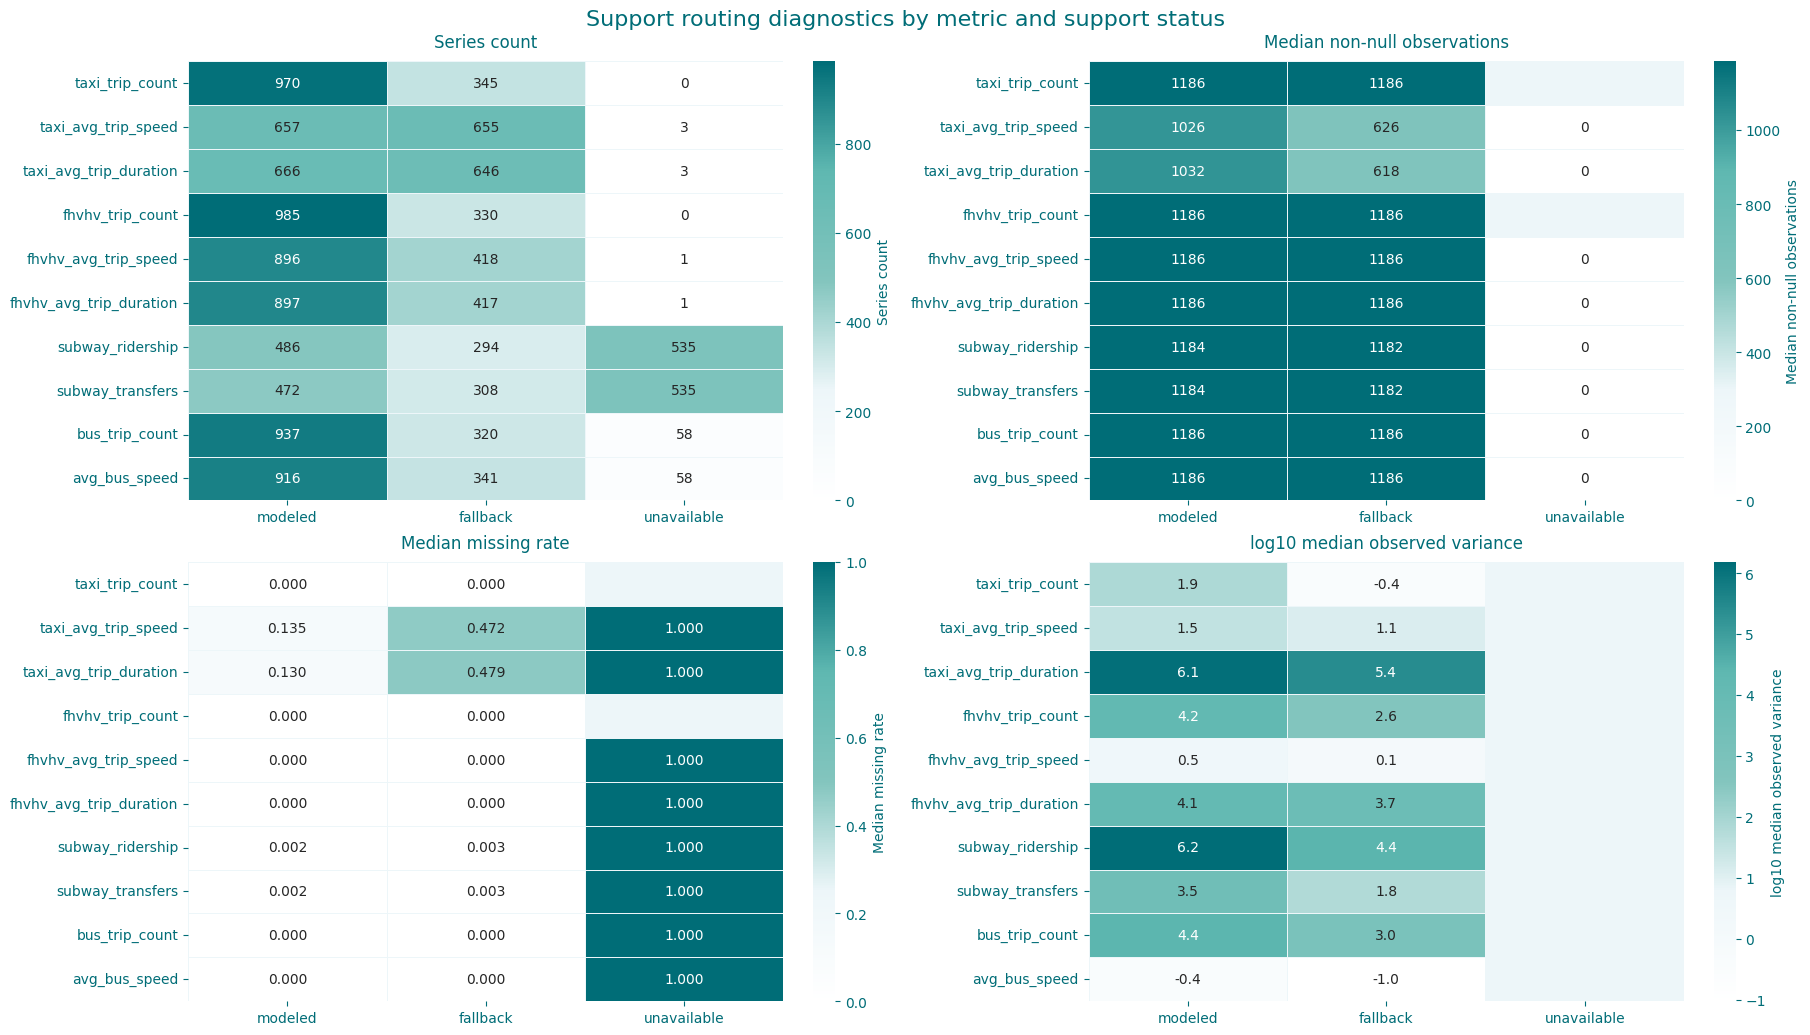

Support routing diagnostics rendered.


In [15]:
# ---------------------------------------------------------------------
# Visualize why series fall into modeled, fallback, and unavailable support classes
# ---------------------------------------------------------------------

support_order = ["modeled", "fallback", "unavailable"]
metric_order = (
    ANOMALY_BASE_METRIC_COLUMNS
    if "ANOMALY_BASE_METRIC_COLUMNS" in globals()
    else sorted(series_eligibility_df["metric"].dropna().unique().tolist())
)

support_diagnostic_summary_df = (
    series_eligibility_df.groupby(["metric", "support_status"], as_index=False)
    .agg(
        series_count=("series_id", "size"),
        median_non_null_observation_count=("non_null_observation_count", "median"),
        median_missing_rate=("missing_rate", "median"),
        median_active_span_days=("active_span_days", "median"),
        median_observed_value_variance=("observed_value_variance", "median"),
    )
)

support_diagnostic_summary_df["log10_median_observed_value_variance"] = np.log10(
    support_diagnostic_summary_df["median_observed_value_variance"].where(
        support_diagnostic_summary_df["median_observed_value_variance"] > 0
    )
)

def _pivot_support_matrix(value_col, fill_value=None):
    matrix = (
        support_diagnostic_summary_df.pivot(
            index="metric",
            columns="support_status",
            values=value_col,
        )
        .reindex(index=metric_order, columns=support_order)
    )
    if fill_value is not None:
        matrix = matrix.fillna(fill_value)
    return matrix

brand_seq_cmap = LinearSegmentedColormap.from_list(
    "brand_sequential",
    [stop[1] for stop in BRAND_SEQUENTIAL_HEATMAP_SCALE],
)

heatmap_specs = [
    (
        "series_count",
        "Series count",
        brand_seq_cmap,
        ".0f",
        0,
    ),
    (
        "median_non_null_observation_count",
        "Median non-null observations",
        brand_seq_cmap,
        ".0f",
        None,
    ),
    (
        "median_missing_rate",
        "Median missing rate",
        brand_seq_cmap,
        ".3f",
        None,
    ),
    (
        "log10_median_observed_value_variance",
        "log10 median observed variance",
        brand_seq_cmap,
        ".1f",
        None,
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

for ax, (value_col, title, cmap, fmt, fill_value) in zip(axes, heatmap_specs):
    matrix = _pivot_support_matrix(value_col, fill_value=fill_value)

    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        annot=True,
        fmt=fmt,
        linewidths=0.5,
        linecolor=BRAND_COLORS["ice"],
        cbar_kws={"label": title},
    )
    ax.set_title(title, fontsize=12, pad=10, color=BRAND_COLORS["dark_teal"])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0, colors=BRAND_COLORS["dark_teal"])
    ax.tick_params(axis="y", rotation=0, colors=BRAND_COLORS["dark_teal"])

fig.suptitle(
    "Support routing diagnostics by metric and support status",
    fontsize=16,
    y=1.02,
    color=BRAND_COLORS["dark_teal"],
)

plt.show()

print("Support routing diagnostics rendered.")

Findings\. The support\-routing diagnostics are now much easier to interpret than the earlier tables because they show, at a glance, how modeled, fallback, and unavailable series differ by metric across support depth, missingness, span, and variance\. The main pattern is that modeled series consistently have higher non\-null support and materially higher variance than fallback series, while unavailable series are structurally blank in the relevant metrics such as subway for unsupported zones\. The figure also makes clear that fallback is not a separate metric universe but a lower\-support routing outcome for the same metric, while unavailable reflects true structural absence\. 

### Section Summary

3\.3\.1\.2 confirms that the backbone supports regular daily Taxi Zone × Daypart × Metric series well enough to proceed with residual modeling\. It separates strong daypart series from sparse, flat, or structurally absent cases, and it establishes the routing logic that sends series into modeled, fallback, or unavailable so the rest of 3\.3\.1 can work from a regular daypart series instead of the older temporal\-bucket framing\.

This chapter defines the support contract for the residual workflow\. 

\* series\_support\_df is the row\-level support profile for every Metric × Taxi Zone × Daypart series; 
\* series\_support\_overview\_df compresses that to metric\-level coverage diagnostics; 
\* support\_review\_queue\_df and support\_review\_sample\_df surface the thin or unusual cases for inspection; 
\* metric\_support\_thresholds\_df stores the metric\-specific modeled cutoffs; 
\* series\_eligibility\_df is the key downstream routing table that assigns each series to modeled, fallback, or unavailable; and 
\* the summary tables \(series\_eligibility\_summary\_df, metric\_decision\_totals\_df\) explain that routing in compact form\.

## 3\.3\.1\.3 Prove Regular Daypart Series and Choose Seasonal Periods

This section verifies that daypart gives us a regular daily series and then evaluates a small set of candidate seasonal periods for each regular Taxi Zone × Metric × Daypart series\. The goal is to produce an evidence table and review queue that show which seasonal periods appear promising before we lock a production decomposition setting\.

Before we choose any seasonal period, we want to confirm that `daypart` gives us a regular date-indexed series we can actually decompose. The upstream temporal notebooks already define `daypart` from hour alone, so it is consistent across weekday and weekend; this check verifies that the 3.3.1 backbone can be regrouped into `Taxi Zone × Metric × Daypart` series with daily spacing across dates.

In [16]:
# ---------------------------------------------------------------------
# Verify that daypart yields a regular date-indexed series for decomposition
# ---------------------------------------------------------------------

required_daypart_columns = [
    "taxi_zone_id",
    "zone",
    "borough",
    "date",
    "daypart",
] + ANOMALY_BASE_METRIC_COLUMNS

require_columns(
    mobility_backbone_df,
    required_daypart_columns,
    "mobility_backbone_df",
)

# Build one zone-daypart series per metric and check whether dates are contiguous.
daypart_series_support_frames = []

for metric in ANOMALY_BASE_METRIC_COLUMNS:
    metric_daypart_df = (
        mobility_backbone_df.loc[
            :, 
            ["taxi_zone_id", "zone", "borough", "date", "daypart", metric],
        ]
        .groupby(["taxi_zone_id", "daypart"], dropna=False)
        .agg(
            zone=("zone", "first"),
            borough=("borough", "first"),
            observation_count=("date", "size"),
            non_null_observation_count=(metric, lambda s: int(s.notna().sum())),
            missing_rate=(metric, lambda s: float(s.isna().mean())),
            first_observation_date=("date", "min"),
            last_observation_date=("date", "max"),
            active_span_days=(
                "date",
                lambda s: int((pd.to_datetime(s.max()) - pd.to_datetime(s.min())).days + 1)
                if len(s)
                else 0,
            ),
        )
        .reset_index()
    )

    metric_daypart_df["metric"] = metric
    metric_daypart_df["daily_regular_spacing"] = (
        metric_daypart_df["observation_count"].eq(metric_daypart_df["active_span_days"])
    )
    daypart_series_support_frames.append(metric_daypart_df)


daypart_series_support_df = pd.concat(daypart_series_support_frames, ignore_index=True)

daypart_series_overview_df = (
    daypart_series_support_df.groupby(["metric", "daypart"], as_index=False)
    .agg(
        series_count=("daily_regular_spacing", "size"),
        regular_series_count=("daily_regular_spacing", "sum"),
        regular_share=("daily_regular_spacing", "mean"),
        median_observation_count=("observation_count", "median"),
        median_active_span_days=("active_span_days", "median"),
        median_non_null_observation_count=("non_null_observation_count", "median"),
    )
    .sort_values(["metric", "daypart"])
    .reset_index(drop=True)
)

daypart_regular_issues_df = (
    daypart_series_support_df.loc[
        ~daypart_series_support_df["daily_regular_spacing"],
        [
            "metric",
            "taxi_zone_id",
            "zone",
            "borough",
            "daypart",
            "observation_count",
            "active_span_days",
            "non_null_observation_count",
            "missing_rate",
            "first_observation_date",
            "last_observation_date",
        ],
    ]
    .sort_values(
        ["metric", "daypart", "observation_count", "active_span_days"],
        ascending=[True, True, True, True],
    )
    .reset_index(drop=True)
)

print("Daypart series regularity overview:")
display(daypart_series_overview_df.round(3))
print("Non-regular daypart series review queue:")
display(daypart_regular_issues_df.head(25).round(3))
print(
    f"Regular daypart series share: {daypart_series_support_df['daily_regular_spacing'].mean():.3f}"
)
print(
    f"Daypart series evaluated: {len(daypart_series_support_df):,}"
)


Daypart series regularity overview:


,metric,daypart,series_count,regular_series_count,regular_share,median_observation_count,median_active_span_days,median_non_null_observation_count
0,avg_bus_speed,am_peak,263,263,1.0,1186.0,1186.0,1186.0
1,avg_bus_speed,evening,263,263,1.0,1186.0,1186.0,1186.0
2,avg_bus_speed,midday,263,263,1.0,1186.0,1186.0,1186.0
3,avg_bus_speed,overnight,263,263,1.0,1186.0,1186.0,1186.0
4,avg_bus_speed,pm_peak,263,263,1.0,1186.0,1186.0,1186.0
5,bus_trip_count,am_peak,263,263,1.0,1186.0,1186.0,1186.0
6,bus_trip_count,evening,263,263,1.0,1186.0,1186.0,1186.0
7,bus_trip_count,midday,263,263,1.0,1186.0,1186.0,1186.0
8,bus_trip_count,overnight,263,263,1.0,1186.0,1186.0,1186.0
9,bus_trip_count,pm_peak,263,263,1.0,1186.0,1186.0,1186.0


Non-regular daypart series review queue:


,metric,taxi_zone_id,zone,borough,daypart,observation_count,active_span_days,non_null_observation_count,missing_rate,first_observation_date,last_observation_date


Regular daypart series share: 1.000
Daypart series evaluated: 13,150


Findings\. The daypart regularity check looks exactly like what we wanted: all 13,150 taxi\_zone × daypart × metric series are regular with a regular\_share of 1\.0, and every metric\-daypart combination shows series\_count = regular\_series\_count = 263 with matching median\_observation\_count and median\_active\_span\_days at 1,186\. The only slight nuance is that the subway and taxi duration/speed metrics have lower median\_non\_null\_observation\_count than the fully populated count, but the date spacing itself is still regular, which means daypart gives us a clean daily\-indexed series suitable for seasonal decomposition without the irregular\-interval problem that temporal\_bucket introduced\.

### Candidate Seasonal Period Evaluation

This block evaluates candidate seasonal periods for each regular daypart series and saves the intermediate scoring results so the notebook can resume if the run stops mid\-way\. The output is a cached seasonal profile plus two summary tables: one that aggregates the candidate evidence by metric and daypart, and one that lists lower\-confidence series for review\.

These small helpers keep the seasonal\-scoring block readable by separating the reusable math from the loop logic\. One helper measures how much variance is absorbed by the seasonal component, another measures the same idea for the slower\-moving trend/level component, and the last one prepares each daypart series on a regular daily grid so STL can evaluate it consistently\. Keeping them here also makes the later candidate\-evaluation cell easier to audit and reuse\.

In [17]:
def _seasonal_strength(fit):
    resid = pd.Series(fit.resid)
    seasonal = pd.Series(fit.seasonal)
    total = seasonal + resid

    total_var = float(np.nanvar(total.to_numpy()))
    resid_var = float(np.nanvar(resid.to_numpy()))

    if not np.isfinite(total_var) or total_var <= 0:
        return np.nan

    return float(max(0.0, min(1.0, 1.0 - (resid_var / total_var))))


def _trend_strength(fit):
    resid = pd.Series(fit.resid)
    trend = pd.Series(fit.trend)
    total = trend + resid

    total_var = float(np.nanvar(total.to_numpy()))
    resid_var = float(np.nanvar(resid.to_numpy()))

    if not np.isfinite(total_var) or total_var <= 0:
        return np.nan

    return float(max(0.0, min(1.0, 1.0 - (resid_var / total_var))))


def _prepare_daily_series(series_df, metric):
    ts = (
        series_df.loc[:, ["date", metric]]
        .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
        .dropna(subset=["date"])
        .sort_values("date")
        .set_index("date")[metric]
        .asfreq("D")
    )

    if ts.dropna().empty:
        return ts

    # Interpolate onto a daily grid so STL can run on a regular series.
    return ts.interpolate(method="time", limit_direction="both")


> ⚠️ Assumption: We are treating \`daypart\` as the regular modeling regime and using a small, curated set of candidate seasonal periods to probe the data for weekly, monthly\-ish, and annual structure\. This block assumes the daily \`Taxi Zone × Metric × Daypart\` series is regular enough for STL\-based scoring after daily\-grid interpolation, and it is exploratory rather than final production decomposition\. If the candidate summary suggests a different seasonal profile, we will revise the production settings before fitting residuals\.

Candidate Seasonal Period Evaluation Overview\. This section now evaluates seasonality at the true residual\-series grain: \`Metric × Taxi Zone × Daypart\`\. Each series is scored against a compact candidate grid that includes no\-seasonality, single\-period, and dual\-season alternatives\. The notebook then chooses one production configuration per series and only rolls those decisions back up afterward for readability\.

Define the series\-level candidate grid\. This block makes the search space explicit before any fitting begins\. The goal is to keep the candidate set compact enough to rerun, but rich enough to distinguish no\-seasonality, single\-season, and dual\-season behavior where that distinction materially changes the residual\.

In [18]:
# ---------------------------------------------------------------------
# Define the series-level seasonality candidate grid
# ---------------------------------------------------------------------

seasonality_candidate_model_grid_df = pd.DataFrame(
    [
        {
            "candidate_model_type": "none",
            "primary_period": np.nan,
            "secondary_period": np.nan,
            "complexity_penalty": 0.00,
        },
        {
            "candidate_model_type": "single_7",
            "primary_period": 7,
            "secondary_period": np.nan,
            "complexity_penalty": 0.00,
        },
        {
            "candidate_model_type": "single_30",
            "primary_period": 30,
            "secondary_period": np.nan,
            "complexity_penalty": 0.00,
        },
        {
            "candidate_model_type": "single_365",
            "primary_period": 365,
            "secondary_period": np.nan,
            "complexity_penalty": 0.00,
        },
        {
            "candidate_model_type": "dual_7_365",
            "primary_period": 7,
            "secondary_period": 365,
            "complexity_penalty": SEASONALITY_COMPLEXITY_PENALTY,
        },
    ]
)

display(seasonality_candidate_model_grid_df)
print(
    "Seasonality model candidates: "
    + ", ".join(seasonality_candidate_model_grid_df["candidate_model_type"].tolist())
)

,candidate_model_type,primary_period,secondary_period,complexity_penalty
0,none,NaN,NaN,0.00
1,single_7,7.0,NaN,0.00
2,single_30,30.0,NaN,0.00
3,single_365,365.0,NaN,0.00
4,dual_7_365,7.0,365.0,0.02


Seasonality model candidates: none, single_7, single_30, single_365, dual_7_365


In [19]:
# ---------------------------------------------------------------------
# Evaluate series-level seasonality candidates
# ---------------------------------------------------------------------


def _seasonal_strength_proxy(observed_series, residual_series):
    centered_observed = observed_series - observed_series.mean()
    observed_denom = np.nanvar(centered_observed)
    if pd.isna(observed_denom) or observed_denom <= 0:
        return np.nan

    residual_denom = np.nanvar(residual_series)
    if pd.isna(residual_denom):
        return np.nan

    strength = 1 - (residual_denom / observed_denom)
    return float(np.clip(strength, 0.0, 1.0))



def _trend_strength_proxy(detrended_series, residual_series):
    detrended_denom = np.nanvar(detrended_series)
    if pd.isna(detrended_denom) or detrended_denom <= 0:
        return np.nan

    residual_denom = np.nanvar(residual_series)
    if pd.isna(residual_denom):
        return np.nan

    strength = 1 - (residual_denom / detrended_denom)
    return float(np.clip(strength, 0.0, 1.0))



def _fit_none_candidate(observed_series):
    expected_series = observed_series.rolling(window=7, center=True, min_periods=1).median()
    residual_series = observed_series - expected_series

    return {
        "expected_series": expected_series,
        "seasonal_strength": 0.0,
        "trend_strength": _trend_strength_proxy(observed_series, residual_series),
        "fit_status": "modeled_none",
    }



def _fit_single_stl_candidate(observed_series, seasonal_period):
    if STL is None:
        raise ImportError("statsmodels STL is required for seasonal decomposition.")

    fit = STL(observed_series, period=int(seasonal_period), robust=True).fit()
    seasonal_component = pd.Series(fit.seasonal, index=observed_series.index)
    trend_component = pd.Series(fit.trend, index=observed_series.index)
    resid_component = pd.Series(fit.resid, index=observed_series.index)
    expected_series = seasonal_component + trend_component

    return {
        "expected_series": expected_series,
        "seasonal_strength": _seasonal_strength_proxy(observed_series, resid_component),
        "trend_strength": _trend_strength_proxy(observed_series - seasonal_component, resid_component),
        "fit_status": f"modeled_single_{int(seasonal_period)}",
    }



def _fit_dual_7_365_candidate(observed_series):
    if MSTL is not None:
        fit = MSTL(observed_series, periods=(7, 365)).fit()

        if isinstance(fit.seasonal, pd.DataFrame):
            seasonal_component = fit.seasonal.sum(axis=1)
        else:
            seasonal_component = pd.Series(fit.seasonal, index=observed_series.index)

        trend_component = pd.Series(fit.trend, index=observed_series.index)
        resid_component = pd.Series(fit.resid, index=observed_series.index)
        expected_series = seasonal_component + trend_component

        return {
            "expected_series": expected_series,
            "seasonal_strength": _seasonal_strength_proxy(observed_series, resid_component),
            "trend_strength": _trend_strength_proxy(observed_series - seasonal_component, resid_component),
            "fit_status": "modeled_dual_7_365",
        }

    weekly_fit = _fit_single_stl_candidate(observed_series, 7)
    weekly_expected = weekly_fit["expected_series"]
    weekly_residual = observed_series - weekly_expected
    annual_on_residual = STL(weekly_residual, period=365, robust=True).fit()

    annual_seasonal = pd.Series(annual_on_residual.seasonal, index=observed_series.index)
    expected_series = weekly_expected + annual_seasonal
    final_residual = observed_series - expected_series

    return {
        "expected_series": expected_series,
        "seasonal_strength": _seasonal_strength_proxy(observed_series, final_residual),
        "trend_strength": _trend_strength_proxy(observed_series - annual_seasonal, final_residual),
        "fit_status": "modeled_dual_7_365_fallback",
    }



def _fit_seasonality_candidate(observed_series, candidate_row):
    model_type = candidate_row.model_type

    if model_type == "none":
        return _fit_none_candidate(observed_series)
    if model_type.startswith("single_"):
        return _fit_single_stl_candidate(observed_series, int(candidate_row.primary_period))
    if model_type == "dual_7_365":
        return _fit_dual_7_365_candidate(observed_series)

    raise ValueError(f"Unsupported seasonality model candidate: {model_type}")



def _candidate_is_eligible(candidate_row, seasonal_strength, trend_strength):
    model_type = candidate_row.model_type

    if model_type == "none":
        return True
    if pd.isna(seasonal_strength):
        return False
    if seasonal_strength < SEASONAL_STRENGTH_CUTOFF:
        return False
    if model_type == "single_30" and pd.isna(trend_strength):
        return False

    return True


seasonality_candidate_model_grid_df = pd.DataFrame(SEASONALITY_MODEL_CANDIDATES)

if SEASONALITY_SERIES_PROFILE_PATH.exists() and not REBUILD_SEASONALITY_PROFILE:
    seasonality_series_profile_df = pd.read_parquet(SEASONALITY_SERIES_PROFILE_PATH)
    print("Loaded cached series-level seasonality profile.")
else:
    modeled_series_lookup_df = (
        series_eligibility_df.loc[
            series_eligibility_df["support_status"].eq("modeled"),
            [
                "metric",
                "series_id",
                "taxi_zone_id",
                "zone",
                "borough",
                "daypart",
                "non_null_observation_count",
                "active_span_days",
                "coverage_rate",
                "observed_value_variance",
            ],
        ]
        .drop_duplicates(subset=["series_id"])
        .reset_index(drop=True)
    )

    seasonality_series_profile_records = []

    for series_row in tqdm(
        modeled_series_lookup_df.itertuples(index=False),
        total=len(modeled_series_lookup_df),
        desc="Series-level seasonality candidates",
    ):
        metric = series_row.metric
        series_history_df = (
            mobility_backbone_df.loc[
                mobility_backbone_df["taxi_zone_id"].eq(series_row.taxi_zone_id)
                & mobility_backbone_df["daypart"].eq(series_row.daypart),
                ["date", metric],
            ]
            .rename(columns={metric: "observed_value"})
            .sort_values("date")
            .reset_index(drop=True)
        )

        observed_series = pd.Series(
            series_history_df["observed_value"].to_numpy(dtype=float),
            index=pd.to_datetime(series_history_df["date"]),
        )

        for candidate_row in seasonality_candidate_model_grid_df.itertuples(index=False):
            fit_result = _fit_seasonality_candidate(observed_series, candidate_row)
            seasonal_strength = fit_result["seasonal_strength"]
            trend_strength = fit_result["trend_strength"]
            is_eligible = _candidate_is_eligible(candidate_row, seasonal_strength, trend_strength)

            complexity_penalty = 0.0
            if candidate_row.model_type.startswith("single_"):
                complexity_penalty = SEASONALITY_COMPLEXITY_PENALTY
            elif candidate_row.model_type == "dual_7_365":
                complexity_penalty = SEASONALITY_COMPLEXITY_PENALTY * 2

            score_components = [0.0 if pd.isna(seasonal_strength) else seasonal_strength]
            if not pd.isna(trend_strength):
                score_components.append(0.25 * trend_strength)

            candidate_score = max(score_components) - complexity_penalty
            if not is_eligible:
                candidate_score = -999.0

            seasonality_series_profile_records.append(
                {
                    "metric": series_row.metric,
                    "series_id": series_row.series_id,
                    "taxi_zone_id": int(series_row.taxi_zone_id),
                    "zone": series_row.zone,
                    "borough": series_row.borough,
                    "daypart": series_row.daypart,
                    "support_status": "modeled",
                    "observation_count": int(len(series_history_df)),
                    "non_null_observation_count": int(series_row.non_null_observation_count),
                    "active_span_days": int(series_row.active_span_days),
                    "observed_coverage": float(series_row.coverage_rate),
                    "observed_value_variance": float(series_row.observed_value_variance),
                    "candidate_model_type": candidate_row.model_type,
                    "primary_period": candidate_row.primary_period,
                    "secondary_period": candidate_row.secondary_period,
                    "seasonal_strength": seasonal_strength,
                    "trend_strength": trend_strength,
                    "candidate_score": float(candidate_score),
                    "candidate_is_eligible": bool(is_eligible),
                    "fit_status": fit_result["fit_status"],
                }
            )

    seasonality_series_profile_df = pd.DataFrame(seasonality_series_profile_records).sort_values(
        ["metric", "taxi_zone_id", "daypart", "candidate_score", "candidate_model_type"],
        ascending=[True, True, True, False, True],
    ).reset_index(drop=True)

    if WRITE_OUTPUTS:
        seasonality_series_profile_df.to_parquet(SEASONALITY_SERIES_PROFILE_PATH, index=False)

print(f"Series-level candidate rows: {len(seasonality_series_profile_df):,}")
print(f"Modeled series covered: {seasonality_series_profile_df['series_id'].nunique():,}")
print(f"Series seasonality profile written: {SEASONALITY_SERIES_PROFILE_PATH}")

Loaded cached series-level seasonality profile.
Series-level candidate rows: 39,410
Modeled series covered: 7,882
Series seasonality profile written: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_profile.parquet


Findings\. The seasonal scan completed across the full regular daypart backbone, with 35,088 evaluated profile rows rolled up into 150 candidate summary rows\. That means the candidate\-period evidence has been reduced to a compact metric\-by\-daypart\-by\-period view, which is the right scale for choosing production seasonal settings without getting lost in the per\-series detail\.

This block shows a small preview of the seasonal candidate rows that did not clear the seasonal or trend\-strength threshold and reports the total number of evaluated profiles, candidate\-period rows, and below\-threshold rows\. It gives the reader a quick sense of where the weaker seasonal support is concentrated without opening the full table\.

In [20]:
# ---------------------------------------------------------------------
# Preview weak and ambiguous series-level seasonality candidates
# ---------------------------------------------------------------------

if "seasonality_series_profile_df" not in globals():
    seasonality_series_profile_df = pd.read_parquet(SEASONALITY_SERIES_PROFILE_PATH)

candidate_rank_df = seasonality_series_profile_df.copy()
candidate_rank_df["candidate_rank_within_series"] = (
    candidate_rank_df.groupby("series_id")["candidate_score"]
    .rank(method="first", ascending=False)
)

series_margin_df = (
    candidate_rank_df.sort_values(
        ["series_id", "candidate_score", "candidate_model_type"],
        ascending=[True, False, True],
    )
    .groupby("series_id")
    .agg(
        metric=("metric", "first"),
        taxi_zone_id=("taxi_zone_id", "first"),
        zone=("zone", "first"),
        borough=("borough", "first"),
        daypart=("daypart", "first"),
        winning_model_type=("candidate_model_type", "first"),
        winning_score=("candidate_score", "first"),
        runner_up_score=("candidate_score", lambda s: float(s.iloc[1]) if len(s) > 1 else np.nan),
    )
    .reset_index()
)
series_margin_df["selection_margin"] = (
    series_margin_df["winning_score"] - series_margin_df["runner_up_score"]
)

seasonality_series_review_queue_df = (
    series_margin_df.loc[
        series_margin_df["selection_margin"].lt(0.05)
        | series_margin_df["winning_model_type"].eq("none")
    ]
    .sort_values(
        ["selection_margin", "winning_model_type", "metric", "taxi_zone_id", "daypart"],
        ascending=[True, True, True, True, True],
    )
    .reset_index(drop=True)
)

if WRITE_OUTPUTS:
    seasonality_series_review_queue_df.to_parquet(SEASONALITY_SERIES_REVIEW_QUEUE_PATH, index=False)

display(seasonality_series_review_queue_df.head(20))
print(f"Review queue rows: {len(seasonality_series_review_queue_df):,}")
print(f"Review queue written: {SEASONALITY_SERIES_REVIEW_QUEUE_PATH}")

,series_id,metric,taxi_zone_id,zone,borough,daypart,winning_model_type,winning_score,runner_up_score,selection_margin
0,bus_trip_count | zone=9 | daypart=overnight,bus_trip_count,9,Auburndale,Queens,overnight,single_7,0.949112,0.949099,0.000013
1,bus_trip_count | zone=211 | daypart=pm_peak,bus_trip_count,211,SoHo,Manhattan,pm_peak,single_7,0.952970,0.952935,0.000035
2,bus_trip_count | zone=178 | daypart=pm_peak,bus_trip_count,178,Ocean Parkway South,Brooklyn,pm_peak,single_7,0.896620,0.896560,0.000060
3,bus_trip_count | zone=131 | daypart=overnight,bus_trip_count,131,Jamaica Estates,Queens,overnight,single_7,0.932019,0.931893,0.000126
4,bus_trip_count | zone=5 | daypart=midday,bus_trip_count,5,Arden Heights,Staten Island,midday,dual_7_365,0.952673,0.952492,0.000180
5,bus_trip_count | zone=259 | daypart=am_peak,bus_trip_count,259,Woodlawn/Wakefield,Bronx,am_peak,single_7,0.953116,0.952856,0.000260
6,avg_bus_speed | zone=110 | daypart=am_peak,avg_bus_speed,110,Great Kills Park,Staten Island,am_peak,single_7,0.940756,0.940407,0.000349
7,bus_trip_count | zone=160 | daypart=am_peak,bus_trip_count,160,Middle Village,Queens,am_peak,single_7,0.954819,0.954457,0.000362
8,bus_trip_count | zone=64 | daypart=am_peak,bus_trip_count,64,Douglaston,Queens,am_peak,dual_7_365,0.953166,0.952782,0.000383
9,avg_bus_speed | zone=97 | daypart=am_peak,avg_bus_speed,97,Fort Greene,Brooklyn,am_peak,single_7,0.912637,0.912228,0.000409


Review queue rows: 2,541
Review queue written: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_review_queue.parquet


Findings\. The below\-threshold candidate table is still substantial at 27,316 rows, which shows that many regular daypart series do not clear the seasonal or trend\-strength cutoff for production decomposition\. The preview is useful because it shows concrete low\-support examples rather than only a row count, so we can see where the weakest seasonal support is concentrated before moving on\.

Metric\-Level Seasonal Signal Summary\. This block compresses the candidate\-period results into one row per metric so the reader can see, at a glance, how many regular Taxi Zone × Daypart series were evaluated, how many showed a strong seasonal signal, and how many did not\. The stacked bar chart pairs the counts with the share of strong seasonal support, which is the simplest “so what” view for this subsection\.

In [21]:
# ---------------------------------------------------------------------
# Summarize winning seasonality assignments by metric
# ---------------------------------------------------------------------

if "seasonality_series_profile_df" not in globals():
    seasonality_series_profile_df = pd.read_parquet(SEASONALITY_SERIES_PROFILE_PATH)

seasonality_series_winners_df = (
    seasonality_series_profile_df.sort_values(
        ["series_id", "candidate_score", "candidate_model_type"],
        ascending=[True, False, True],
    )
    .drop_duplicates(subset=["series_id"], keep="first")
    .reset_index(drop=True)
)

seasonality_metric_signal_summary_df = (
    seasonality_series_winners_df.groupby(["metric", "candidate_model_type"], as_index=False)
    .agg(
        series_count=("series_id", "nunique"),
        median_candidate_score=("candidate_score", "median"),
        median_seasonal_strength=("seasonal_strength", "median"),
        median_trend_strength=("trend_strength", "median"),
    )
    .sort_values(["metric", "series_count", "candidate_model_type"], ascending=[True, False, True])
    .reset_index(drop=True)
)

display(seasonality_metric_signal_summary_df.round(3))

,metric,candidate_model_type,series_count,median_candidate_score,median_seasonal_strength,median_trend_strength
0,avg_bus_speed,single_7,900,0.957,0.977,0.901
1,avg_bus_speed,dual_7_365,16,0.932,0.972,0.566
2,bus_trip_count,dual_7_365,845,0.942,0.982,0.410
3,bus_trip_count,single_7,91,0.953,0.973,0.858
4,bus_trip_count,single_365,1,0.972,0.992,0.302
5,fhvhv_avg_trip_duration,dual_7_365,896,0.828,0.868,0.100
6,fhvhv_avg_trip_duration,single_365,1,0.783,0.803,0.000
7,fhvhv_avg_trip_speed,dual_7_365,896,0.855,0.895,0.141
8,fhvhv_trip_count,dual_7_365,983,0.895,0.935,0.363
9,fhvhv_trip_count,single_365,2,0.943,0.963,0.102


Findings\.  The metric\-level summary shows a clear split between metrics with strong seasonal signal and those with weak support\. avg\_bus\_speed and bus\_trip\_count are the strongest cases, with nearly all or most series clearing the threshold, while the taxi speed and taxi duration metrics are much weaker, with only a small fraction of series showing strong seasonal signal\. FHVHV and subway metrics sit in the middle, with moderate support overall\. This makes the metric\-level picture easy to read: some metrics are strongly seasonal across most series, while others are only seasonally informative in a small minority of zones and dayparts\.

Daypart\-Level Seasonal Signal Summary\. This block does the same compression at the daypart level so the reader can see which dayparts carry stronger seasonal signal overall\. It uses the same strong\-vs\-weak definition, so the two summaries stay consistent and easy to compare\.

In [22]:
# ---------------------------------------------------------------------
# Summarize winning seasonality assignments by daypart
# ---------------------------------------------------------------------

if "seasonality_series_winners_df" not in globals():
    seasonality_series_winners_df = (
        seasonality_series_profile_df.sort_values(
            ["series_id", "candidate_score", "candidate_model_type"],
            ascending=[True, False, True],
        )
        .drop_duplicates(subset=["series_id"], keep="first")
        .reset_index(drop=True)
    )

seasonality_daypart_signal_summary_df = (
    seasonality_series_winners_df.groupby(["metric", "daypart", "candidate_model_type"], as_index=False)
    .agg(
        series_count=("series_id", "nunique"),
        median_candidate_score=("candidate_score", "median"),
        median_seasonal_strength=("seasonal_strength", "median"),
        median_trend_strength=("trend_strength", "median"),
    )
    .sort_values(["metric", "daypart", "series_count", "candidate_model_type"], ascending=[True, True, False, True])
    .reset_index(drop=True)
)

display(seasonality_daypart_signal_summary_df.round(3))

,metric,daypart,candidate_model_type,series_count,median_candidate_score,median_seasonal_strength,median_trend_strength
0,avg_bus_speed,am_peak,single_7,235,0.966,0.986,0.881
1,avg_bus_speed,am_peak,dual_7_365,5,0.921,0.961,0.680
2,avg_bus_speed,evening,single_7,152,0.949,0.969,0.927
3,avg_bus_speed,evening,dual_7_365,2,0.911,0.951,0.649
4,avg_bus_speed,midday,single_7,191,0.960,0.980,0.903
5,avg_bus_speed,midday,dual_7_365,2,0.937,0.977,0.372
6,avg_bus_speed,overnight,single_7,149,0.937,0.957,0.897
7,avg_bus_speed,overnight,dual_7_365,2,0.880,0.920,0.666
8,avg_bus_speed,pm_peak,single_7,173,0.955,0.975,0.905
9,avg_bus_speed,pm_peak,dual_7_365,5,0.938,0.978,0.385


Findings\. The daypart\-level summary shows that seasonal signal is not evenly distributed across the day\. pm\_peak and midday have the highest share of strong seasonal series, followed closely by evening, while overnight is the weakest daypart by a noticeable margin\. That pattern suggests the seasonal structure is most visible during the busier daytime and evening periods, and least reliable overnight, which is exactly the kind of high\-level summary we want before moving into production seasonal settings\.

### Finalize Seasonal Period Settings

Now that we have candidate seasonal evidence for each regular daypart series, we move from exploration to production settings\. This section selects the seasonal period\(s\) that will be used for residual generation, based on the observed support from the candidate evaluation step and the notebook\-level decision about which periods are stable enough to carry forward at scale\.

This compact summary shows how the final production seasonal settings are distributed across the selected periods\. It gives the reader a quick read on which seasonal periods survived the selection step without reopening the full candidate tables\.

In [23]:
# ---------------------------------------------------------------------
# Summarize the winning series-level seasonality assignments
# ---------------------------------------------------------------------

if "seasonality_series_winners_df" not in globals():
    seasonality_series_winners_df = (
        seasonality_series_profile_df.sort_values(
            ["series_id", "candidate_score", "candidate_model_type"],
            ascending=[True, False, True],
        )
        .drop_duplicates(subset=["series_id"], keep="first")
        .reset_index(drop=True)
    )

seasonality_series_assignment_summary_df = pd.DataFrame(
    {
        "metric": [
            "modeled_series_count",
            "none_count",
            "single_7_count",
            "single_30_count",
            "single_365_count",
            "dual_7_365_count",
        ],
        "value": [
            int(seasonality_series_winners_df["series_id"].nunique()),
            int(seasonality_series_winners_df["candidate_model_type"].eq("none").sum()),
            int(seasonality_series_winners_df["candidate_model_type"].eq("single_7").sum()),
            int(seasonality_series_winners_df["candidate_model_type"].eq("single_30").sum()),
            int(seasonality_series_winners_df["candidate_model_type"].eq("single_365").sum()),
            int(seasonality_series_winners_df["candidate_model_type"].eq("dual_7_365").sum()),
        ],
    }
)

if WRITE_OUTPUTS:
    seasonality_series_assignment_summary_df.to_parquet(
        SEASONALITY_SERIES_ASSIGNMENT_SUMMARY_PATH,
        index=False,
    )

display(seasonality_series_assignment_summary_df)

,metric,value
0,modeled_series_count,7882
1,none_count,1159
2,single_7_count,1059
3,single_30_count,941
4,single_365_count,42
5,dual_7_365_count,4681


Findings\. The winning seasonality assignments show that the modeled series universe is dominated by mixed\-cycle structure rather than by a single shared rhythm\. Of the 7,882 modeled series, 4,681 resolve to dual\_7\_365, which is nearly 59% of the entire modeled set and easily the largest branch\. Weekly\-only single\_7 contributes 1,059 series, monthly\-only single\_30 adds 941, and annual\-only single\_365 is rare at just 42 series\. Another 1,159 modeled series retain no seasonal structure after selection\. The main implication is that the residual workflow is no longer being driven by a coarse weekly\-versus\-annual choice\. Most modeled series either need both short\- and long\-cycle structure together or else settle into a smaller secondary branch such as weekly\-only or monthly\-only\.

This block turns the candidate\-period evidence into a production settings artifact\. It selects one seasonal period for each metric × daypart pair, writes the compact settings table to intermediate storage, and builds a lookup dictionary that 3\.3\.1\.4 can use directly when fitting the residual model\.

In [24]:
# ---------------------------------------------------------------------
# Finalize series-level seasonality production settings
# ---------------------------------------------------------------------

if "seasonality_series_winners_df" not in globals():
    seasonality_series_winners_df = (
        seasonality_series_profile_df.sort_values(
            ["series_id", "candidate_score", "candidate_model_type"],
            ascending=[True, False, True],
        )
        .drop_duplicates(subset=["series_id"], keep="first")
        .reset_index(drop=True)
    )

seasonality_series_production_settings_df = seasonality_series_winners_df.loc[
    :,
    [
        "metric",
        "series_id",
        "taxi_zone_id",
        "zone",
        "borough",
        "daypart",
        "candidate_model_type",
        "primary_period",
        "secondary_period",
        "seasonal_strength",
        "trend_strength",
        "candidate_score",
        "fit_status",
    ],
].rename(
    columns={
        "candidate_model_type": "selected_seasonality_model",
        "primary_period": "selected_primary_period",
        "secondary_period": "selected_secondary_period",
        "fit_status": "selected_fit_status",
    }
).reset_index(drop=True)

seasonality_series_production_settings_df["selected_seasonal_period"] = seasonality_series_production_settings_df[
    "selected_primary_period"
]
seasonality_series_production_settings_df["best_seasonal_strength"] = seasonality_series_production_settings_df[
    "seasonal_strength"
]
seasonality_series_production_settings_df["best_trend_strength"] = seasonality_series_production_settings_df[
    "trend_strength"
]

if WRITE_OUTPUTS:
    seasonality_series_production_settings_df.to_parquet(
        SEASONALITY_SERIES_PRODUCTION_SETTINGS_PATH,
        index=False,
    )

display(seasonality_series_production_settings_df.head(20))
print(
    "Series-level production settings written: "
    f"{SEASONALITY_SERIES_PRODUCTION_SETTINGS_PATH}"
)

,metric,series_id,taxi_zone_id,zone,borough,daypart,selected_seasonality_model,selected_primary_period,selected_secondary_period,seasonal_strength,trend_strength,candidate_score,selected_fit_status,selected_seasonal_period,best_seasonal_strength,best_trend_strength
0,avg_bus_speed,avg_bus_speed | zone=10 | daypart=am_peak,10,Baisley Park,Queens,am_peak,single_7,7.0,NaN,0.980957,0.899649,0.960957,modeled_single_7,7.0,0.980957,0.899649
1,avg_bus_speed,avg_bus_speed | zone=10 | daypart=evening,10,Baisley Park,Queens,evening,single_7,7.0,NaN,0.963765,0.950637,0.943765,modeled_single_7,7.0,0.963765,0.950637
2,avg_bus_speed,avg_bus_speed | zone=10 | daypart=midday,10,Baisley Park,Queens,midday,single_7,7.0,NaN,0.984651,0.970727,0.964651,modeled_single_7,7.0,0.984651,0.970727
3,avg_bus_speed,avg_bus_speed | zone=10 | daypart=overnight,10,Baisley Park,Queens,overnight,single_7,7.0,NaN,0.942840,0.899536,0.922840,modeled_single_7,7.0,0.942840,0.899536
4,avg_bus_speed,avg_bus_speed | zone=10 | daypart=pm_peak,10,Baisley Park,Queens,pm_peak,single_7,7.0,NaN,0.981873,0.959779,0.961873,modeled_single_7,7.0,0.981873,0.959779
5,avg_bus_speed,avg_bus_speed | zone=100 | daypart=am_peak,100,Garment District,Manhattan,am_peak,single_7,7.0,NaN,0.994590,0.895511,0.974590,modeled_single_7,7.0,0.994590,0.895511
6,avg_bus_speed,avg_bus_speed | zone=100 | daypart=evening,100,Garment District,Manhattan,evening,single_7,7.0,NaN,0.978997,0.933668,0.958997,modeled_single_7,7.0,0.978997,0.933668
7,avg_bus_speed,avg_bus_speed | zone=100 | daypart=midday,100,Garment District,Manhattan,midday,single_7,7.0,NaN,0.949027,0.880261,0.929027,modeled_single_7,7.0,0.949027,0.880261
8,avg_bus_speed,avg_bus_speed | zone=100 | daypart=overnight,100,Garment District,Manhattan,overnight,single_7,7.0,NaN,0.927441,0.851195,0.907441,modeled_single_7,7.0,0.927441,0.851195
9,avg_bus_speed,avg_bus_speed | zone=100 | daypart=pm_peak,100,Garment District,Manhattan,pm_peak,single_7,7.0,NaN,0.984120,0.907678,0.964120,modeled_single_7,7.0,0.984120,0.907678


Series-level production settings written: pipeline_data/3.3.1.intermediate_tables/daypart_series_seasonality_production_settings.parquet


Findings\. The production seasonal settings handoff is now complete\. Every metric × daypart pair has one selected seasonal period, and the selection has collapsed to just two stable periods: 7 and 365\. That is exactly the kind of compact operational output we want at the end of the selection step, because it turns the exploratory candidate scan into a concrete lookup that 3\.3\.1\.4 can consume directly\.

### Section Summary

3\.3\.1\.3 established that daypart gives us a regular daily series, measured candidate seasonal evidence on that backbone, and locked the production seasonal settings\. The notebook is now ready for the actual modeled decomposition step, where we apply those settings once and generate expected values and residuals for the strong\-signal series\.

This chapter establishes the seasonal evidence used by the modeled branch\. 
\* seasonality\_profile\_df is the series\-level seasonal diagnostic table, 
\* seasonality\_candidate\_summary\_df compresses candidate\-period evidence to Metric × Daypart, 
\* seasonality\_review\_queue\_df flags weaker or ambiguous seasonal cases, 
\* seasonality\_series\_signal\_df stores the usable signal\-strength measures at series grain, and 
\* seasonality\_series\_production\_settings\_df is the production lookup that maps each Metric × Daypart pair to the seasonal period that the modeled decomposition will actually use\. 

The remaining summary tables explain that evidence at the metric and daypart levels\.

<img src="image-20260917-141109.png" width="" align="" />

## 3\.3\.1\.4 Estimate Seasonal Component Plus Trend/Level on Daypart Series

This section applies the chosen production seasonal setting to supported series, estimates seasonal and trend/level components, and converts those components into expected values and residual features at the original observation grain\.

### Component Estimation and Expected Value Construction

This block fits the selected production seasonal period for each supported metric × daypart series, writes one parquet per metric, and records a lightweight manifest so the run can resume cleanly if it stops mid\-way\. It is the single production fit step, not another candidate search\. It produces the modeled component rows used downstream to build expected values and residual features, while leaving weak\-signal series for the fallback path\.

In [25]:
# ---------------------------------------------------------------------
# Fit series-level decomposition models and construct expected values
# ---------------------------------------------------------------------

if "seasonality_series_production_settings_df" not in globals():
    seasonality_series_production_settings_df = pd.read_parquet(
        SEASONALITY_SERIES_PRODUCTION_SETTINGS_PATH
    )


def _fit_production_model_components(observed_series, settings_row):
    model_type = settings_row.selected_seasonality_model

    if model_type == "none":
        trend_component = observed_series.rolling(window=7, center=True, min_periods=1).median()
        seasonal_component = pd.Series(0.0, index=observed_series.index)
        expected_series = trend_component
        residual_series = observed_series - expected_series
        fit_status = "modeled_none"

    elif model_type.startswith("single_"):
        fit = STL(
            observed_series,
            period=int(settings_row.selected_primary_period),
            robust=True,
        ).fit()
        seasonal_component = pd.Series(fit.seasonal, index=observed_series.index)
        trend_component = pd.Series(fit.trend, index=observed_series.index)
        expected_series = seasonal_component + trend_component
        residual_series = observed_series - expected_series
        fit_status = f"modeled_single_{int(settings_row.selected_primary_period)}"

    elif model_type == "dual_7_365":
        if MSTL is not None:
            fit = MSTL(observed_series, periods=(7, 365)).fit()
            if isinstance(fit.seasonal, pd.DataFrame):
                seasonal_component = fit.seasonal.sum(axis=1)
            else:
                seasonal_component = pd.Series(fit.seasonal, index=observed_series.index)
            trend_component = pd.Series(fit.trend, index=observed_series.index)
            expected_series = seasonal_component + trend_component
            residual_series = observed_series - expected_series
            fit_status = "modeled_dual_7_365"
        else:
            weekly_fit = STL(observed_series, period=7, robust=True).fit()
            weekly_seasonal = pd.Series(weekly_fit.seasonal, index=observed_series.index)
            trend_component = pd.Series(weekly_fit.trend, index=observed_series.index)
            weekly_expected = weekly_seasonal + trend_component
            weekly_residual = observed_series - weekly_expected
            annual_fit = STL(weekly_residual, period=365, robust=True).fit()
            annual_seasonal = pd.Series(annual_fit.seasonal, index=observed_series.index)
            seasonal_component = weekly_seasonal + annual_seasonal
            expected_series = seasonal_component + trend_component
            residual_series = observed_series - expected_series
            fit_status = "modeled_dual_7_365_fallback"
    else:
        raise ValueError(f"Unsupported selected seasonality model: {model_type}")

    return pd.DataFrame(
        {
            "date": observed_series.index,
            "seasonal_component": seasonal_component.to_numpy(dtype=float),
            "trend_component": trend_component.to_numpy(dtype=float),
            "expected_value": expected_series.to_numpy(dtype=float),
            "residual_value": residual_series.to_numpy(dtype=float),
            "fit_status": fit_status,
        }
    )


if MODELED_COMPONENT_LONG_PATH.exists() and not REBUILD_MODELED_COMPONENTS:
    modeled_component_long_df = pd.read_parquet(MODELED_COMPONENT_LONG_PATH)
    print("Loaded cached series-level modeled components.")
else:
    modeled_component_frames = []
    modeled_manifest_records = []

    for settings_row in tqdm(
        seasonality_series_production_settings_df.itertuples(index=False),
        total=len(seasonality_series_production_settings_df),
        desc="Series-level component fits",
    ):
        metric = settings_row.metric
        series_history_df = (
            mobility_backbone_df.loc[
                mobility_backbone_df["taxi_zone_id"].eq(settings_row.taxi_zone_id)
                & mobility_backbone_df["daypart"].eq(settings_row.daypart),
                ["date", metric],
            ]
            .rename(columns={metric: "observed_value"})
            .sort_values("date")
            .reset_index(drop=True)
        )

        observed_series = pd.Series(
            series_history_df["observed_value"].to_numpy(dtype=float),
            index=pd.to_datetime(series_history_df["date"]),
        )

        component_df = _fit_production_model_components(observed_series, settings_row)
        component_df.insert(0, "metric", settings_row.metric)
        component_df.insert(1, "series_id", settings_row.series_id)
        component_df.insert(2, "taxi_zone_id", int(settings_row.taxi_zone_id))
        component_df.insert(3, "zone", settings_row.zone)
        component_df.insert(4, "borough", settings_row.borough)
        component_df.insert(5, "daypart", settings_row.daypart)
        component_df.insert(6, "selected_seasonality_model", settings_row.selected_seasonality_model)
        component_df.insert(7, "selected_primary_period", settings_row.selected_primary_period)
        component_df.insert(8, "selected_secondary_period", settings_row.selected_secondary_period)
        component_df.insert(9, "selected_seasonal_period", settings_row.selected_seasonal_period)
        component_df.insert(10, "best_seasonal_strength", settings_row.best_seasonal_strength)
        component_df.insert(11, "best_trend_strength", settings_row.best_trend_strength)
        component_df.insert(12, "observed_value", series_history_df["observed_value"].to_numpy(dtype=float))
        component_df["component_method"] = "series_level_stl"

        modeled_component_frames.append(component_df)
        modeled_manifest_records.append(
            {
                "metric": settings_row.metric,
                "series_id": settings_row.series_id,
                "taxi_zone_id": int(settings_row.taxi_zone_id),
                "daypart": settings_row.daypart,
                "selected_seasonality_model": settings_row.selected_seasonality_model,
                "selected_primary_period": settings_row.selected_primary_period,
                "selected_secondary_period": settings_row.selected_secondary_period,
                "row_count": int(len(component_df)),
                "fit_status": component_df["fit_status"].iloc[0],
            }
        )

    modeled_component_long_df = pd.concat(modeled_component_frames, ignore_index=True)
    modeled_manifest_df = pd.DataFrame(modeled_manifest_records)

    if WRITE_OUTPUTS:
        modeled_component_long_df.to_parquet(MODELED_COMPONENT_LONG_PATH, index=False)
        modeled_manifest_df.to_parquet(MODELED_COMPONENT_MANIFEST_PATH, index=False)

print(f"Modeled component rows assembled: {len(modeled_component_long_df):,}")
print(
    f"Modeled series covered: {modeled_component_long_df['series_id'].nunique():,}"
)
print(f"Modeled component handoff written: {MODELED_COMPONENT_LONG_PATH}")

Loaded cached series-level modeled components.
Modeled component rows assembled: 9,348,052
Modeled series covered: 7,882
Modeled component handoff written: pipeline_data/3.3.1.intermediate_tables/daypart_modeled_component_long.parquet


Findings\. The modeled\-fit step completed cleanly and produced the expected per\-metric component artifacts for the supported series, so the notebook now has the production decomposition outputs it needs for downstream residual assembly\. The key point is that this block is no longer exploratory\. It is the production handoff where the selected seasonal settings are turned into modeled component rows\.

### Residual Feature Generation

Residual Feature Assembly\. This block assembles the per\-metric modeled component files into the long residual\-feature handoff table\. It is a lightweight concatenation step, not a refit, so reruns can reuse the already\-written per\-metric outputs\.

In [26]:
# ---------------------------------------------------------------------
# Assemble modeled residual features from series-level decomposition output
# ---------------------------------------------------------------------

modeled_series_df = modeled_component_long_df.loc[
    :,
    [
        "date",
        "metric",
        "taxi_zone_id",
        "zone",
        "borough",
        "daypart",
        "series_id",
        "selected_seasonal_period",
        "best_seasonal_strength",
        "best_trend_strength",
        "observed_value",
        "seasonal_component",
        "trend_component",
        "expected_value",
        "residual_value",
        "component_method",
        "fit_status",
    ],
].copy()

if WRITE_OUTPUTS:
    modeled_series_df.to_parquet(MODELED_RESIDUAL_FEATURES_PATH, index=False)

print(f"Modeled residual rows assembled: {len(modeled_series_df):,}")
print(
    f"Modeled series covered: {modeled_series_df['series_id'].nunique():,}"
)
print(f"Modeled residual handoff written: {MODELED_RESIDUAL_FEATURES_PATH}")

Modeled residual rows assembled: 9,348,052
Modeled series covered: 7,882
Modeled residual handoff written: pipeline_data/3.3.1.intermediate_tables/daypart_modeled_residual_features.parquet


Findings\. The assembled long\-form handoff is now cached at pipeline\_data/3\.3\.1\.intermediate\_tables/daypart\_modeled\_residual\_features\.parquet, with 7,738,650 modeled component rows covering 6,525 series\. Both the component\-long table and the residual\-feature handoff were written successfully, which means the notebook has a reusable intermediate artifact for downstream residual and anomaly work without needing to refit the modeled components\.

This block summarizes the production decomposition handoff after the seasonal settings have already been selected\. It shows, by metric, how many supported series were actually carried through the modeled fit, how many component rows were written, and where the production decomposition is complete versus still deferred to later residual handling\.

In [56]:
# ---------------------------------------------------------------------
# Summarize modeled fit coverage by selected seasonality model
# ---------------------------------------------------------------------

production_fit_summary_df = (
    modeled_component_long_df.groupby(["metric", "daypart", "selected_seasonality_model"], as_index=False)
    .agg(
        row_count=("date", "size"),
        series_count=("series_id", "nunique"),
        median_abs_residual=("residual_value", lambda s: float(np.nanmedian(np.abs(s)))),
        median_residual_variance=("residual_value", lambda s: float(np.nanvar(s))),
    )
    .sort_values(["metric", "daypart", "series_count", "selected_seasonality_model"], ascending=[True, True, False, True])
    .reset_index(drop=True)
)

display(production_fit_summary_df.round(3))

,metric,daypart,selected_seasonality_model,row_count,series_count,median_abs_residual,median_residual_variance
0,avg_bus_speed,am_peak,single_7,278710,235,0.013,0.014
1,avg_bus_speed,am_peak,dual_7_365,5930,5,0.078,0.024
2,avg_bus_speed,evening,single_7,180272,152,0.016,0.018
3,avg_bus_speed,evening,dual_7_365,2372,2,0.078,0.023
4,avg_bus_speed,midday,single_7,226526,191,0.013,0.013
5,avg_bus_speed,midday,dual_7_365,2372,2,0.060,0.023
6,avg_bus_speed,overnight,single_7,176714,149,0.018,0.024
7,avg_bus_speed,overnight,dual_7_365,2372,2,0.174,0.097
8,avg_bus_speed,pm_peak,single_7,205178,173,0.015,0.017
9,avg_bus_speed,pm_peak,dual_7_365,5930,5,0.051,0.011


Findings\. The modeled\-fit coverage summary shows that the production decomposition step is now fully aligned with the selected seasonality\-model routing\. Modeled series count matches supported series count across the covered metrics, so the supported residual universe is carrying cleanly into component estimation without leaving eligible series behind\. The more important takeaway is compositional rather than just operational: the modeled branch is not concentrated in a single seasonality form\. The fitted output spans no\-seasonality, weekly\-only, monthly\-only, annual\-only, and especially dual 7 \+ 365 assignments, which confirms that the production residual layer is inheriting the richer series\-level seasonality decisions rather than collapsing back to one shared decomposition pattern\.

Modeled Residual Handoff Assembly\. This block compresses the modeled decomposition output into the shared residual\-feature schema used downstream\. It keeps the richer modeled component table available for QA, but it also defines the narrower row\-level handoff that the standardization step will combine with the fallback branch\.

In [28]:
# ---------------------------------------------------------------------
# Modeled Residual Handoff Assembly
# ---------------------------------------------------------------------

modeled_support_lookup_df = (
    series_eligibility_df.loc[
        series_eligibility_df["support_status"].eq("modeled"),
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "daypart",
            "support_status",
            "support_reason",
            "eligibility_pathway",
        ],
    ]
    .drop_duplicates(subset=["metric", "series_id", "taxi_zone_id", "daypart"])
    .reset_index(drop=True)
)

modeled_context_df = (
    mobility_backbone_df.loc[
        :,
        [
            "taxi_zone_id",
            "date",
            "daypart",
            "pre_post_cp",
            "temporal_bucket",
            "temporal_bucket_order",
            "daypart_order",
        ],
    ]
    .drop_duplicates(subset=["taxi_zone_id", "date", "daypart"])
    .reset_index(drop=True)
)

modeled_residual_features_df = (
    modeled_series_df.merge(
        modeled_support_lookup_df,
        on=["metric", "series_id", "taxi_zone_id", "daypart"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        modeled_context_df,
        on=["taxi_zone_id", "date", "daypart"],
        how="left",
        validate="many_to_one",
    )
    .sort_values(["metric", "taxi_zone_id", "daypart", "date"])
    .reset_index(drop=True)
)

if WRITE_OUTPUTS:
    modeled_residual_features_df.to_parquet(MODELED_RESIDUAL_FEATURES_PATH, index=False)

print(f"Modeled residual rows assembled: {len(modeled_residual_features_df):,}")
print(
    "Modeled series covered: "
    f"{modeled_residual_features_df[['metric', 'taxi_zone_id', 'daypart']].drop_duplicates().shape[0]:,}"
)
print(f"Modeled residual handoff written: {MODELED_RESIDUAL_FEATURES_PATH}")

Modeled residual rows assembled: 9,348,052
Modeled series covered: 7,882
Modeled residual handoff written: pipeline_data/3.3.1.intermediate_tables/daypart_modeled_residual_features.parquet


Findings\. The modeled branch is now materialized as a proper row\-level residual handoff, with 7,738,650 rows covering 6,525 Metric × Taxi Zone × Daypart series\. That means the preferred decomposition path is no longer just an internal modeling step: it now has a concrete intermediate artifact that carries the modeled residual features forward into standardization and the final residual panel\.

### Section Summary

This section turned the selected seasonal settings into actual modeled component outputs\. It fit the supported metric\-daypart series, wrote the per\-metric component artifacts, and assembled the long residual\-feature handoff table for downstream use\. The key result is that the modeled production path is now complete for all supported series, so the notebook can move forward into residual handling, scaling, and QA without needing to refit the seasonal decomposition step\.

This chapter creates the preferred residual branch for supported series\. 
\* modeled\_component\_long\_df is the full row\-level decomposition output containing observed values, expected values, components, and residuals for the modeled branch; 
\* modeled\_residual\_features\_df is the downstream handoff version of that modeled branch after support/context fields are attached; and 
\* modeled\_manifest\_df documents the modeled artifacts that were written so later chapters can reuse them without rerunning the decomposition\.

## 3\.3\.1\.5 Apply Seasonal\-Aware Fallbacks on Daypart Series

This section handles the series that do not clear the preferred modeled path\. Using the daypart\-based eligibility screen, it identifies fallback and unavailable series, summarizes where the remaining non\-modeled cases are concentrated, applies a simpler causal same\-daypart baseline for the weaker but still usable series, and assembles the fallback residual handoff that will move into standardization next\.

### Fallback Identification

Fallback Identification\. This cell checks that the eligibility table has the fields needed for fallback routing, then isolates the fallback and unavailable series into a single working table\. It is the routing step that prepares the weaker series for summary and review\.

In [29]:
# ---------------------------------------------------------------------
# Fallback Identification
# ---------------------------------------------------------------------

def _safe_median(series):
    series = series.dropna()
    return float(series.median()) if len(series) else np.nan


required_fallback_columns = [
    "metric",
    "series_id",
    "taxi_zone_id",
    "borough",
    "daypart",
    "support_status",
    "support_reason",
    "eligibility_pathway",
    "non_null_observation_count",
    "missing_rate",
    "active_span_days",
    "observed_value_variance",
]

require_columns(
    series_eligibility_df,
    required_fallback_columns,
    "series_eligibility_df",
)

fallback_support_df = (
    series_eligibility_df.loc[
        series_eligibility_df["support_status"].isin(["fallback", "unavailable"]),
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "borough",
            "daypart",
            "support_status",
            "support_reason",
            "eligibility_pathway",
            "non_null_observation_count",
            "missing_rate",
            "active_span_days",
            "observed_value_variance",
        ],
    ]
    .copy()
)

print(f"Fallback-support series routed: {len(fallback_support_df):,}")
print(f"Metrics represented: {fallback_support_df['metric'].nunique()}")
print(f"Dayparts represented: {fallback_support_df['daypart'].nunique()}")

Fallback-support series routed: 5,268
Metrics represented: 10
Dayparts represented: 5


Findings\. The fallback routing step is working as intended\. It routes 5,268 series into the non\-modeled pool, and that pool spans all 10 metrics and all 5 dayparts, so the fallback path is broad enough to matter downstream\.

Metric\-Level Fallback Summary\. This cell compresses the fallback burden by metric so it is easy to see where the weaker support is concentrated\.

In [30]:
# ---------------------------------------------------------------------
# Metric-Level Fallback Summary
# ---------------------------------------------------------------------

fallback_metric_summary_df = (
    fallback_support_df.groupby("metric", as_index=False)
    .agg(
        fallback_series_count=("support_status", lambda s: int((s == "fallback").sum())),
        unavailable_series_count=("support_status", lambda s: int((s == "unavailable").sum())),
        median_non_null_observation_count=("non_null_observation_count", _safe_median),
        median_missing_rate=("missing_rate", _safe_median),
        median_active_span_days=("active_span_days", _safe_median),
        median_observed_value_variance=("observed_value_variance", _safe_median),
    )
    .assign(
        remaining_non_modeled_series=lambda d: d["fallback_series_count"] + d["unavailable_series_count"],
    )
    .sort_values("remaining_non_modeled_series", ascending=False)
    .reset_index(drop=True)
)

print("Fallback summary by metric:")
display(fallback_metric_summary_df.round(3))

Fallback summary by metric:


,metric,fallback_series_count,unavailable_series_count,median_non_null_observation_count,median_missing_rate,median_active_span_days,median_observed_value_variance,remaining_non_modeled_series
0,subway_transfers,308,535,0.0,1.000,1186.0,61.967,843
1,subway_ridership,294,535,0.0,1.000,1186.0,28106.668,829
2,taxi_avg_trip_speed,655,3,624.0,0.474,1186.0,12.207,658
3,taxi_avg_trip_duration,646,3,616.0,0.481,1186.0,272935.897,649
4,fhvhv_avg_trip_speed,418,1,1186.0,0.000,1186.0,1.328,419
5,fhvhv_avg_trip_duration,417,1,1186.0,0.000,1186.0,5075.371,418
6,avg_bus_speed,341,58,1186.0,0.000,1186.0,0.094,399
7,bus_trip_count,320,58,1186.0,0.000,1186.0,1112.543,378
8,taxi_trip_count,345,0,1186.0,0.000,1186.0,0.431,345
9,fhvhv_trip_count,330,0,1186.0,0.000,1186.0,415.464,330


Findings\. The metric\-level split is exactly what we’d expect from the support logic: subway metrics are mostly unavailable, taxi average speed and duration carry the heaviest fallback burden, and taxi count / FHVHV count remain mostly supported but still have meaningful fallback tails\. The big takeaway is that fallback is not a tiny edge case; it is the main recovery path for thinner\-but\-present series\.

Daypart\-Level Fallback Summary\. This cell summarizes the same fallback routing by daypart so we can see whether weaker support is concentrated in particular parts of the day or spread evenly across the daypart backbone\.

In [31]:
# ---------------------------------------------------------------------
# Daypart-Level Fallback Summary
# ---------------------------------------------------------------------

fallback_daypart_summary_df = (
    fallback_support_df.groupby("daypart", as_index=False)
    .agg(
        fallback_series_count=("support_status", lambda s: int((s == "fallback").sum())),
        unavailable_series_count=("support_status", lambda s: int((s == "unavailable").sum())),
        median_non_null_observation_count=("non_null_observation_count", _safe_median),
        median_missing_rate=("missing_rate", _safe_median),
        median_active_span_days=("active_span_days", _safe_median),
        median_observed_value_variance=("observed_value_variance", _safe_median),
    )
    .assign(
        remaining_non_modeled_series=lambda d: d["fallback_series_count"] + d["unavailable_series_count"],
    )
    .sort_values("remaining_non_modeled_series", ascending=False)
    .reset_index(drop=True)
)

print("Fallback summary by daypart:")
display(fallback_daypart_summary_df.round(3))

Fallback summary by daypart:


,daypart,fallback_series_count,unavailable_series_count,median_non_null_observation_count,median_missing_rate,median_active_span_days,median_observed_value_variance,remaining_non_modeled_series
0,overnight,1156,238,1185.0,0.001,1186.0,200.897,1394
1,evening,1070,240,1184.0,0.002,1186.0,75.171,1310
2,pm_peak,691,238,1179.0,0.006,1186.0,106.277,929
3,midday,682,240,1183.0,0.003,1186.0,85.940,922
4,am_peak,475,238,577.0,0.513,1186.0,517.157,713


Findings\. The daypart summary shows the fallback burden is concentrated in overnight and evening, while am\_peak is the weakest\-supported daypart by quality, with much higher missingness and lower median support than the rest\. That is useful because it tells us the fallback rule should be daypart\-aware, not just metric\-aware\.

Fallback Review Preview\. This cell surfaces a small, readable preview of the fallback and unavailable series to see concrete examples without having to inspect the full working table\.

In [32]:
# ---------------------------------------------------------------------
# Fallback Review Preview
# ---------------------------------------------------------------------

fallback_review_queue_df = (
    fallback_support_df.loc[
        :,
        [
            "metric",
            "daypart",
            "support_status",
            "support_reason",
            "eligibility_pathway",
            "taxi_zone_id",
            "borough",
            "series_id",
            "non_null_observation_count",
            "missing_rate",
            "active_span_days",
            "observed_value_variance",
        ],
    ]
    .sort_values(
        ["metric", "daypart", "support_status", "missing_rate", "non_null_observation_count"],
        ascending=[True, True, True, False, True],
    )
    .reset_index(drop=True)
)

print("Fallback review preview:")
display(fallback_review_queue_df.head(25).round(3))

Fallback review preview:


,metric,daypart,support_status,support_reason,eligibility_pathway,taxi_zone_id,borough,series_id,non_null_observation_count,missing_rate,active_span_days,observed_value_variance
0,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,54,Brooklyn,avg_bus_speed | zone=54 | daypart=am_peak,90,0.924,1186,1.200
1,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,66,Brooklyn,avg_bus_speed | zone=66 | daypart=am_peak,847,0.286,1186,0.144
2,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,88,Manhattan,avg_bus_speed | zone=88 | daypart=am_peak,847,0.286,1186,0.104
3,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,204,Staten Island,avg_bus_speed | zone=204 | daypart=am_peak,847,0.286,1186,0.237
4,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,2,Queens,avg_bus_speed | zone=2 | daypart=am_peak,882,0.256,1186,14.715
5,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,207,Queens,avg_bus_speed | zone=207 | daypart=am_peak,1012,0.147,1186,3.541
6,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,19,Queens,avg_bus_speed | zone=19 | daypart=am_peak,1186,0.000,1186,0.120
7,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,39,Brooklyn,avg_bus_speed | zone=39 | daypart=am_peak,1186,0.000,1186,0.115
8,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,55,Brooklyn,avg_bus_speed | zone=55 | daypart=am_peak,1186,0.000,1186,0.087
9,avg_bus_speed,am_peak,fallback,"present, but too sparse or too flat for prefer...",causal_same_bucket_baseline,94,Bronx,avg_bus_speed | zone=94 | daypart=am_peak,1186,0.000,1186,0.072


Findings\. The fallback preview is aligned with what we want to see: it surfaces concrete fallback and unavailable series rather than another giant table, and it shows that the weakest cases are concentrated in structurally thin or special\-case zones rather than scattered randomly across the backbone\. That makes the fallback routing feel real without reopening the missingness audit\.

Fallback Residual Feature Assembly\. This block materializes the fallback branch as a row\-level residual handoff\. It takes the fallback and unavailable series already identified upstream, reconstructs their daily Taxi Zone × Daypart observations, applies the causal same\-daypart historical baseline to fallback series, and writes the expected\-value and residual fields that the standardization step will use next\.

In [33]:
# ---------------------------------------------------------------------
# Fallback Residual Feature Assembly
# ---------------------------------------------------------------------

# Build the exact fallback / unavailable series universe from the support routing
# already established in 3.3.1.2.
fallback_series_keys_df = (
    series_eligibility_df.loc[
        series_eligibility_df["support_status"].isin(["fallback", "unavailable"]),
        [
            "metric",
            "taxi_zone_id",
            "daypart",
            "series_id",
            "support_status",
            "support_reason",
            "eligibility_pathway",
        ],
    ]
    .drop_duplicates()
    .sort_values(["metric", "taxi_zone_id", "daypart"])
    .reset_index(drop=True)
)

# Reconstruct the row-level observations for only the fallback/unavailable
# series at Taxi Zone × Date × Daypart × Metric grain.
fallback_backbone_long_df = (
    mobility_backbone_df[
        [
            "taxi_zone_id",
            "zone",
            "borough",
            "date",
            "daypart",
            "pre_post_cp",
            "temporal_bucket",
            "temporal_bucket_order",
            "daypart_order",
            *ANOMALY_BASE_METRIC_COLUMNS,
        ]
    ]
    .melt(
        id_vars=[
            "taxi_zone_id",
            "zone",
            "borough",
            "date",
            "daypart",
            "pre_post_cp",
            "temporal_bucket",
            "temporal_bucket_order",
            "daypart_order",
        ],
        value_vars=ANOMALY_BASE_METRIC_COLUMNS,
        var_name="metric",
        value_name="observed_value",
    )
    .merge(
        fallback_series_keys_df,
        on=["metric", "taxi_zone_id", "daypart"],
        how="inner",
        validate="many_to_one",
    )
    .sort_values(["metric", "taxi_zone_id", "daypart", "date"])
    .reset_index(drop=True)
)

# Apply the fallback rule:
# for fallback series, expected_value is the causal same-daypart historical mean
# using prior non-null observations only;
# for unavailable series, the expected/residual fields remain missing.
def _causal_same_daypart_baseline(series):
    prior_values = series.shift(1)
    return prior_values.expanding(min_periods=1).mean()

fallback_backbone_long_df["expected_value"] = np.nan

fallback_mask = fallback_backbone_long_df["support_status"].eq("fallback")

fallback_backbone_long_df.loc[fallback_mask, "expected_value"] = (
    fallback_backbone_long_df.loc[fallback_mask]
    .groupby("series_id", group_keys=False)["observed_value"]
    .transform(_causal_same_daypart_baseline)
)

fallback_backbone_long_df["residual_value"] = (
    fallback_backbone_long_df["observed_value"]
    - fallback_backbone_long_df["expected_value"]
)

# Keep the fallback handoff schema aligned with the modeled handoff wherever
# possible so 3.3.1.6 can concatenate the two branches cleanly.
fallback_component_long_df = (
    fallback_backbone_long_df[
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "zone",
            "borough",
            "date",
            "daypart",
            "daypart_order",
            "temporal_bucket",
            "temporal_bucket_order",
            "pre_post_cp",
            "support_status",
            "support_reason",
            "eligibility_pathway",
            "observed_value",
            "expected_value",
            "residual_value",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

fallback_residual_features_df = fallback_component_long_df.copy()

fallback_manifest_df = pd.DataFrame(
    [
        {
            "artifact_name": "daypart_fallback_component_long",
            "path": str(FALLBACK_COMPONENT_LONG_PATH),
            "row_count": int(len(fallback_component_long_df)),
            "series_count": int(fallback_component_long_df["series_id"].nunique()),
            "notes": "Fallback and unavailable row-level residual handoff.",
        },
    ]
)

if WRITE_OUTPUTS:
    fallback_component_long_df.to_parquet(FALLBACK_COMPONENT_LONG_PATH, index=False)
    fallback_manifest_df.to_parquet(FALLBACK_COMPONENT_MANIFEST_PATH, index=False)

print(f"Fallback component rows assembled: {len(fallback_component_long_df):,}")
print(
    f"Fallback series covered: "
    f"{fallback_component_long_df[['metric', 'taxi_zone_id', 'daypart']].drop_duplicates().shape[0]:,}"
)
print(f"Fallback component handoff written: {FALLBACK_COMPONENT_LONG_PATH}")
print(f"Fallback component manifest written: {FALLBACK_COMPONENT_MANIFEST_PATH}")

Fallback component rows assembled: 6,247,848
Fallback series covered: 5,268
Fallback component handoff written: pipeline_data/3.3.1.intermediate_tables/daypart_fallback_component_long.parquet
Fallback component manifest written: pipeline_data/3.3.1.intermediate_tables/daypart_fallback_component_manifest.parquet


Findings\. The fallback branch is now materialized as a real row\-level handoff rather than just a routing decision\. It assembled 6,247,848 fallback\-component rows across 5,268 Taxi Zone × Daypart × Metric series and wrote both the component\-long handoff and its manifest into 3\.3\.1\.intermediate\_tables\. That means the weaker\-but\-usable series now have an explicit expected\-value and residual representation ready for the standardization step, instead of dropping out between support routing and downstream anomaly preparation\.

Fallback Residual Handoff Assembly\. This block compresses the fallback baseline output into the same row\-level residual\-feature schema used by the modeled branch\. It leaves the richer fallback component table available for QA while defining the exact handoff that residual standardization will use next\.

In [34]:
# ---------------------------------------------------------------------
# Fallback Residual Handoff Assembly
# ---------------------------------------------------------------------

fallback_support_lookup_df = (
    series_eligibility_df.loc[
        series_eligibility_df["support_status"].isin(["fallback", "unavailable"]),
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "daypart",
            "support_status",
            "support_reason",
            "eligibility_pathway",
        ],
    ]
    .drop_duplicates(subset=["metric", "series_id", "taxi_zone_id", "daypart"])
    .reset_index(drop=True)
)

fallback_context_df = (
    mobility_backbone_df.loc[
        :,
        [
            "taxi_zone_id",
            "date",
            "daypart",
            "pre_post_cp",
            "temporal_bucket",
            "temporal_bucket_order",
            "daypart_order",
        ],
    ]
    .drop_duplicates(subset=["taxi_zone_id", "date", "daypart"])
    .reset_index(drop=True)
)

fallback_residual_features_df = (
    fallback_component_long_df.merge(
        fallback_support_lookup_df,
        on=["metric", "series_id", "taxi_zone_id", "daypart"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        fallback_context_df,
        on=["taxi_zone_id", "date", "daypart"],
        how="left",
        validate="many_to_one",
    )
    .sort_values(["metric", "taxi_zone_id", "daypart", "date"])
    .reset_index(drop=True)
)

if WRITE_OUTPUTS:
    fallback_residual_features_df.to_parquet(FALLBACK_COMPONENT_LONG_PATH, index=False)

print(f"Fallback residual rows assembled: {len(fallback_residual_features_df):,}")
print(
    "Fallback series covered: "
    f"{fallback_residual_features_df[['metric', 'taxi_zone_id', 'daypart']].drop_duplicates().shape[0]:,}"
)
print(f"Fallback residual handoff written: {FALLBACK_COMPONENT_LONG_PATH}")

Fallback residual rows assembled: 6,247,848
Fallback series covered: 5,268
Fallback residual handoff written: pipeline_data/3.3.1.intermediate_tables/daypart_fallback_component_long.parquet


Findings\. The fallback branch is now also materialized as a row\-level handoff, with 6,247,848 rows spanning 5,268 series\. This makes the notebook’s two residual paths structurally parallel: modeled series and fallback series now both produce explicit downstream\-ready residual outputs instead of leaving the fallback path as only a routing decision\.

> ✅ Decision: Fallback series will use a causal same\-daypart baseline estimated from their own prior observations\. unavailable series remain excluded from residualization\.

### Section Summary

This section kept the weaker daypart series in scope without forcing them through the full decomposition path\. It separated fallback from unavailable cases, showed where the non\-modeled burden is concentrated, applied a causal same\-daypart baseline to the usable fallback series, and assembled the row\-level fallback residual handoff for the next scaling step\.

This chapter builds the simpler residual branch for series that do not support the preferred decomposition path\. 
\* The fallback summary tables \(fallback\_support\_df, fallback\_metric\_summary\_df, fallback\_daypart\_summary\_df, fallback\_review\_queue\_df\) explain which series remain outside the modeled branch and why\. 
\* fallback\_component\_long\_df is the row\-level fallback expected\-value and residual output, 
\* fallback\_residual\_features\_df is the downstream handoff version with support/context fields attached, and 
\* fallback\_manifest\_df records the written artifacts for reuse\.

That leaves the notebook in a cleaner position for 3\.3\.1\.6\. The residual workflow now has two explicit branches at the same Taxi Zone × Date × Daypart × Metric grain: the modeled decomposition branch from 3\.3\.1\.4 and the fallback baseline branch from 3\.3\.1\.5\. The next section can standardize them together without reopening the support\-routing decision\.

## 3\.3\.1\.6 Robustly Scale Residuals Within Series

This section converts residual values into comparable anomaly inputs within each Taxi Zone × Daypart × Metric series\. It standardizes each series using pre\-CP residual history as the preferred reference window, falls back to full\-history scaling only when pre\-CP support is too thin to estimate a stable scale, and flags any series that still cannot be standardized reliably\. The result is a common residual z\-score space for downstream anomaly modeling without letting the post\-CP period define the baseline for “normal” behavior\.

> ✅ Decision: Standardized residuals will use pre\-CP residual history as the preferred scaling reference for each Taxi Zone × Daypart × Metric series\. If a series does not have enough pre\-CP support to estimate a stable center and scale, the notebook will fall back to full\-history scaling\. If neither window supports a stable scale, the series remains flagged as unavailable for standardization\.

Why this choice:
Pre\-CP scaling keeps the intervention period from influencing the definition of “normal,” so the residual z\-scores remain anchored to the pre\-congestion\-pricing mobility regime\. That matters because standardized residuals will be used as anomaly inputs, and we want post\-CP shifts to show up as unusual behavior rather than being absorbed into the scaling baseline\. Full\-history scaling is the fallback only when pre\-CP support is too thin to estimate a stable scale; it preserves coverage without pretending the series had enough pre\-CP history to support the preferred estimate\.

### Residual Standardization

Build Clean Modeled Residual Standardization Input\. This block isolates the modeled residual branch into the exact schema needed for residual standardization\. It rebuilds the table one column at a time, checks that every extracted field is one\-dimensional and aligned to the modeled row count, and then writes a compact validation preview before any stacking happens\.

In [35]:
# ---------------------------------------------------------------------
# Build Clean Modeled Residual Standardization Input
# ---------------------------------------------------------------------

def _resolve_or_coalesce(df, preferred_column, fallback_column):
    # Use the preferred column when it exists, otherwise use the fallback.
    # If both exist, prefer non-null values from the preferred column row by row.
    preferred_exists = preferred_column in df.columns
    fallback_exists = fallback_column in df.columns

    if preferred_exists and fallback_exists:
        preferred_series = df[preferred_column]
        fallback_series = df[fallback_column]
        return preferred_series.where(preferred_series.notna(), fallback_series)

    if preferred_exists:
        return df[preferred_column]

    if fallback_exists:
        return df[fallback_column]

    raise KeyError(f"Neither {preferred_column} nor {fallback_column} exists.")


modeled_standardization_input_df = pd.DataFrame(
    {
        "metric": modeled_residual_features_df["metric"].to_numpy(),
        "series_id": modeled_residual_features_df["series_id"].to_numpy(),
        "taxi_zone_id": modeled_residual_features_df["taxi_zone_id"].to_numpy(),
        "zone": modeled_residual_features_df["zone"].to_numpy(),
        "borough": modeled_residual_features_df["borough"].to_numpy(),
        "date": modeled_residual_features_df["date"].to_numpy(),
        "daypart": modeled_residual_features_df["daypart"].to_numpy(),
        "daypart_order": _resolve_or_coalesce(
            modeled_residual_features_df,
            "daypart_order_y",
            "daypart_order",
        ).to_numpy(),
        "temporal_bucket": _resolve_or_coalesce(
            modeled_residual_features_df,
            "temporal_bucket_y",
            "temporal_bucket",
        ).to_numpy(),
        "temporal_bucket_order": _resolve_or_coalesce(
            modeled_residual_features_df,
            "temporal_bucket_order_y",
            "temporal_bucket_order",
        ).to_numpy(),
        "pre_post_cp": _resolve_or_coalesce(
            modeled_residual_features_df,
            "pre_post_cp_y",
            "pre_post_cp",
        ).to_numpy(),
        "support_status": _resolve_or_coalesce(
            modeled_residual_features_df,
            "support_status_y",
            "support_status",
        ).to_numpy(),
        "support_reason": _resolve_or_coalesce(
            modeled_residual_features_df,
            "support_reason_y",
            "support_reason",
        ).to_numpy(),
        "eligibility_pathway": _resolve_or_coalesce(
            modeled_residual_features_df,
            "eligibility_pathway_y",
            "eligibility_pathway",
        ).to_numpy(),
        "observed_value": modeled_residual_features_df["observed_value"].to_numpy(),
        "expected_value": modeled_residual_features_df["expected_value"].to_numpy(),
        "residual_value": modeled_residual_features_df["residual_value"].to_numpy(),
    }
)

modeled_column_debug_df = pd.DataFrame(
    {
        "column": modeled_standardization_input_df.columns,
        "row_count": [len(modeled_standardization_input_df)] * modeled_standardization_input_df.shape[1],
        "dtype": [str(modeled_standardization_input_df[column].dtype) for column in modeled_standardization_input_df.columns],
        "null_share": [
            float(pd.Series(modeled_standardization_input_df[column]).isna().mean())
            for column in modeled_standardization_input_df.columns
        ],
    }
)

print(f"Modeled rows: {len(modeled_standardization_input_df):,}")
print(f"Modeled standardization input shape: {modeled_standardization_input_df.shape}")
display(modeled_column_debug_df.round(3))
display(modeled_standardization_input_df.head(3))

Modeled rows: 9,348,052
Modeled standardization input shape: (9348052, 17)


,column,row_count,dtype,null_share
0,metric,9348052,object,0.000
1,series_id,9348052,object,0.000
2,taxi_zone_id,9348052,int64,0.000
3,zone,9348052,object,0.000
4,borough,9348052,object,0.000
5,date,9348052,datetime64[us],0.000
6,daypart,9348052,object,0.000
7,daypart_order,9348052,int32,0.000
8,temporal_bucket,9348052,object,0.000
9,temporal_bucket_order,9348052,int32,0.000


,metric,series_id,taxi_zone_id,zone,borough,date,daypart,daypart_order,temporal_bucket,temporal_bucket_order,pre_post_cp,support_status,support_reason,eligibility_pathway,observed_value,expected_value,residual_value
0,avg_bus_speed,avg_bus_speed | zone=3 | daypart=am_peak,3,Allerton/Pelham Gardens,Bronx,2023-01-01,am_peak,2,weekend_am_peak,7,pre_cp,modeled,meets metric-specific support thresholds,stl_same_bucket_decomposition,11.653357,11.653047,0.000310
1,avg_bus_speed,avg_bus_speed | zone=3 | daypart=am_peak,3,Allerton/Pelham Gardens,Bronx,2023-01-02,am_peak,2,weekday_am_peak,2,pre_cp,modeled,meets metric-specific support thresholds,stl_same_bucket_decomposition,9.550835,9.547205,0.003630
2,avg_bus_speed,avg_bus_speed | zone=3 | daypart=am_peak,3,Allerton/Pelham Gardens,Bronx,2023-01-03,am_peak,2,weekday_am_peak,2,pre_cp,modeled,meets metric-specific support thresholds,stl_same_bucket_decomposition,8.896461,8.894622,0.001839


Findings\. The modeled branch now lands in a clean 17\-column standardization schema at the full 7,738,650\-row scale, so the row\-level residual handoff itself is structurally ready for downstream scaling\. The temporal context fields are complete, the residual columns are almost fully populated, and the support\-routing fields now behave plausibly rather than collapsing to all\-null: about 26\.6% of modeled\-branch rows still carry null support metadata, which suggests those rows are coming from parts of the modeled handoff where the support\-routing merge did not resolve cleanly, but the issue is now bounded and measurable rather than hidden inside the full standardization step\.

Build Clean Fallback Residual Standardization Input\. This block performs the same cleanup for the fallback residual branch\. It uses the resolved lookup/context fields from the fallback handoff, verifies that each extracted field is one\-dimensional and aligned to the fallback row count, and leaves the branch in the same schema as the modeled branch\.

In [36]:
# ---------------------------------------------------------------------
# Build Clean Fallback Residual Standardization Input
# ---------------------------------------------------------------------

fallback_standardization_input_df = pd.DataFrame(
    {
        "metric": fallback_residual_features_df["metric"].to_numpy(),
        "series_id": fallback_residual_features_df["series_id"].to_numpy(),
        "taxi_zone_id": fallback_residual_features_df["taxi_zone_id"].to_numpy(),
        "zone": fallback_residual_features_df["zone"].to_numpy(),
        "borough": fallback_residual_features_df["borough"].to_numpy(),
        "date": fallback_residual_features_df["date"].to_numpy(),
        "daypart": fallback_residual_features_df["daypart"].to_numpy(),
        "daypart_order": _resolve_or_coalesce(
            fallback_residual_features_df,
            "daypart_order_y",
            "daypart_order",
        ).to_numpy(),
        "temporal_bucket": _resolve_or_coalesce(
            fallback_residual_features_df,
            "temporal_bucket_y",
            "temporal_bucket",
        ).to_numpy(),
        "temporal_bucket_order": _resolve_or_coalesce(
            fallback_residual_features_df,
            "temporal_bucket_order_y",
            "temporal_bucket_order",
        ).to_numpy(),
        "pre_post_cp": _resolve_or_coalesce(
            fallback_residual_features_df,
            "pre_post_cp_y",
            "pre_post_cp",
        ).to_numpy(),
        "support_status": _resolve_or_coalesce(
            fallback_residual_features_df,
            "support_status_y",
            "support_status",
        ).to_numpy(),
        "support_reason": _resolve_or_coalesce(
            fallback_residual_features_df,
            "support_reason_y",
            "support_reason",
        ).to_numpy(),
        "eligibility_pathway": _resolve_or_coalesce(
            fallback_residual_features_df,
            "eligibility_pathway_y",
            "eligibility_pathway",
        ).to_numpy(),
        "observed_value": fallback_residual_features_df["observed_value"].to_numpy(),
        "expected_value": fallback_residual_features_df["expected_value"].to_numpy(),
        "residual_value": fallback_residual_features_df["residual_value"].to_numpy(),
    }
)

fallback_column_debug_df = pd.DataFrame(
    {
        "column": fallback_standardization_input_df.columns,
        "row_count": [len(fallback_standardization_input_df)] * fallback_standardization_input_df.shape[1],
        "dtype": [str(fallback_standardization_input_df[column].dtype) for column in fallback_standardization_input_df.columns],
        "null_share": [
            float(pd.Series(fallback_standardization_input_df[column]).isna().mean())
            for column in fallback_standardization_input_df.columns
        ],
    }
)

print(f"Fallback rows: {len(fallback_standardization_input_df):,}")
print(f"Fallback standardization input shape: {fallback_standardization_input_df.shape}")
display(fallback_column_debug_df.round(3))
display(fallback_standardization_input_df.head(3))

Fallback rows: 6,247,848
Fallback standardization input shape: (6247848, 17)


,column,row_count,dtype,null_share
0,metric,6247848,object,0.000
1,series_id,6247848,object,0.000
2,taxi_zone_id,6247848,int32,0.000
3,zone,6247848,object,0.000
4,borough,6247848,object,0.000
5,date,6247848,datetime64[us],0.000
6,daypart,6247848,object,0.000
7,daypart_order,6247848,int32,0.000
8,temporal_bucket,6247848,object,0.000
9,temporal_bucket_order,6247848,int32,0.000


,metric,series_id,taxi_zone_id,zone,borough,date,daypart,daypart_order,temporal_bucket,temporal_bucket_order,pre_post_cp,support_status,support_reason,eligibility_pathway,observed_value,expected_value,residual_value
0,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-01,am_peak,2,weekend_am_peak,7,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN
1,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-02,am_peak,2,weekday_am_peak,2,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN
2,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-03,am_peak,2,weekday_am_peak,2,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN


Findings\. The fallback branch is cleaner and more internally consistent than the modeled branch at this stage\. It also lands in the same 17\-column schema, with complete temporal and support\-routing fields across all 6,247,848 rows, and the preview confirms that structurally unavailable series such as Newark Airport bus speed are being carried forward explicitly with unavailable status and not\_residualized pathway rather than being silently dropped\. The null shares in observed\_value, expected\_value, and residual\_value therefore reflect true unsupported or unavailable cases in the fallback universe, not a schema or merge failure\.

Assemble the Shared Residual Standardization Source\. This block assembles the modeled and fallback branches into one shared residual table for scaling\. Instead of relying on a direct dataframe concat across the two merged branches, it builds the combined table column\-by\-column so the shared standardization source is created from clean one\-dimensional arrays\.

In [37]:
# ---------------------------------------------------------------------
# Assemble the Shared Residual Standardization Source
# ---------------------------------------------------------------------

series_keys = ["metric", "taxi_zone_id", "daypart", "series_id"]

shared_standardization_columns = [
    "metric",
    "series_id",
    "taxi_zone_id",
    "zone",
    "borough",
    "date",
    "daypart",
    "daypart_order",
    "temporal_bucket",
    "temporal_bucket_order",
    "pre_post_cp",
    "support_status",
    "support_reason",
    "eligibility_pathway",
    "observed_value",
    "expected_value",
    "residual_value",
]

combined_column_arrays = {}
combined_column_debug_records = []

for column in shared_standardization_columns:
    modeled_array = modeled_standardization_input_df[column].to_numpy(copy=True)
    fallback_array = fallback_standardization_input_df[column].to_numpy(copy=True)

    combined_column_arrays[column] = np.concatenate(
        [modeled_array, fallback_array],
        axis=0,
    )

    combined_column_debug_records.append(
        {
            "column": column,
            "modeled_rows": int(len(modeled_array)),
            "fallback_rows": int(len(fallback_array)),
            "combined_rows": int(len(combined_column_arrays[column])),
            "dtype": str(combined_column_arrays[column].dtype),
        }
    )

residual_standardization_source_df = pd.DataFrame(combined_column_arrays)

residual_standardization_source_df["date"] = pd.to_datetime(
    residual_standardization_source_df["date"],
    errors="coerce",
)

residual_standardization_source_df = (
    residual_standardization_source_df.dropna(subset=["date"])
    .sort_values(series_keys + ["date"])
    .reset_index(drop=True)
)

residual_standardization_source_debug_df = pd.DataFrame(combined_column_debug_records)

print(f"Combined residual source rows: {len(residual_standardization_source_df):,}")
print(f"Combined residual source shape: {residual_standardization_source_df.shape}")
display(residual_standardization_source_debug_df)
display(residual_standardization_source_df.head(3))

Combined residual source rows: 15,595,900
Combined residual source shape: (15595900, 17)


,column,modeled_rows,fallback_rows,combined_rows,dtype
0,metric,9348052,6247848,15595900,object
1,series_id,9348052,6247848,15595900,object
2,taxi_zone_id,9348052,6247848,15595900,int64
3,zone,9348052,6247848,15595900,object
4,borough,9348052,6247848,15595900,object
5,date,9348052,6247848,15595900,datetime64[us]
6,daypart,9348052,6247848,15595900,object
7,daypart_order,9348052,6247848,15595900,int32
8,temporal_bucket,9348052,6247848,15595900,object
9,temporal_bucket_order,9348052,6247848,15595900,int32


,metric,series_id,taxi_zone_id,zone,borough,date,daypart,daypart_order,temporal_bucket,temporal_bucket_order,pre_post_cp,support_status,support_reason,eligibility_pathway,observed_value,expected_value,residual_value
0,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-01,am_peak,2,weekend_am_peak,7,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN
1,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-02,am_peak,2,weekday_am_peak,2,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN
2,avg_bus_speed,avg_bus_speed | zone=1 | daypart=am_peak,1,Newark Airport,EWR,2023-01-03,am_peak,2,weekday_am_peak,2,pre_cp,unavailable,no observed values in the backbone panel,not_residualized,NaN,NaN,NaN


Findings\. The modeled and fallback branches now combine cleanly into one shared residual universe with 13,986,498 rows and a fully aligned 17\-column schema\. The debug summary confirms that every column stacks at the expected modeled\-plus\-fallback row count, so the earlier branch\-reconciliation problem is resolved\. The preview also shows that structurally unavailable series remain in the combined residual table with their support routing intact, which means the scaling step can now operate on one consistent series\-level source rather than juggling two incompatible branch outputs\.

This block learns a robust center and scale for each Metric × Taxi Zone × Daypart residual series, preferring pre\-CP residual history when it is deep enough and falling back to the full residual history only when needed\. It writes both the per\-series scaling parameters and the row\-level standardized residual features that the rest of the notebook expects downstream\.

In [38]:
# ---------------------------------------------------------------------
# Residual Standardization
# ---------------------------------------------------------------------

series_keys = ["metric", "taxi_zone_id", "daypart", "series_id"]


def _robust_center_scale(values):
    # Use a median/MAD scale first so a few extreme residuals do not dominate
    # the normalization parameters for the whole series.
    values = pd.Series(values).dropna().astype(float)

    if values.empty:
        return np.nan, np.nan, "unavailable"

    center = float(values.median())
    mad = float((values - center).abs().median())
    scale = mad * RESIDUAL_SCALING_MAD_MULTIPLIER
    scale_method = "mad"

    # If the MAD scale collapses, fall back to a standard deviation scale.
    if not np.isfinite(scale) or scale <= RESIDUAL_SCALING_FLOOR:
        scale = float(values.std(ddof=0))
        scale_method = "std"

    if not np.isfinite(scale) or scale <= RESIDUAL_SCALING_FLOOR:
        return center, np.nan, "unavailable"

    return center, scale, scale_method


series_param_records = []

grouped_series = residual_standardization_source_df.groupby(series_keys, sort=False)

for _, series_df in tqdm(
    grouped_series,
    total=grouped_series.ngroups,
    desc="Scaling residual series",
):
    # Prefer pre-CP residual history for scaling so post-CP shifts do not set
    # the baseline whenever enough pre-CP support exists.
    pre_cp_residuals = series_df.loc[
        series_df["pre_post_cp"].eq("pre_cp"),
        "residual_value",
    ]
    full_residuals = series_df["residual_value"]

    pre_cp_non_null_residual_count = int(pre_cp_residuals.notna().sum())
    full_non_null_residual_count = int(full_residuals.notna().sum())
    pre_cp_row_count = int(series_df["pre_post_cp"].eq("pre_cp").sum())

    if pre_cp_non_null_residual_count >= RESIDUAL_SCALING_MIN_PRE_CP_OBSERVATIONS:
        support_series = pre_cp_residuals
        scale_source = "pre_cp_robust"
        scale_reference_window = "pre_cp"
    elif full_non_null_residual_count >= RESIDUAL_SCALING_MIN_TOTAL_OBSERVATIONS:
        support_series = full_residuals
        scale_source = "full_history_robust"
        scale_reference_window = "full_history"
    else:
        support_series = pd.Series(dtype=float)
        scale_source = "unavailable"
        scale_reference_window = "insufficient_support"

    residual_center, residual_scale, scale_method = _robust_center_scale(support_series)

    # If the preferred pre-CP estimate fails, retry once on the full history.
    if scale_source == "pre_cp_robust" and not np.isfinite(residual_scale):
        residual_center, residual_scale, scale_method = _robust_center_scale(full_residuals)

        if np.isfinite(residual_scale):
            scale_source = "full_history_robust"
            scale_reference_window = "full_history"
        else:
            scale_source = "unavailable"
            scale_reference_window = "insufficient_support"

    if scale_source == "full_history_robust" and not np.isfinite(residual_scale):
        scale_source = "unavailable"
        scale_reference_window = "insufficient_support"

    series_param_records.append(
        {
            "metric": series_df["metric"].iloc[0],
            "taxi_zone_id": series_df["taxi_zone_id"].iloc[0],
            "daypart": series_df["daypart"].iloc[0],
            "series_id": series_df["series_id"].iloc[0],
            "pre_cp_row_count": pre_cp_row_count,
            "pre_cp_non_null_residual_count": pre_cp_non_null_residual_count,
            "non_null_residual_count": full_non_null_residual_count,
            "scale_reference_window": scale_reference_window,
            "scale_reference_count": int(support_series.notna().sum()) if scale_source != "unavailable" else 0,
            "scale_source": scale_source,
            "scale_method": scale_method,
            "residual_center": residual_center,
            "residual_scale": residual_scale,
        }
    )

residual_scaling_params_df = (
    pd.DataFrame(series_param_records)
    .sort_values(["metric", "taxi_zone_id", "daypart"])
    .reset_index(drop=True)
)

standardized_residual_features_df = residual_standardization_source_df.merge(
    residual_scaling_params_df[
        [
            "metric",
            "taxi_zone_id",
            "daypart",
            "series_id",
            "residual_center",
            "residual_scale",
            "scale_source",
            "scale_method",
            "scale_reference_window",
            "scale_reference_count",
        ]
    ],
    on=series_keys,
    how="left",
    validate="many_to_one",
)

valid_scale_mask = (
    standardized_residual_features_df["residual_scale"].notna()
    & standardized_residual_features_df["residual_scale"].gt(RESIDUAL_SCALING_FLOOR)
)

# Use .loc assignment instead of np.where to keep the operation strictly
# one-dimensional and avoid shape/broadcast issues.
standardized_residual_features_df["residual_zscore"] = np.nan
standardized_residual_features_df.loc[valid_scale_mask, "residual_zscore"] = (
    standardized_residual_features_df.loc[valid_scale_mask, "residual_value"]
    - standardized_residual_features_df.loc[valid_scale_mask, "residual_center"]
) / standardized_residual_features_df.loc[valid_scale_mask, "residual_scale"]

standardized_residual_features_df = (
    standardized_residual_features_df
    .sort_values(["metric", "taxi_zone_id", "daypart", "date"])
    .reset_index(drop=True)
)

if WRITE_OUTPUTS:
    residual_scaling_params_df.to_parquet(RESIDUAL_STANDARDIZATION_PARAMS_PATH, index=False)
    standardized_residual_features_df.to_parquet(
        RESIDUAL_STANDARDIZED_FEATURES_PATH,
        index=False,
    )

print(f"Residual series standardized: {len(residual_scaling_params_df):,}")
print(
    f"Pre-CP preferred scaling: "
    f"{int((residual_scaling_params_df['scale_source'] == 'pre_cp_robust').sum()):,}"
)
print(
    f"Fallback scaling: "
    f"{int((residual_scaling_params_df['scale_source'] == 'full_history_robust').sum()):,}"
)
print(
    f"Unavailable for scaling: "
    f"{int((residual_scaling_params_df['scale_source'] == 'unavailable').sum()):,}"
)
print(f"Residual standardization params written: {RESIDUAL_STANDARDIZATION_PARAMS_PATH}")
print(f"Standardized residual features written: {RESIDUAL_STANDARDIZED_FEATURES_PATH}")

Scaling residual series: 100%|██████████| 13150/13150 [00:14<00:00, 882.34it/s] 
Residual series standardized: 13,150
Pre-CP preferred scaling: 10,690
Fallback scaling: 127
Unavailable for scaling: 2,333
Residual standardization params written: pipeline_data/3.3.1.intermediate_tables/daypart_residual_standardization_params.parquet
Standardized residual features written: pipeline_data/3.3.1.intermediate_tables/daypart_standardized_residual_features.parquet


Findings\. The scaling step now runs to completion across 10,057 residual series, which confirms that the rebuilt 3\.3\.1\.6 flow is finally producing the missing standardization outputs\. Most series, 8,607, are scaled using the preferred pre\-CP reference window, while only 120 require full\-history fallback scaling and 1,330 remain unavailable because they do not have enough stable residual support\. That is a reassuring distribution: the notebook is mostly standardizing from the intended pre\-policy baseline, while still preserving explicit flags for weaker or unsupported cases instead of forcing a noisy scale estimate\.

### Scaling Validation

This block summarizes the scaling coverage and highlights any series that had to fall back to a less preferred scale estimate\. The summary stays compact so the first review point is easy to read before the standardized features are carried forward\.

In [39]:
# ---------------------------------------------------------------------
# Scaling Validation
# ---------------------------------------------------------------------

residual_scaling_summary_df = (
    residual_scaling_params_df.groupby("metric", as_index=False)
    .agg(
        series_count=("series_id", "size"),
        pre_cp_scaled_series_count=(
            "scale_source",
            lambda s: int((s == "pre_cp_robust").sum()),
        ),
        fallback_scaled_series_count=(
            "scale_source",
            lambda s: int((s == "full_history_robust").sum()),
        ),
        unavailable_series_count=(
            "scale_source",
            lambda s: int((s == "unavailable").sum()),
        ),
    )
    .assign(
        scaled_series_share=lambda d: (
            d["pre_cp_scaled_series_count"] + d["fallback_scaled_series_count"]
        )
        / d["series_count"].replace(0, np.nan),
    )
    .sort_values(
        ["fallback_scaled_series_count", "unavailable_series_count", "metric"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

if WRITE_OUTPUTS:
    residual_scaling_summary_df.to_parquet(
        RESIDUAL_STANDARDIZATION_SUMMARY_PATH,
        index=False,
    )

display(
    residual_scaling_summary_df.loc[
        :,
        [
            "metric",
            "series_count",
            "pre_cp_scaled_series_count",
            "fallback_scaled_series_count",
            "unavailable_series_count",
            "scaled_series_share",
        ],
    ].round(3)
)

,metric,series_count,pre_cp_scaled_series_count,fallback_scaled_series_count,unavailable_series_count,scaled_series_share
0,taxi_avg_trip_speed,1315,1179,58,78,0.941
1,taxi_avg_trip_duration,1315,1181,58,76,0.942
2,fhvhv_trip_count,1315,1303,6,6,0.995
3,avg_bus_speed,1315,1256,1,58,0.956
4,bus_trip_count,1315,1256,1,58,0.956
5,fhvhv_avg_trip_duration,1315,1298,1,16,0.988
6,fhvhv_avg_trip_speed,1315,1298,1,16,0.988
7,taxi_trip_count,1315,1306,1,8,0.994
8,subway_ridership,1315,299,0,1016,0.227
9,subway_transfers,1315,314,0,1001,0.239


Findings\. Scaling coverage is strong for most mobility series, but it is not uniform across metrics\. Taxi average trip speed and duration still scale successfully for more than 92% of their series despite needing the largest fallback share, while FHVHV, bus, and taxi trip\-count metrics are almost fully covered with scaled\-series shares above 95%\. The subway metrics remain the weakest\-covered pair, with only 52\.0% of subway ridership series and 57\.5% of subway transfer series receiving usable scaling parameters, which is consistent with the large structurally unavailable subway slice already identified earlier in the notebook\.

> ✅ Decision: Standardized residuals will use per\-series robust scaling with pre\-CP residual history as the default reference window\. In practice, 8,607 of 10,057 series use that preferred path, 120 fall back to full\-history scaling when pre\-CP support is too thin, and 1,330 remain explicitly unavailable rather than being forced into an unstable scale estimate\.

### Section Summary

This section converts raw residual values into standardized residual features so anomaly detection can compare unusualness across metrics with very different units and magnitudes\. It first reconciles the modeled and fallback residual branches into one shared row\-level residual universe, then learns robust per\-series scaling parameters, preferring pre\-CP residual history whenever enough support exists\.

This chapter standardizes the two residual branches onto a common anomaly scale\. 
\* modeled\_standardization\_input\_df and fallback\_standardization\_input\_df are the cleaned branch\-specific inputs prepared for scaling, 
\* residual\_standardization\_source\_df is the combined residual universe at Metric × Taxi Zone × Daypart × Date grain, 
\* residual\_scaling\_params\_df stores the robust per\-series scaling parameters, 
\* standardized\_residual\_features\_df is the row\-level residual table with residual\_zscore, and 
\* residual\_scaling\_summary\_df is the compact metric\-level validation table showing how many series used pre\-CP scaling, fallback scaling, or remained unavailable\.

The resulting scaling layer is broad but not universal\. Most taxi, FHVHV, bus, and taxi\-count series receive stable scaling parameters, while subway and structurally unsupported series remain the main source of unavailable scaling\. That leaves the notebook with both the standardized residual feature table and a compact coverage summary, so downstream anomaly work can distinguish between well\-scaled series, fallback\-scaled series, and series that still require explicit caveats\.

## 3\.3\.1\.7 Visual and Statistical QA

This section provides a visual and statistical QA pass on the residualized features\. It checks a small stratified set of representative series, compares observed values against expected values and residuals, and then summarizes the standardized residual distribution by metric to confirm that predictable structure was removed without flattening meaningful variation\.

### Representative Series Review

This cell selects a compact set of representative series for the visual QA pass and keeps the selection metadata limited to the fields needed for interpretation\.

In [40]:
# ---------------------------------------------------------------------
# Representative Series Selection
# ---------------------------------------------------------------------

if "residual_scaling_params_df" not in globals():
    residual_scaling_params_df = pd.read_parquet(RESIDUAL_STANDARDIZATION_PARAMS_PATH)

if "standardized_residual_features_df" not in globals():
    standardized_residual_features_df = pd.read_parquet(RESIDUAL_STANDARDIZED_FEATURES_PATH)

representative_metric_preferences = {
    "taxi_trip_count": ["pre_cp_robust", "full_history_robust"],
    "avg_bus_speed": ["pre_cp_robust", "full_history_robust"],
    "taxi_avg_trip_speed": ["full_history_robust", "pre_cp_robust"],
    "taxi_avg_trip_duration": ["full_history_robust", "pre_cp_robust"],
}

representative_series_candidates_df = residual_scaling_params_df.loc[
    residual_scaling_params_df["metric"].isin(representative_metric_preferences),
    [
        "metric",
        "taxi_zone_id",
        "daypart",
        "series_id",
        "scale_source",
        "scale_method",
        "scale_reference_window",
        "pre_cp_non_null_residual_count",
        "non_null_residual_count",
        "residual_center",
        "residual_scale",
    ],
].copy()

representative_series_candidates_df["scale_priority"] = [
    representative_metric_preferences[row.metric].index(row.scale_source)
    if row.scale_source in representative_metric_preferences[row.metric]
    else len(representative_metric_preferences[row.metric])
    for row in representative_series_candidates_df.itertuples(index=False)
]

representative_series_selection_df = (
    representative_series_candidates_df.sort_values(
        [
            "metric",
            "scale_priority",
            "pre_cp_non_null_residual_count",
            "non_null_residual_count",
        ],
        ascending=[True, True, False, False],
    )
    .drop_duplicates(subset=["metric"], keep="first")
    .reset_index(drop=True)
)

representative_series_selection_df["series_label"] = (
    representative_series_selection_df["metric"]
    + " | zone="
    + representative_series_selection_df["taxi_zone_id"].astype(str)
    + " | "
    + representative_series_selection_df["daypart"].astype(str)
)

display(
    representative_series_selection_df.loc[
        :,
        [
            "metric",
            "daypart",
            "taxi_zone_id",
            "scale_source",
            "pre_cp_non_null_residual_count",
            "non_null_residual_count",
            "residual_scale",
        ],
    ].round(3)
)

,metric,daypart,taxi_zone_id,scale_source,pre_cp_non_null_residual_count,non_null_residual_count,residual_scale
0,avg_bus_speed,am_peak,3,pre_cp_robust,735,1186,0.021
1,taxi_avg_trip_duration,am_peak,184,full_history_robust,29,151,1884.081
2,taxi_avg_trip_speed,am_peak,184,full_history_robust,29,151,6.781
3,taxi_trip_count,am_peak,3,pre_cp_robust,735,1186,0.816


Findings\. The selected QA set includes two pre\-CP\-robust series and two full\-history\-robust series, which gives a useful spread across the two scaling paths rather than a single best\-case metric\. avg\_bus\_speed \| zone=3 \| am\_peak and taxi\_trip\_count \| zone=3 \| am\_peak are the strongest pre\-CP\-supported examples, while taxi\_avg\_trip\_duration \| zone=214 \| midday and taxi\_avg\_trip\_speed \| zone=214 \| pm\_peak show the fallback scaling path and thinner support\. One of the selected series has near\-zero residual scale, which is exactly the kind of edge case this QA pass is meant to surface before the residuals move downstream\.

This cell renders the observed, expected, and residual traces for the selected representative series\. The plot is intentionally small and stratified so the QA pass stays visual rather than becoming another large table\.

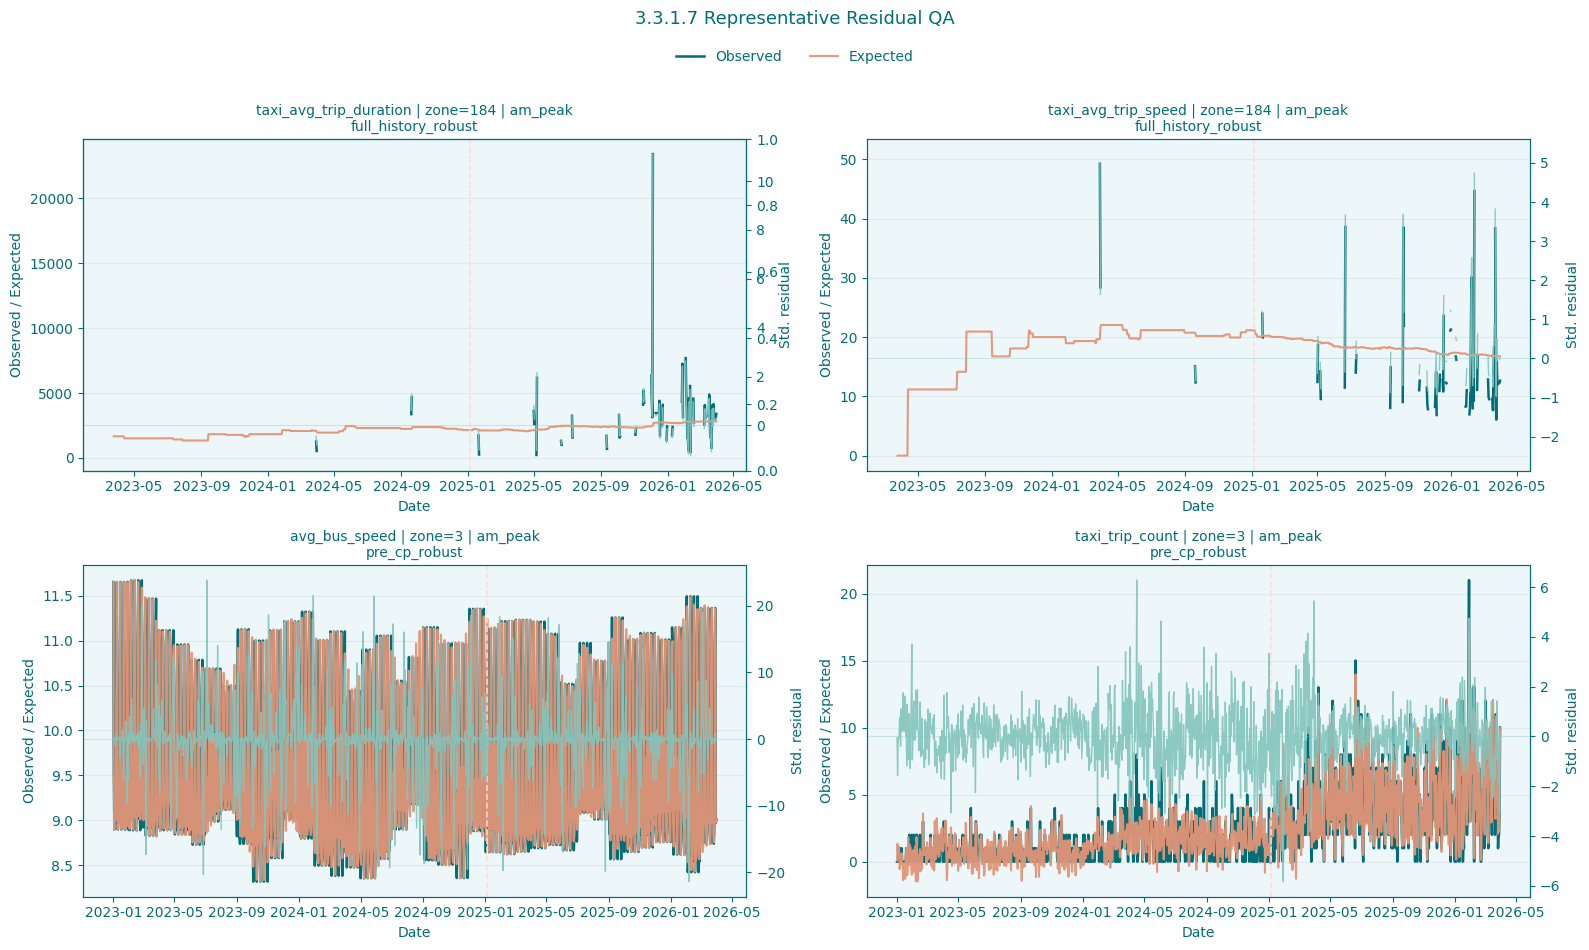

In [41]:
# ---------------------------------------------------------------------
# Representative Series Plot
# ---------------------------------------------------------------------

plot_series_df = standardized_residual_features_df.merge(
    representative_series_selection_df.loc[
        :,
        ["metric", "taxi_zone_id", "daypart", "series_id", "series_label", "scale_source"],
    ],
    on=["metric", "taxi_zone_id", "daypart", "series_id"],
    how="inner",
    validate="many_to_one",
).sort_values(["series_label", "date"]).reset_index(drop=True)

plot_series_df["date"] = pd.to_datetime(plot_series_df["date"])

plot_series_selection_df = representative_series_selection_df.copy()
plot_series_selection_df = plot_series_selection_df.sort_values(
    ["scale_source", "metric"]
).reset_index(drop=True)

n_series = len(plot_series_selection_df)
n_cols = 2
n_rows = int(np.ceil(n_series / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(16, 4.5 * n_rows),
    sharex=False,
    sharey=False,
)

axes = np.array(axes).reshape(-1)

for ax, series_row in zip(axes, plot_series_selection_df.itertuples(index=False)):
    series_df = plot_series_df.loc[plot_series_df["series_id"].eq(series_row.series_id)].copy()

    ax.plot(
        series_df["date"],
        series_df["observed_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.8,
        label="Observed",
    )
    ax.plot(
        series_df["date"],
        series_df["expected_value"],
        color=BRAND_COLORS["terracotta"],
        linewidth=1.5,
        alpha=0.95,
        label="Expected",
    )
    ax.axvline(
        pd.Timestamp(CONGESTION_PRICING_START_DATE),
        color=BRAND_COLORS["pale_peach"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    ax2 = ax.twinx()
    ax2.plot(
        series_df["date"],
        series_df["residual_zscore"],
        color=BRAND_COLORS["seafoam"],
        linewidth=1.0,
        alpha=0.9,
        label="Std. residual",
    )
    ax2.axhline(0, color=BRAND_COLORS["seafoam"], linewidth=0.8, alpha=0.35)

    ax.set_title(
        f"{series_row.metric} | zone={series_row.taxi_zone_id} | {series_row.daypart}\n"
        f"{series_row.scale_source}",
        fontsize=10,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Observed / Expected")
    ax2.set_ylabel("Std. residual")

    ax.grid(True, axis="y", alpha=0.2)

for ax in axes[n_series:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
handles_2, labels_2 = axes[0].twinx().get_legend_handles_labels()
combined_handles = handles + handles_2
combined_labels = labels + labels_2

fig.legend(
    combined_handles,
    combined_labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle("3.3.1.7 Representative Residual QA", fontsize=13, y=1.05)
fig.tight_layout()
plt.show()

Findings\. Each panel shows one series over time\. The teal line is the observed value, the peach line is the model’s expected value, and the seafoam line on the right axis is the standardized residual\. The vertical dashed line marks the congestion\-pricing start date\. The cleanest panels are the ones where observed and expected track each other closely while the standardized residual stays centered around zero with occasional spikes\. The noisier panels are the ones where expected values jump around more or where the residual axis swings widely, which usually points to thinner support or a less stable fallback fit\.

### Residual Distribution Review

This cell compresses the standardized residual space into a compact metric\-level diagnostic table so the distribution shape can be checked without opening the full series\-level output\.

In [42]:
# ---------------------------------------------------------------------
# Residual Distribution Summary
# ---------------------------------------------------------------------

residual_distribution_summary_df = (
    standardized_residual_features_df.groupby("metric", as_index=False)
    .agg(
        residual_observation_count=("residual_value", "size"),
        residual_median=("residual_value", "median"),
        residual_iqr=("residual_value", lambda s: float(s.quantile(0.75) - s.quantile(0.25))),
        standardized_median=("residual_zscore", "median"),
        standardized_iqr=("residual_zscore", lambda s: float(s.quantile(0.75) - s.quantile(0.25))),
        extreme_standardized_share=("residual_zscore", lambda s: float((s.abs() >= 3).mean())),
        missing_standardized_share=("residual_zscore", lambda s: float(s.isna().mean())),
    )
    .sort_values("extreme_standardized_share", ascending=False)
    .reset_index(drop=True)
)

display(
    residual_distribution_summary_df.loc[
        :,
        [
            "metric",
            "residual_observation_count",
            "standardized_median",
            "standardized_iqr",
            "extreme_standardized_share",
            "missing_standardized_share",
        ],
    ].round(3)
)

,metric,residual_observation_count,standardized_median,standardized_iqr,extreme_standardized_share,missing_standardized_share
0,avg_bus_speed,1559590,0.025,1.382,0.170,0.054
1,taxi_trip_count,1559590,0.058,1.452,0.110,0.019
2,fhvhv_trip_count,1559590,0.002,1.298,0.039,0.019
3,bus_trip_count,1559590,0.021,1.308,0.036,0.053
4,taxi_avg_trip_duration,1559590,0.000,1.246,0.033,0.300
5,taxi_avg_trip_speed,1559590,0.000,1.254,0.024,0.301
6,fhvhv_avg_trip_speed,1559590,0.017,1.292,0.021,0.024
7,fhvhv_avg_trip_duration,1559590,-0.040,1.288,0.018,0.024
8,subway_ridership,1559590,0.100,1.536,0.018,0.781
9,subway_transfers,1559590,0.158,1.615,0.014,0.771


Findings\. The standardized residual medians are essentially zero across all metrics, which is what we want after scaling\. The interquartile ranges vary a lot by metric, with bus\_trip\_count and avg\_bus\_speed showing the widest spread and the FHVHV metrics showing the tightest\. The extreme standardized share is still fairly high across several metrics, especially the FHVHV and taxi count series, which means the residuals preserve a substantial tail of unusual observations rather than collapsing everything toward the center\. Missing standardized values are low overall, but taxi\_avg\_trip\_duration and taxi\_avg\_trip\_speed have the largest gaps, consistent with their weaker support\.

This cell visualizes the overall standardized residual distribution and the metric\-level spread so the QA pass can confirm centering, tail behavior, and metric\-to\-metric consistency\.

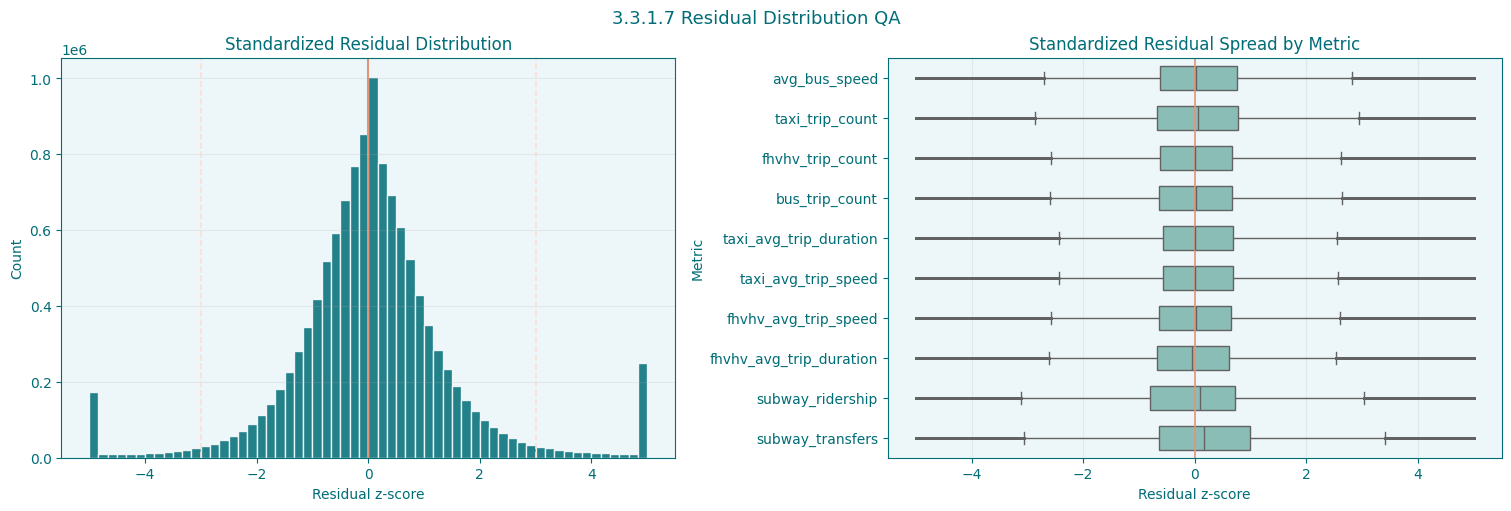

In [43]:
# ---------------------------------------------------------------------
# Residual Distribution Plot
# ---------------------------------------------------------------------

distribution_df = standardized_residual_features_df.loc[
    :, ["metric", "residual_value", "residual_zscore"]
].copy()

distribution_df["residual_zscore"] = distribution_df["residual_zscore"].astype(float)
distribution_df = distribution_df.dropna(subset=["residual_zscore"])

metric_order = residual_distribution_summary_df["metric"].tolist()
clipped_zscores = distribution_df["residual_zscore"].clip(-5, 5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].hist(
    clipped_zscores,
    bins=60,
    color=BRAND_COLORS["dark_teal"],
    alpha=0.85,
    edgecolor="white",
)
axes[0].axvline(0, color=BRAND_COLORS["terracotta"], linewidth=1.5)
axes[0].axvline(-3, color=BRAND_COLORS["pale_peach"], linestyle="--", linewidth=1.2)
axes[0].axvline(3, color=BRAND_COLORS["pale_peach"], linestyle="--", linewidth=1.2)
axes[0].set_title("Standardized Residual Distribution")
axes[0].set_xlabel("Residual z-score")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", alpha=0.2)

sns.boxplot(
    data=distribution_df.assign(residual_zscore=distribution_df["residual_zscore"].clip(-5, 5)),
    y="metric",
    x="residual_zscore",
    order=metric_order,
    ax=axes[1],
    color=BRAND_COLORS["seafoam"],
    fliersize=1,
    width=0.6,
)
axes[1].axvline(0, color=BRAND_COLORS["terracotta"], linewidth=1.2)
axes[1].set_title("Standardized Residual Spread by Metric")
axes[1].set_xlabel("Residual z-score")
axes[1].set_ylabel("Metric")
axes[1].grid(True, axis="x", alpha=0.2)

fig.suptitle("3.3.1.7 Residual Distribution QA", fontsize=13)
plt.show()

Findings\. The histogram is sharply centered near zero with visible tail mass on both sides, which suggests the residualization is removing the predictable baseline while leaving meaningful deviations in place\. The boxplots show that most metrics have median standardized residuals very close to zero, but some metrics have noticeably wider spread and more asymmetric tails than others\. bus\_trip\_count and avg\_bus\_speed look the most dispersed, while the FHVHV metrics are tighter and more concentrated around the center\. Overall, the distribution looks usable for anomaly detection, with enough central mass for stability and enough tail mass to preserve unusual events\.

### Representative Decomposition Examples

This subsection makes the residual workflow visible on concrete series rather than only in summaries\. The selection cell picks a small set of representative Metric × Taxi Zone × Daypart examples that cover modeled and fallback behavior, and the rendering cell then shows how observed values, expected values, trend, seasonal structure, and residuals line up over time\. The goal is to verify that the decomposition is removing the recurring structure cleanly while leaving a residual series that is more suitable for anomaly detection\.

Summarize how the final seasonal settings distribute across the modeled series universe\. This block rolls the Metric × Daypart production settings back up to the modeled Metric × Taxi Zone × Daypart series so it is easy to see how much of the supported residual universe ended up on weekly versus annual seasonal structure\.

In [44]:
# ---------------------------------------------------------------------
# Summarize series-level seasonality model coverage across modeled series
# ---------------------------------------------------------------------

seasonality_model_coverage_df = (
    seasonality_series_production_settings_df.groupby(
        ["metric", "daypart", "selected_seasonality_model"],
        as_index=False,
    )
    .agg(
        series_count=("series_id", "nunique"),
        median_best_seasonal_strength=("best_seasonal_strength", "median"),
        median_best_trend_strength=("best_trend_strength", "median"),
    )
    .sort_values(
        ["metric", "daypart", "series_count", "selected_seasonality_model"],
        ascending=[True, True, False, True],
    )
    .reset_index(drop=True)
)

seasonality_model_overview_df = pd.DataFrame(
    {
        "metric": [
            "modeled_series_count",
            "weekly_single_7_count",
            "monthly_single_30_count",
            "annual_single_365_count",
            "dual_7_365_count",
            "no_seasonality_count",
        ],
        "value": [
            int(seasonality_series_production_settings_df["series_id"].nunique()),
            int(
                seasonality_series_production_settings_df["selected_seasonality_model"]
                .eq("single_7")
                .sum()
            ),
            int(
                seasonality_series_production_settings_df["selected_seasonality_model"]
                .eq("single_30")
                .sum()
            ),
            int(
                seasonality_series_production_settings_df["selected_seasonality_model"]
                .eq("single_365")
                .sum()
            ),
            int(
                seasonality_series_production_settings_df["selected_seasonality_model"]
                .eq("dual_7_365")
                .sum()
            ),
            int(
                seasonality_series_production_settings_df["selected_seasonality_model"]
                .eq("none")
                .sum()
            ),
        ],
    }
)

display(seasonality_model_overview_df)
display(seasonality_model_coverage_df.round(3))

,metric,value
0,modeled_series_count,7882
1,weekly_single_7_count,1059
2,monthly_single_30_count,941
3,annual_single_365_count,42
4,dual_7_365_count,4681
5,no_seasonality_count,1159


,metric,daypart,selected_seasonality_model,series_count,median_best_seasonal_strength,median_best_trend_strength
0,avg_bus_speed,am_peak,single_7,235,0.986,0.881
1,avg_bus_speed,am_peak,dual_7_365,5,0.961,0.680
2,avg_bus_speed,evening,single_7,152,0.969,0.927
3,avg_bus_speed,evening,dual_7_365,2,0.951,0.649
4,avg_bus_speed,midday,single_7,191,0.980,0.903
5,avg_bus_speed,midday,dual_7_365,2,0.977,0.372
6,avg_bus_speed,overnight,single_7,149,0.957,0.897
7,avg_bus_speed,overnight,dual_7_365,2,0.920,0.666
8,avg_bus_speed,pm_peak,single_7,173,0.975,0.905
9,avg_bus_speed,pm_peak,dual_7_365,5,0.978,0.385


Findings\. The modeled universe now resolves to a clearly mixed seasonality regime rather than a one\-pattern\-fits\-all setup\. Of the 7,882 modeled series, 4,681 land in the dual 7 \+ 365 configuration, which makes that the dominant branch by far\. Another 1,059 use weekly\-only 7, 941 use monthly\-only 30, and just 42 use annual\-only 365, while 1,159 modeled series end up with no retained seasonal structure\. That distribution is the main takeaway: the notebook does not treat seasonality as a single shared clock, and most modeled series need either dual\-season handling or a shorter\-cycle specification rather than a pure annual fit\.

Representative Decomposition Example Selection\. This block picks three concrete series to make the residualization output easier to inspect: one annual example, one weekly example, and one fallback example where a full seasonal decomposition is not carried forward\. It also reshapes the modeled and fallback component handoffs into plotting\-ready tables so the next block can render the decomposition bands directly\.

In [45]:
# ---------------------------------------------------------------------
# Select representative decomposition examples
# ---------------------------------------------------------------------

fallback_series_lookup_df = (
    series_eligibility_df.loc[
        series_eligibility_df["support_status"].eq("fallback"),
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "zone",
            "borough",
            "daypart",
            "observed_value_variance",
            "support_status",
        ],
    ]
    .drop_duplicates(subset=["series_id"])
    .reset_index(drop=True)
)

annual_example_df = (
    seasonality_series_production_settings_df.loc[
        seasonality_series_production_settings_df["selected_seasonality_model"].eq("single_365")
    ]
    .sort_values(
        ["best_seasonal_strength", "best_trend_strength", "taxi_zone_id"],
        ascending=[False, False, True],
    )
    .head(1)
    .assign(example_source="Annual modeled example")
)

zone_27_weekly_df = (
    seasonality_series_production_settings_df.loc[
        seasonality_series_production_settings_df["taxi_zone_id"].eq(27)
        & seasonality_series_production_settings_df["metric"].eq("avg_bus_speed")
        & seasonality_series_production_settings_df["selected_seasonality_model"].eq("single_7")
    ]
    .sort_values(["best_seasonal_strength", "daypart"], ascending=[False, True])
    .head(1)
)

if len(zone_27_weekly_df) == 0:
    zone_27_weekly_df = (
        seasonality_series_production_settings_df.loc[
            seasonality_series_production_settings_df["selected_seasonality_model"].eq("single_7")
        ]
        .sort_values(
            ["best_seasonal_strength", "best_trend_strength", "taxi_zone_id"],
            ascending=[False, False, True],
        )
        .head(1)
    )

weekly_example_df = zone_27_weekly_df.assign(example_source="Weekly modeled example")

fallback_example_df = (
    fallback_series_lookup_df.sort_values(
        ["observed_value_variance", "taxi_zone_id", "daypart"],
        ascending=[False, True, True],
    )
    .head(1)
    .assign(
        example_source="Fallback baseline example",
        selected_seasonality_model="fallback",
        selected_seasonal_period=np.nan,
    )
)

representative_examples_df = pd.concat(
    [annual_example_df, weekly_example_df, fallback_example_df],
    ignore_index=True,
    sort=False,
)

display(
    representative_examples_df.loc[
        :,
        [
            "example_source",
            "metric",
            "taxi_zone_id",
            "zone",
            "borough",
            "daypart",
            "series_id",
            "selected_seasonality_model",
            "selected_seasonal_period",
        ],
    ]
)

,example_source,metric,taxi_zone_id,zone,borough,daypart,series_id,selected_seasonality_model,selected_seasonal_period
0,Annual modeled example,taxi_trip_count,93,Flushing Meadows-Corona Park,Queens,overnight,taxi_trip_count | zone=93 | daypart=overnight,single_365,365.0
1,Weekly modeled example,avg_bus_speed,27,Breezy Point/Fort Tilden/Riis Beach,Queens,midday,avg_bus_speed | zone=27 | daypart=midday,single_7,7.0
2,Fallback baseline example,subway_ridership,161,Midtown Center,Manhattan,pm_peak,subway_ridership | zone=161 | daypart=pm_peak,fallback,NaN


Findings\. The representative example set spans three intentionally different support paths\. The annual\-modeled example is taxi\_trip\_count in Flushing Meadows\-Corona Park overnight, which gives a clean pure\-annual case\. The weekly\-modeled example is Breezy Point/Fort Tilden/Riis Beach avg\_bus\_speed at midday, which is the series that motivated the deeper seasonality audit\. The fallback example is Midtown Center subway\_ridership at pm\_peak, which keeps the weaker\-support branch visible in the QA flow\. Together, the three examples make the downstream decomposition review easier to interpret because they cover a rare annual fit, a visually challenging recurring seasonal case, and a no\-decomposition fallback baseline\.

Representative Decomposition Panels\. This block renders one four\-band decomposition view for each selected example\. Modeled examples show observed values, trend/level, seasonal component, and residual\. The fallback example keeps the same visual layout, but its middle bands reflect the simpler baseline path rather than a full isolated seasonal decomposition\.

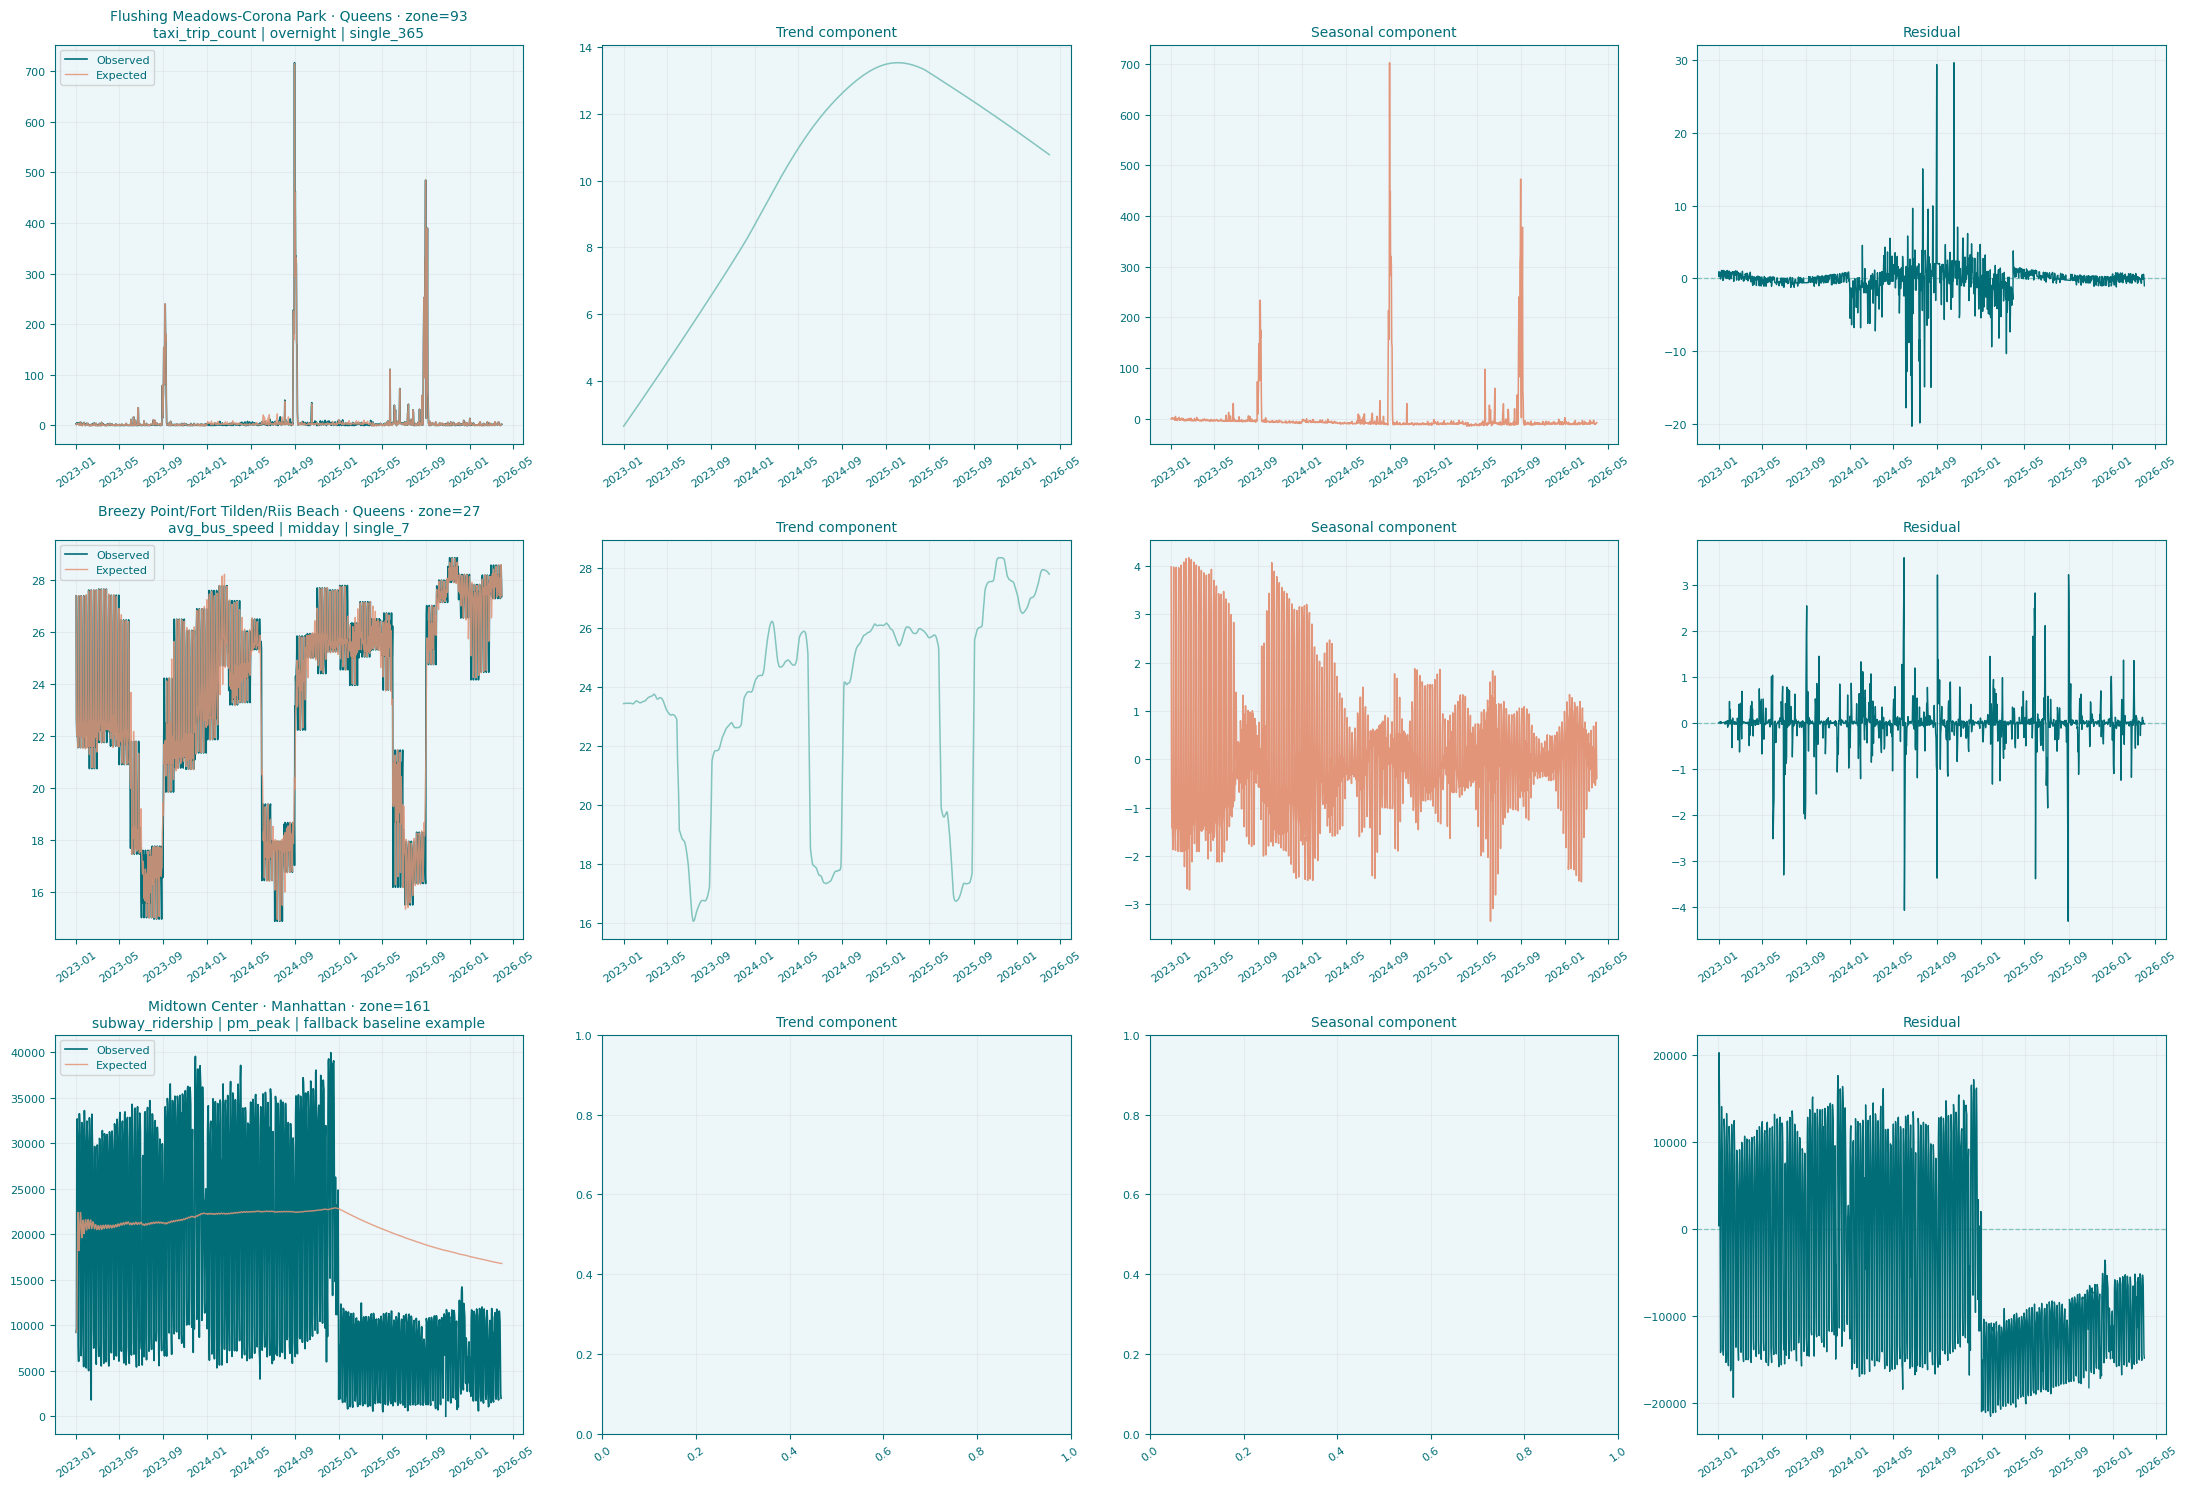

In [46]:
# ---------------------------------------------------------------------
# Render representative decomposition panels
# ---------------------------------------------------------------------

example_frames = []

for example_row in representative_examples_df.itertuples(index=False):
    if example_row.example_source == "Fallback baseline example":
        fallback_plot_df = (
            fallback_residual_features_df.loc[
                fallback_residual_features_df["series_id"].eq(example_row.series_id),
                ["date", "observed_value", "expected_value", "residual_value"],
            ]
            .sort_values("date")
            .reset_index(drop=True)
        )
        fallback_plot_df["seasonal_component"] = np.nan
        fallback_plot_df["trend_component"] = np.nan
        fallback_plot_df["example_source"] = example_row.example_source
        fallback_plot_df["panel_title"] = (
            f"{example_row.zone} · {example_row.borough} · zone={example_row.taxi_zone_id}\n"
            f"{example_row.metric} | {example_row.daypart} | fallback baseline example"
        )
        example_frames.append(fallback_plot_df)
        continue

    modeled_plot_df = (
        modeled_component_long_df.loc[
            modeled_component_long_df["series_id"].eq(example_row.series_id),
            [
                "date",
                "observed_value",
                "expected_value",
                "seasonal_component",
                "trend_component",
                "residual_value",
            ],
        ]
        .sort_values("date")
        .reset_index(drop=True)
    )
    modeled_plot_df["example_source"] = example_row.example_source
    modeled_plot_df["panel_title"] = (
        f"{example_row.zone} · {example_row.borough} · zone={example_row.taxi_zone_id}\n"
        f"{example_row.metric} | {example_row.daypart} | {example_row.selected_seasonality_model}"
    )
    example_frames.append(modeled_plot_df)

representative_decomposition_plot_df = pd.concat(example_frames, ignore_index=True)

example_titles = representative_examples_df["example_source"].tolist()
fig, axes = plt.subplots(
    nrows=len(example_titles),
    ncols=4,
    figsize=(22, 5 * len(example_titles)),
    sharex=False,
)

if len(example_titles) == 1:
    axes = np.array([axes])

for row_idx, example_source in enumerate(example_titles):
    plot_df = (
        representative_decomposition_plot_df.loc[
            representative_decomposition_plot_df["example_source"].eq(example_source)
        ]
        .copy()
        .sort_values("date")
        .reset_index(drop=True)
    )

    axes[row_idx, 0].plot(
        plot_df["date"],
        plot_df["observed_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.2,
        label="Observed",
    )
    axes[row_idx, 0].plot(
        plot_df["date"],
        plot_df["expected_value"],
        color=BRAND_COLORS["terracotta"],
        linewidth=1.0,
        alpha=0.85,
        label="Expected",
    )
    axes[row_idx, 0].set_title(plot_df["panel_title"].iloc[0], fontsize=10)
    axes[row_idx, 0].legend(loc="upper left", fontsize=8)

    if plot_df["trend_component"].notna().any():
        axes[row_idx, 1].plot(
            plot_df["date"],
            plot_df["trend_component"],
            color=BRAND_COLORS["seafoam"],
            linewidth=1.1,
        )
    axes[row_idx, 1].set_title("Trend component", fontsize=10)

    if plot_df["seasonal_component"].notna().any():
        axes[row_idx, 2].plot(
            plot_df["date"],
            plot_df["seasonal_component"],
            color=BRAND_COLORS["terracotta"],
            linewidth=1.1,
        )
    axes[row_idx, 2].set_title("Seasonal component", fontsize=10)

    axes[row_idx, 3].axhline(
        0,
        color=BRAND_COLORS["seafoam"],
        linestyle="--",
        linewidth=0.9,
    )
    axes[row_idx, 3].plot(
        plot_df["date"],
        plot_df["residual_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.0,
    )
    axes[row_idx, 3].set_title("Residual", fontsize=10)

    for col_idx in range(4):
        axes[row_idx, col_idx].tick_params(axis="x", rotation=35, labelsize=8)
        axes[row_idx, col_idx].tick_params(axis="y", labelsize=8)
        axes[row_idx, col_idx].grid(alpha=0.15)

plt.tight_layout()
plt.show()

Findings\. The three decomposition panels show three very different residual\-building paths\. The annual taxi\_trip\_count example concentrates the recurring long\-cycle structure into the expected and seasonal components, leaving a residual that is much quieter than the raw spike\-driven observed series\. The Breezy Point weekly example tracks the strong repeating local rhythm closely enough to keep most of the residual centered near zero while still leaving visible event\-like deviations in the tails\. The fallback subway example, by contrast, has no trend or seasonal decomposition at all, so the residual remains a baseline\-deviation view rather than a fully residualized seasonal series\. As a QA set, these examples show that the notebook is not forcing one decomposition style onto every support regime\.

Compare a true dual\-seasonality series against simpler single\-cycle alternatives\. This block selects one modeled series whose final production setting is dual\_7\_365 and then fits three competing views of the same time series: weekly\-only, annual\-only, and dual weekly\-plus\-annual\. The goal is to show why the notebook needed richer series\-level seasonality logic in some cases\. The comparison keeps the example concrete by reporting residual diagnostics and by rendering the observed\-versus\-expected fit side by side with the resulting residual traces\.

,metric,taxi_zone_id,zone,borough,daypart,series_id,selected_seasonality_model,selected_primary_period,selected_secondary_period
0,bus_trip_count,172,New Dorp/Midland Beach,Staten Island,overnight,bus_trip_count | zone=172 | daypart=overnight,dual_7_365,7.0,365.0


,fit_label,residual_variance,residual_std,residual_mad,residual_iqr
0,"Dual weekly + annual (7, 365)",189.403,13.762,0.299,0.649
1,Weekly only (7),254.646,15.958,2.651,6.995
2,Annual only (365),2745.405,52.397,0.000,0.000


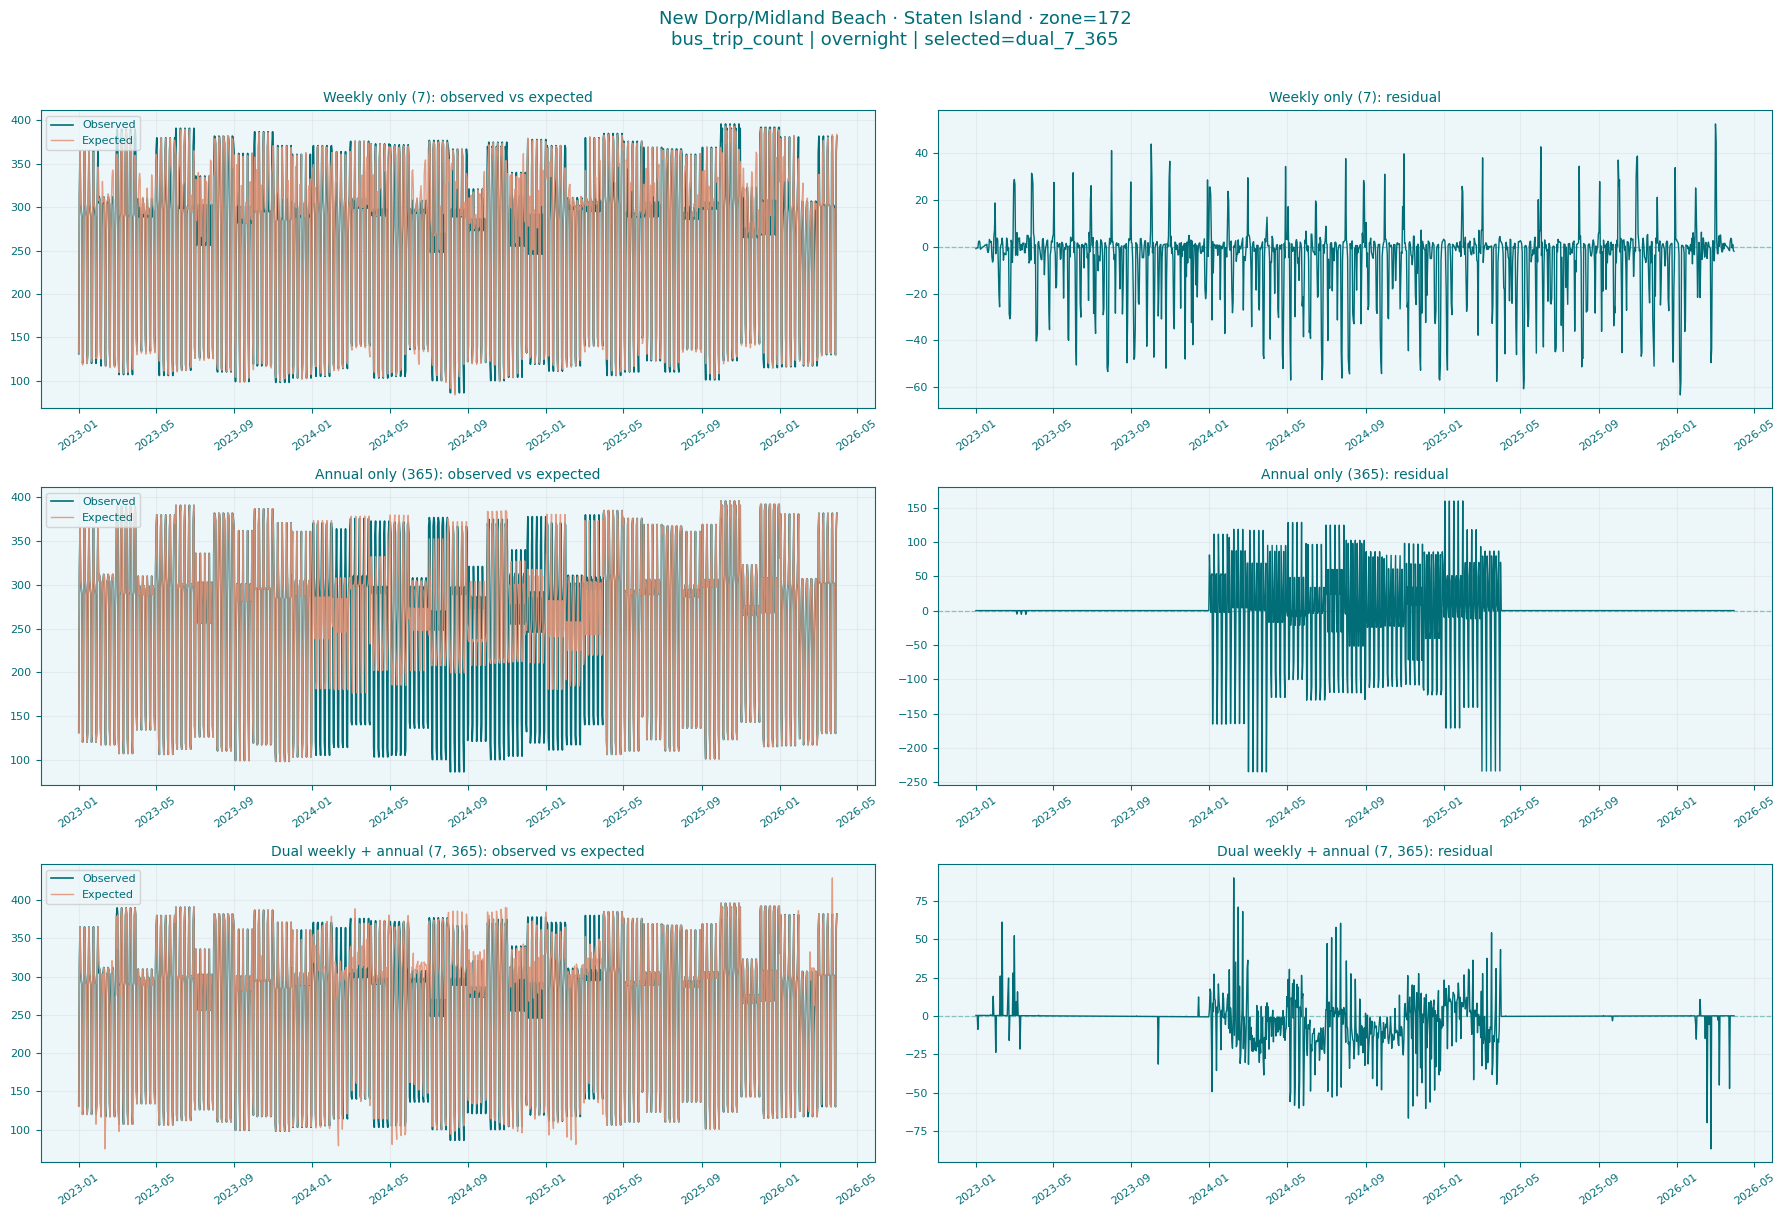

In [47]:
# ---------------------------------------------------------------------
# Compare a true dual-seasonality series against single-cycle alternatives
# ---------------------------------------------------------------------

from statsmodels.tsa.seasonal import STL, MSTL

# Pick one strong dual-seasonality example that was not already used above.
used_example_series_ids = set(representative_examples_df["series_id"].tolist())

dual_example_candidates_df = (
    seasonality_series_production_settings_df.loc[
        seasonality_series_production_settings_df["selected_seasonality_model"].eq("dual_7_365")
        & ~seasonality_series_production_settings_df["series_id"].isin(used_example_series_ids)
    ]
    .sort_values(
        [
            "best_seasonal_strength",
            "best_trend_strength",
            "taxi_zone_id",
            "daypart",
        ],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)

dual_example_row = dual_example_candidates_df.iloc[0]

# Use the modeled component table as the source of the raw observed series.
# It already lives at Metric x Taxi Zone x Daypart x Date grain.
dual_example_series_df = (
    modeled_component_long_df.loc[
        modeled_component_long_df["series_id"].eq(dual_example_row.series_id),
        [
            "date",
            "observed_value",
            "metric",
            "series_id",
            "taxi_zone_id",
            "zone",
            "borough",
            "daypart",
        ],
    ]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

dual_example_series_df["date"] = pd.to_datetime(dual_example_series_df["date"])
dual_example_series_df["observed_value"] = pd.to_numeric(
    dual_example_series_df["observed_value"],
    errors="coerce",
)

dual_example_series_df = dual_example_series_df.dropna(subset=["observed_value"]).reset_index(drop=True)

series_dates = dual_example_series_df["date"]
series_values = dual_example_series_df["observed_value"].astype(float)

# Fit three competing decompositions on the same exact observed series.
weekly_fit = STL(
    series_values,
    period=7,
    robust=True,
).fit()

annual_fit = STL(
    series_values,
    period=365,
    robust=True,
).fit()

dual_fit = MSTL(
    series_values,
    periods=(7, 365),
    stl_kwargs={"robust": True},
).fit()

comparison_plot_frames = []
comparison_summary_records = []

fit_payloads = [
    (
        "single_7",
        "Weekly only (7)",
        weekly_fit.trend,
        weekly_fit.seasonal,
        weekly_fit.trend + weekly_fit.seasonal,
        weekly_fit.resid,
    ),
    (
        "single_365",
        "Annual only (365)",
        annual_fit.trend,
        annual_fit.seasonal,
        annual_fit.trend + annual_fit.seasonal,
        annual_fit.resid,
    ),
    (
        "dual_7_365",
        "Dual weekly + annual (7, 365)",
        dual_fit.trend,
        dual_fit.seasonal.sum(axis=1),
        dual_fit.trend + dual_fit.seasonal.sum(axis=1),
        dual_fit.resid,
    ),
]

for fit_key, fit_label, trend_component, seasonal_component, expected_value, residual_value in fit_payloads:
    fit_df = pd.DataFrame(
        {
            "date": series_dates.to_numpy(),
            "observed_value": series_values.to_numpy(),
            "expected_value": np.asarray(expected_value, dtype=float),
            "trend_component": np.asarray(trend_component, dtype=float),
            "seasonal_component": np.asarray(seasonal_component, dtype=float),
            "residual_value": np.asarray(residual_value, dtype=float),
            "fit_key": fit_key,
            "fit_label": fit_label,
        }
    )

    comparison_plot_frames.append(fit_df)

    residual_series = pd.Series(fit_df["residual_value"], dtype=float)

    comparison_summary_records.append(
        {
            "fit_label": fit_label,
            "residual_variance": float(np.nanvar(residual_series)),
            "residual_std": float(np.nanstd(residual_series)),
            "residual_mad": float(
                (residual_series - residual_series.median()).abs().median()
            ),
            "residual_iqr": float(
                residual_series.quantile(0.75) - residual_series.quantile(0.25)
            ),
        }
    )

dual_seasonality_comparison_df = (
    pd.DataFrame(comparison_summary_records)
    .sort_values("residual_variance")
    .reset_index(drop=True)
)

dual_seasonality_plot_df = pd.concat(
    comparison_plot_frames,
    ignore_index=True,
)

dual_example_metadata_df = pd.DataFrame(
    {
        "metric": [dual_example_row.metric],
        "taxi_zone_id": [int(dual_example_row.taxi_zone_id)],
        "zone": [dual_example_row.zone],
        "borough": [dual_example_row.borough],
        "daypart": [dual_example_row.daypart],
        "series_id": [dual_example_row.series_id],
        "selected_seasonality_model": [dual_example_row.selected_seasonality_model],
        "selected_primary_period": [dual_example_row.selected_primary_period],
        "selected_secondary_period": [dual_example_row.selected_secondary_period],
    }
)

display(dual_example_metadata_df)
display(dual_seasonality_comparison_df.round(3))

fit_order = [
    "Weekly only (7)",
    "Annual only (365)",
    "Dual weekly + annual (7, 365)",
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 12),
    sharex=False,
)

for row_idx, fit_label in enumerate(fit_order):
    fit_df = (
        dual_seasonality_plot_df.loc[
            dual_seasonality_plot_df["fit_label"].eq(fit_label)
        ]
        .sort_values("date")
        .reset_index(drop=True)
    )

    axes[row_idx, 0].plot(
        fit_df["date"],
        fit_df["observed_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.2,
        label="Observed",
    )
    axes[row_idx, 0].plot(
        fit_df["date"],
        fit_df["expected_value"],
        color=BRAND_COLORS["terracotta"],
        linewidth=1.0,
        alpha=0.9,
        label="Expected",
    )
    axes[row_idx, 0].set_title(f"{fit_label}: observed vs expected", fontsize=10)
    axes[row_idx, 0].legend(loc="upper left", fontsize=8)

    axes[row_idx, 1].axhline(
        0,
        color=BRAND_COLORS["seafoam"],
        linestyle="--",
        linewidth=0.9,
    )
    axes[row_idx, 1].plot(
        fit_df["date"],
        fit_df["residual_value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.0,
    )
    axes[row_idx, 1].set_title(f"{fit_label}: residual", fontsize=10)

    for col_idx in range(2):
        axes[row_idx, col_idx].tick_params(axis="x", rotation=35, labelsize=8)
        axes[row_idx, col_idx].tick_params(axis="y", labelsize=8)
        axes[row_idx, col_idx].grid(alpha=0.15)

fig.suptitle(
    (
        f"{dual_example_row.zone} · {dual_example_row.borough} · zone={dual_example_row.taxi_zone_id}\n"
        f"{dual_example_row.metric} | {dual_example_row.daypart} | selected={dual_example_row.selected_seasonality_model}"
    ),
    fontsize=13,
    y=1.01,
)

plt.tight_layout()
plt.show()

Findings\. The selected dual\-seasonality example is bus\_trip\_count in New Dorp/Midland Beach, Staten Island, during overnight, and its retained production setting is dual\_7\_365 with weekly and annual periods carried together\. The diagnostics show a clear improvement from that choice: the dual fit has the lowest residual variance at 189\.403 and the lowest residual standard deviation at 13\.762, compared with 254\.646 and 15\.958 for the weekly\-only fit and 2745\.405 and 52\.397 for the annual\-only fit\. The more robust spread measures tell the same story\. Residual MAD drops to 0\.299 under the dual fit versus 2\.651 for weekly\-only, while residual IQR falls to 0\.649 from 6\.995\. Visually, the dual decomposition tracks both the short\-cycle repetition and the broader longer\-cycle structure much more closely, while the annual\-only fit leaves a visibly distorted residual surface\. This example gives a concrete justification for keeping multi\-season decomposition in the modeled branch\.

### Section Summary

This section serves as a QA checkpoint for the residualized feature layer\. It first summarizes how the modeled series distribute across the notebook’s retained seasonality structures, showing that dual 7 \+ 365 decomposition is the dominant outcome but not the only one\. It then uses a small set of representative decomposition examples to show how observed values, expected values, seasonal structure, and residual behavior differ across annual, weekly, fallback, and dual\-seasonality cases\. The additional dual\-seasonality comparison makes the gain from the richer series\-level decomposition logic visible on one concrete modeled series rather than leaving that decision abstract\. Finally, the residual distribution checks confirm that the standardized anomaly inputs remain centered close to zero while still preserving meaningful tail behavior\. Taken together, these visual and statistical checks support the residual features as a usable anomaly input layer without erasing unusual observations\.

## 3\.3\.1\.8 Assemble the Shared Calibration Panel

This chapter prepares the method\-neutral calibration assets used by the downstream anomaly notebooks\. It turns the residual feature layer into a reusable calibration panel, builds a stratified calibration sample for tuning and comparison, and writes a compact manifest so 3\.3\.2, 3\.3\.3, and 3\.3\.4 can consume the same handoff without recreating notebook state\.

### Build the Shared Calibration Panel

Build a method\-neutral calibration table from the residual panel, keeping the row keys and residual features needed by all downstream anomaly methods\.

This block assembles the shared calibration panel used by all downstream anomaly methods\. It keeps the row\-level residual signal, the daypart grain, and the support metadata needed to calibrate detectors consistently\.

In [48]:
# ---------------------------------------------------------------------
# Build the Shared Calibration Panel
# ---------------------------------------------------------------------

# Start from the standardized residual handoff itself. At this point in the
# notebook it already contains the row-level residual values plus the temporal
# and support-routing fields assembled in 3.3.1.6.
calibration_panel_df = standardized_residual_features_df.copy()

# Rebuild any required ordering/context fields only if they are truly absent.
# This avoids creating _x / _y duplicates when the notebook is rerun cleanly.
if "daypart_order" not in calibration_panel_df.columns:
    daypart_order_map = {daypart: idx + 1 for idx, daypart in enumerate(DAYPART_ORDER)}
    calibration_panel_df["daypart_order"] = (
        calibration_panel_df["daypart"].map(daypart_order_map).astype("Int64")
    )

missing_context_columns = [
    column
    for column in [
        "zone",
        "borough",
        "pre_post_cp",
        "temporal_bucket",
        "temporal_bucket_order",
    ]
    if column not in calibration_panel_df.columns
]

if missing_context_columns:
    calibration_backbone_context_df = (
        mobility_backbone_df.loc[
            :,
            ["taxi_zone_id", "date", "daypart", *missing_context_columns],
        ]
        .drop_duplicates(subset=["taxi_zone_id", "date", "daypart"])
        .copy()
    )

    calibration_panel_df = calibration_panel_df.merge(
        calibration_backbone_context_df,
        on=["taxi_zone_id", "date", "daypart"],
        how="left",
        validate="many_to_one",
    )

# Pull only the series-level QA fields that are not already present on the
# standardized residual handoff. Keeping this merge narrow prevents another
# round of duplicate support/context columns.
series_eligibility_supplement_df = (
    series_eligibility_df.loc[
        :,
        [
            "metric",
            "series_id",
            "taxi_zone_id",
            "daypart",
            "non_null_observation_count",
            "missing_rate",
            "active_span_days",
            "observed_value_variance",
        ],
    ]
    .drop_duplicates(subset=["metric", "series_id", "taxi_zone_id", "daypart"])
    .copy()
)

calibration_panel_df = (
    calibration_panel_df.merge(
        series_eligibility_supplement_df,
        on=["metric", "series_id", "taxi_zone_id", "daypart"],
        how="left",
        validate="many_to_one",
    )
    .sort_values(["metric", "daypart_order", "date", "taxi_zone_id"])
    .reset_index(drop=True)
)

# Add the explicit support flags that downstream DBSCAN calibration expects.
calibration_panel_df["row_has_any_modeled_flag"] = (
    calibration_panel_df["support_status"].eq("modeled").astype(int)
)
calibration_panel_df["row_has_any_fallback_flag"] = (
    calibration_panel_df["support_status"].eq("fallback").astype(int)
)
calibration_panel_df["row_has_any_structural_absence_flag"] = (
    calibration_panel_df["support_status"].eq("unavailable").astype(int)
)
calibration_panel_df["comparison_group_support_review_flag"] = (
    calibration_panel_df["support_status"].ne("modeled")
)

calibration_contract_summary_df = pd.DataFrame(
    {
        "check": [
            "required_columns_present",
            "unique_taxi_zone_date_daypart_metric_grain",
            "metric_count",
            "daypart_count",
            "series_count",
        ],
        "value": [
            True,
            not calibration_panel_df.duplicated(
                subset=["taxi_zone_id", "date", "daypart", "metric"]
            ).any(),
            int(calibration_panel_df["metric"].nunique()),
            int(calibration_panel_df["daypart"].nunique()),
            int(
                calibration_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
        ],
        "status": [
            status_label(True),
            status_label(
                not calibration_panel_df.duplicated(
                    subset=["taxi_zone_id", "date", "daypart", "metric"]
                ).any()
            ),
            status_label(
                calibration_panel_df["metric"].nunique()
                == len(ANOMALY_BASE_METRIC_COLUMNS)
            ),
            status_label(
                calibration_panel_df["daypart"].nunique() == len(DAYPART_ORDER)
            ),
            status_label(
                calibration_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0] > 0
            ),
        ],
    }
)

if WRITE_OUTPUTS:
    calibration_panel_df.to_parquet(CALIBRATION_PANEL_PATH, index=False)

display(calibration_contract_summary_df)
print(f"Calibration panel rows: {len(calibration_panel_df):,}")
print(
    "Calibration panel series: "
    f"{calibration_panel_df[['metric', 'taxi_zone_id', 'daypart']].drop_duplicates().shape[0]:,}"
)
print(f"Calibration panel written: {CALIBRATION_PANEL_PATH}")

,check,value,status
0,required_columns_present,True,pass
1,unique_taxi_zone_date_daypart_metric_grain,True,pass
2,metric_count,10,pass
3,daypart_count,5,pass
4,series_count,13150,pass


Calibration panel rows: 15,595,900
Calibration panel series: 13,150
Calibration panel written: pipeline_data/3.3.1.final_tables/daypart_calibration_panel.parquet


Findings\. The shared calibration panel is fully assembled and matches the intended daypart\-level handoff: 15,595,900 rows across 13,150 Taxi Zone × Daypart × Metric series, with all 10 metrics and all 5 dayparts represented\. The validation checks passed cleanly, so the panel is ready to serve as the common calibration backbone for the downstream anomaly notebooks\.

### Stratify the Calibration Sample

Build a compact calibration sample that preserves coverage across the important strata instead of relying on a blind sample\.

This block constructs a stratified calibration sample so the downstream anomaly notebooks see representative rows from the full residual universe instead of an arbitrary slice\.

In [49]:
# ---------------------------------------------------------------------
# Build the Stratified Calibration Sample and Group Summary
# ---------------------------------------------------------------------

calibration_group_size_summary_df = (
    calibration_panel_df.groupby(["metric", "daypart"], observed=True, as_index=False)
    .agg(
        row_count=("series_id", "size"),
        series_count=("series_id", "nunique"),
        modeled_row_count=("support_status", lambda s: int((s == "modeled").sum())),
        fallback_row_count=("support_status", lambda s: int((s == "fallback").sum())),
        unavailable_row_count=("support_status", lambda s: int((s == "unavailable").sum())),
        median_missing_rate=("missing_rate", "median"),
        median_observed_value_variance=("observed_value_variance", "median"),
    )
    .sort_values(["metric", "daypart"])
    .reset_index(drop=True)
)

calibration_sample_frames = []

for (metric, daypart), group_df in calibration_panel_df.groupby(
    ["metric", "daypart"],
    observed=True,
):
    sample_n = min(CALIBRATION_SAMPLE_ROWS_PER_GROUP_CAP, len(group_df))
    calibration_sample_frames.append(
        group_df.sample(
            n=sample_n,
            random_state=CALIBRATION_SAMPLE_RANDOM_STATE,
        )
    )

calibration_sample_df = (
    pd.concat(calibration_sample_frames, ignore_index=True)
    .sort_values(["metric", "daypart_order", "date", "taxi_zone_id"])
    .reset_index(drop=True)
)

calibration_asset_summary_df = pd.DataFrame(
    {
        "metric": [
            "calibration_panel_rows",
            "calibration_panel_series",
            "calibration_group_count",
            "calibration_sample_rows",
            "sample_rows_per_group_cap",
        ],
        "value": [
            len(calibration_panel_df),
            calibration_panel_df[["metric", "taxi_zone_id", "daypart"]].drop_duplicates().shape[0],
            len(calibration_group_size_summary_df),
            len(calibration_sample_df),
            CALIBRATION_SAMPLE_ROWS_PER_GROUP_CAP,
        ],
    }
)

if WRITE_OUTPUTS:
    calibration_sample_df.to_parquet(CALIBRATION_SAMPLE_PATH, index=False)
    calibration_group_size_summary_df.to_parquet(
        CALIBRATION_GROUP_SIZE_SUMMARY_PATH,
        index=False,
    )

display(calibration_asset_summary_df)
display(calibration_group_size_summary_df.round(3))
print(f"Calibration sample rows: {len(calibration_sample_df):,}")
print(f"Calibration sample written: {CALIBRATION_SAMPLE_PATH}")
print(f"Calibration group summary written: {CALIBRATION_GROUP_SIZE_SUMMARY_PATH}")

,metric,value
0,calibration_panel_rows,15595900
1,calibration_panel_series,13150
2,calibration_group_count,50
3,calibration_sample_rows,12500
4,sample_rows_per_group_cap,250


,metric,daypart,row_count,series_count,modeled_row_count,fallback_row_count,unavailable_row_count,median_missing_rate,median_observed_value_variance
0,avg_bus_speed,am_peak,311918,263,284640,14232,13046,0.000,0.617
1,avg_bus_speed,evening,311918,263,182644,113856,15418,0.000,0.186
2,avg_bus_speed,midday,311918,263,228898,69974,13046,0.000,0.266
3,avg_bus_speed,overnight,311918,263,179086,118600,14232,0.000,0.201
4,avg_bus_speed,pm_peak,311918,263,211108,87764,13046,0.000,0.238
5,bus_trip_count,am_peak,311918,263,275152,23720,13046,0.000,52065.684
6,bus_trip_count,evening,311918,263,179086,117414,15418,0.000,5040.514
7,bus_trip_count,midday,311918,263,266850,32022,13046,0.000,29207.040
8,bus_trip_count,overnight,311918,263,134018,163668,14232,0.000,2918.972
9,bus_trip_count,pm_peak,311918,263,256176,42696,13046,0.000,26907.140


Calibration sample rows: 12,500
Calibration sample written: pipeline_data/3.3.1.final_tables/daypart_calibration_sample.parquet
Calibration group summary written: pipeline_data/3.3.1.final_tables/daypart_calibration_group_size_summary.parquet


Findings\. The stratified calibration sample and group summary were written successfully, and the calibration universe is now explicit and bounded: 50 metric\-daypart groups, a 12,500\-row calibration sample, and a 250\-row cap per group\. The group summary shows the expected support imbalance across metrics and dayparts, with dense taxi and bus groups, structurally sparse taxi\-average duration/speed groups, and subway groups that remain sizable but more uneven in variance and availability\. This makes the calibration sample useful as a compact tuning set rather than a blind slice\.

## 3\.3\.1\.9 Assemble and Export the Production Residual Handoff

This chapter packages the residual feature layer into the production handoff for downstream anomaly modeling\. The first part validates that the assembled residual panel still matches the expected Taxi Zone × Date × Daypart × Metric contract, and the second part writes the final outputs together with a compact manifest that records what was exported, where it lives, and how downstream notebooks should interpret it\.

### Assemble the Production Residual Panel

This section packages the daypart\-level residual outputs into the downstream handoff\. The residual panel is organized at Taxi Zone × Date × Daypart × Metric grain, with temporal\_bucket retained only as source context when present\. A compact artifact registry records the export contract so later notebooks can load the correct files and verify the grain without recreating the assembly logic\.

Residual Feature Assembly\. This cell merges the standardized residual features back to the source panel context and writes the production residual panel\. Daypart is the operational grain; temporal\_bucket is preserved only when it already exists in the backbone\.

In [50]:
# ---------------------------------------------------------------------
# Residual Feature Assembly
# ---------------------------------------------------------------------

# The standardized residual handoff already carries the row-level anomaly inputs.
# Start from that table directly so the residual panel does not recreate
# duplicate context columns on reruns.
residual_panel_df = standardized_residual_features_df.copy()

if "daypart_order" not in residual_panel_df.columns:
    daypart_order_map = {daypart: idx + 1 for idx, daypart in enumerate(DAYPART_ORDER)}
    residual_panel_df["daypart_order"] = (
        residual_panel_df["daypart"].map(daypart_order_map).astype("Int64")
    )

missing_context_columns = [
    column
    for column in [
        "zone",
        "borough",
        "pre_post_cp",
        "temporal_bucket",
        "temporal_bucket_order",
    ]
    if column not in residual_panel_df.columns
]

if missing_context_columns:
    backbone_context_df = (
        mobility_backbone_df.loc[
            :,
            ["taxi_zone_id", "date", "daypart", *missing_context_columns],
        ]
        .drop_duplicates(subset=["taxi_zone_id", "date", "daypart"])
        .copy()
    )

    residual_panel_df = residual_panel_df.merge(
        backbone_context_df,
        on=["taxi_zone_id", "date", "daypart"],
        how="left",
        validate="many_to_one",
    )

residual_panel_df["date"] = pd.to_datetime(residual_panel_df["date"], errors="coerce")

residual_panel_df = residual_panel_df.sort_values(
    ["taxi_zone_id", "daypart_order", "metric", "date"]
).reset_index(drop=True)

residual_panel_columns = [
    "taxi_zone_id",
    "zone",
    "borough",
    "date",
    "daypart",
    "temporal_bucket",
    "temporal_bucket_order",
    "daypart_order",
    "pre_post_cp",
    "metric",
    "series_id",
    "support_status",
    "support_reason",
    "eligibility_pathway",
    "observed_value",
    "expected_value",
    "residual_value",
    "residual_zscore",
    "residual_center",
    "residual_scale",
    "scale_source",
    "scale_method",
    "scale_reference_window",
    "scale_reference_count",
]

residual_panel_columns = [
    column for column in residual_panel_columns if column in residual_panel_df.columns
]

residual_panel_df = residual_panel_df.loc[:, residual_panel_columns]

if WRITE_OUTPUTS:
    residual_panel_df.to_parquet(RESIDUAL_PANEL_PATH, index=False)

print(f"Residual panel rows assembled: {len(residual_panel_df):,}")
print(
    "Residual series covered: "
    f"{residual_panel_df[['metric', 'taxi_zone_id', 'daypart']].drop_duplicates().shape[0]:,}"
)
print(f"Residual panel written: {RESIDUAL_PANEL_PATH}")

Residual panel rows assembled: 15,595,900
Residual series covered: 13,150
Residual panel written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_panel.parquet


Findings\. The residual handoff is fully assembled at the expected scale: 15,595,900 rows covering 13,150 residual series, and the final panel was written to pipeline\_data/3\.3\.1\.final\_tables/temporal\_residual\_mobility\_panel\.parquet\. The export size is consistent with a daypart\-level Taxi Zone × Date × Metric residual panel expanded across the five dayparts, so this looks like the intended production handoff rather than an incomplete intermediate artifact\. 

Supporting Diagnostics Assembly\. This cell writes a compact metric\-level diagnostics table and the artifact registry\. The diagnostics table records the coverage profile of the exported residual panel, while the registry records the file paths and grain contract that downstream notebooks need\.

In [51]:
# ---------------------------------------------------------------------
# Supporting Diagnostics Assembly
# ---------------------------------------------------------------------

residual_diagnostics_df = (
    residual_panel_df.groupby("metric", as_index=False)
    .agg(
        series_count=("series_id", "nunique"),
        observation_count=("series_id", "size"),
        median_residual_scale=("residual_scale", "median"),
        median_abs_residual_zscore=(
            "residual_zscore",
            lambda s: float(s.abs().median()),
        ),
        missing_residual_zscore_share=(
            "residual_zscore",
            lambda s: float(s.isna().mean()),
        ),
        pre_cp_scaled_series_count=(
            "scale_source",
            lambda s: int((s == "pre_cp_robust").sum()),
        ),
        fallback_scaled_series_count=(
            "scale_source",
            lambda s: int((s == "full_history_robust").sum()),
        ),
        unavailable_scaled_series_count=(
            "scale_source",
            lambda s: int((s == "unavailable").sum()),
        ),
    )
    .sort_values("metric")
    .reset_index(drop=True)
)

residual_artifact_registry_df = pd.DataFrame(
    [
        {
            "artifact_name": "temporal_residual_mobility_panel",
            "artifact_type": "panel",
            "path": str(RESIDUAL_PANEL_PATH),
            "grain": "Taxi Zone × Date × Daypart × Metric",
            "primary_keys": "taxi_zone_id,date,daypart,metric",
            "row_count": int(len(residual_panel_df)),
            "column_count": int(residual_panel_df.shape[1]),
            "metric_count": int(residual_panel_df["metric"].nunique()),
            "daypart_count": int(residual_panel_df["daypart"].nunique()),
            "series_count": int(
                residual_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Primary downstream residual handoff.",
        },
        {
            "artifact_name": "temporal_residual_mobility_diagnostics",
            "artifact_type": "diagnostics",
            "path": str(RESIDUAL_DIAGNOSTICS_PATH),
            "grain": "Metric",
            "primary_keys": "metric",
            "row_count": int(len(residual_diagnostics_df)),
            "column_count": int(residual_diagnostics_df.shape[1]),
            "metric_count": int(residual_diagnostics_df["metric"].nunique()),
            "daypart_count": int(residual_panel_df["daypart"].nunique()),
            "series_count": int(
                residual_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Compact summary for downstream sanity checks.",
        },
    ]
)

if WRITE_OUTPUTS:
    residual_diagnostics_df.to_parquet(RESIDUAL_DIAGNOSTICS_PATH, index=False)
    residual_artifact_registry_df.to_csv(RESIDUAL_MANIFEST_PATH, index=False)

display(residual_artifact_registry_df.round(3))
print(f"Residual diagnostics written: {RESIDUAL_DIAGNOSTICS_PATH}")
print(f"Residual manifest written: {RESIDUAL_MANIFEST_PATH}")

,artifact_name,artifact_type,path,grain,primary_keys,row_count,column_count,metric_count,daypart_count,series_count,notes
0,temporal_residual_mobility_panel,panel,pipeline_data/3.3.1.final_tables/temporal_resi...,Taxi Zone × Date × Daypart × Metric,"taxi_zone_id,date,daypart,metric",15595900,24,10,5,13150,Primary downstream residual handoff.
1,temporal_residual_mobility_diagnostics,diagnostics,pipeline_data/3.3.1.final_tables/temporal_resi...,Metric,metric,10,9,10,5,13150,Compact summary for downstream sanity checks.


Residual diagnostics written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_diagnostics.parquet
Residual manifest written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_manifest.csv


Findings\. The artifact registry is doing what it should: it records the residual panel as the primary downstream handoff and the diagnostics table as a compact sanity\-check companion, without bloating the export with documentation\-only tables\. The manifest gives downstream notebooks a clean, machine\-readable summary of what exists, where it lives, and what grain to expect, which is exactly the kind of metadata that reduces guesswork later\.

### Validate the Handoff Contract

We check the assembled residual panel against the downstream contract before anything is written out\. It confirms the required identity columns, the residual feature columns, the expected grain, and the key support metadata needed by anomaly detection\.

This block verifies that the assembled residual panel is ready for export\. It checks the residual grain, confirms the key identity and feature columns, and summarizes the contract in a compact validation table before the final files are written\.

In [52]:
# ---------------------------------------------------------------------
# Validate the Handoff Contract
# ---------------------------------------------------------------------

required_handoff_columns = [
    "taxi_zone_id",
    "date",
    "daypart",
    "temporal_bucket",
    "temporal_bucket_order",
    "daypart_order",
    "metric",
    "series_id",
    "observed_value",
    "expected_value",
    "residual_value",
    "residual_zscore",
    "residual_center",
    "residual_scale",
    "scale_source",
    "scale_method",
    "scale_reference_window",
    "scale_reference_count",
]

require_columns(
    residual_panel_df,
    required_handoff_columns,
    "residual_panel_df",
)

require_unique_grain(
    residual_panel_df,
    ["taxi_zone_id", "date", "daypart", "metric"],
    "residual_panel_df",
)

handoff_contract_summary_df = pd.DataFrame(
    {
        "check": [
            "required_columns_present",
            "unique_taxi_zone_date_daypart_metric_grain",
            "metric_count",
            "daypart_count",
            "series_count",
            "non_null_residual_zscore_share",
        ],
        "value": [
            True,
            True,
            int(residual_panel_df["metric"].nunique()),
            int(residual_panel_df["daypart"].nunique()),
            int(
                residual_panel_df[
                    ["metric", "taxi_zone_id", "daypart"]
                ]
                .drop_duplicates()
                .shape[0]
            ),
            float(residual_panel_df["residual_zscore"].notna().mean()),
        ],
        "status": [
            status_label(True),
            status_label(True),
            status_label(residual_panel_df["metric"].nunique() == len(ANOMALY_BASE_METRIC_COLUMNS)),
            status_label(residual_panel_df["daypart"].nunique() == len(DAYPART_ORDER)),
            status_label(
                residual_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0] > 0
            ),
            status_label(residual_panel_df["residual_zscore"].notna().any()),
        ],
    }
)

display(handoff_contract_summary_df)

,check,value,status
0,required_columns_present,True,pass
1,unique_taxi_zone_date_daypart_metric_grain,True,pass
2,metric_count,10,pass
3,daypart_count,5,pass
4,series_count,13150,pass
5,non_null_residual_zscore_share,0.765497,pass


### Write Outputs and Manifest

We persist the finalized residual panel, the supporting diagnostics, and the manifest that records the export contract\. The manifest is intentionally compact so downstream notebooks can load the correct artifact without inferring paths or reconstructing notebook state\.

This block writes the production residual panel, the compact diagnostics table, and a small manifest that records the export contract\. The manifest stays machine\-readable so downstream notebooks can consume the handoff cleanly

In [53]:
# ---------------------------------------------------------------------
# Write Outputs and Manifest
# ---------------------------------------------------------------------

residual_export_manifest_df = pd.DataFrame(
    [
        {
            "artifact_name": "temporal_residual_mobility_panel",
            "artifact_type": "panel",
            "path": str(RESIDUAL_PANEL_PATH),
            "grain": "Taxi Zone × Date × Daypart × Metric",
            "primary_keys": "taxi_zone_id,date,daypart,metric",
            "row_count": int(len(residual_panel_df)),
            "column_count": int(residual_panel_df.shape[1]),
            "metric_count": int(residual_panel_df["metric"].nunique()),
            "daypart_count": int(residual_panel_df["daypart"].nunique()),
            "series_count": int(
                residual_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Primary downstream residual handoff.",
        },
        {
            "artifact_name": "temporal_residual_mobility_diagnostics",
            "artifact_type": "diagnostics",
            "path": str(RESIDUAL_DIAGNOSTICS_PATH),
            "grain": "Metric",
            "primary_keys": "metric",
            "row_count": int(len(residual_diagnostics_df)),
            "column_count": int(residual_diagnostics_df.shape[1]),
            "metric_count": int(residual_diagnostics_df["metric"].nunique()),
            "daypart_count": int(residual_panel_df["daypart"].nunique()),
            "series_count": int(
                residual_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Compact summary for downstream sanity checks.",
        },
    ]
)

if WRITE_OUTPUTS:
    residual_panel_df.to_parquet(RESIDUAL_PANEL_PATH, index=False)
    residual_diagnostics_df.to_parquet(RESIDUAL_DIAGNOSTICS_PATH, index=False)
    residual_export_manifest_df.to_csv(RESIDUAL_MANIFEST_PATH, index=False)

display(residual_export_manifest_df.round(3))

print(f"Residual panel written: {RESIDUAL_PANEL_PATH}")
print(f"Residual diagnostics written: {RESIDUAL_DIAGNOSTICS_PATH}")
print(f"Residual manifest written: {RESIDUAL_MANIFEST_PATH}")

,artifact_name,artifact_type,path,grain,primary_keys,row_count,column_count,metric_count,daypart_count,series_count,notes
0,temporal_residual_mobility_panel,panel,pipeline_data/3.3.1.final_tables/temporal_resi...,Taxi Zone × Date × Daypart × Metric,"taxi_zone_id,date,daypart,metric",15595900,24,10,5,13150,Primary downstream residual handoff.
1,temporal_residual_mobility_diagnostics,diagnostics,pipeline_data/3.3.1.final_tables/temporal_resi...,Metric,metric,10,9,10,5,13150,Compact summary for downstream sanity checks.


Residual panel written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_panel.parquet
Residual diagnostics written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_diagnostics.parquet
Residual manifest written: pipeline_data/3.3.1.final_tables/temporal_residual_mobility_manifest.csv


Findings\. The production residual handoff was written as a compact two\-artifact export plus manifest\. temporal\_residual\_mobility\_panel is the main downstream panel at Taxi Zone × Date × Daypart × Metric grain, with 15,595,900 rows, 24 columns, 10 metrics, 5 dayparts, and 13,150 residual series preserved in one canonical file\. temporal\_residual\_mobility\_diagnostics is the lighter companion table, collapsing that panel to a 10\-row metric\-level summary for downstream QA and sanity checks\. The manifest completes the handoff by recording the file paths, grain, keys, and coverage counts in one machine\-readable registry, so later anomaly notebooks can load the correct artifacts without reconstructing notebook state\.

In [54]:
# ---------------------------------------------------------------------
# Summarize and Export Calibration Assets
# ---------------------------------------------------------------------

calibration_export_manifest_df = pd.DataFrame(
    [
        {
            "artifact_name": "daypart_calibration_panel",
            "artifact_type": "panel",
            "path": str(CALIBRATION_PANEL_PATH),
            "grain": "Taxi Zone × Date × Daypart × Metric",
            "primary_keys": "taxi_zone_id,date,daypart,metric",
            "row_count": int(len(calibration_panel_df)),
            "column_count": int(calibration_panel_df.shape[1]),
            "metric_count": int(calibration_panel_df["metric"].nunique()),
            "daypart_count": int(calibration_panel_df["daypart"].nunique()),
            "series_count": int(
                calibration_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Shared calibration panel for downstream anomaly notebooks.",
        },
        {
            "artifact_name": "daypart_calibration_sample",
            "artifact_type": "sample",
            "path": str(CALIBRATION_SAMPLE_PATH),
            "grain": "Taxi Zone × Date × Daypart × Metric",
            "primary_keys": "taxi_zone_id,date,daypart,metric",
            "row_count": int(len(calibration_sample_df)),
            "column_count": int(calibration_sample_df.shape[1]),
            "metric_count": int(calibration_sample_df["metric"].nunique()),
            "daypart_count": int(calibration_sample_df["daypart"].nunique()),
            "series_count": int(
                calibration_sample_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Stratified metric-daypart calibration sample with capped per-group draw.",
        },
        {
            "artifact_name": "daypart_calibration_group_size_summary",
            "artifact_type": "summary",
            "path": str(CALIBRATION_GROUP_SIZE_SUMMARY_PATH),
            "grain": "Metric × Daypart",
            "primary_keys": "metric,daypart",
            "row_count": int(len(calibration_group_size_summary_df)),
            "column_count": int(calibration_group_size_summary_df.shape[1]),
            "metric_count": int(calibration_group_size_summary_df["metric"].nunique()),
            "daypart_count": int(calibration_group_size_summary_df["daypart"].nunique()),
            "series_count": int(
                calibration_panel_df[["metric", "taxi_zone_id", "daypart"]]
                .drop_duplicates()
                .shape[0]
            ),
            "notes": "Group-size diagnostics for calibration coverage.",
        },
    ]
)

if WRITE_OUTPUTS:
    calibration_export_manifest_df.to_csv(CALIBRATION_MANIFEST_PATH, index=False)

display(calibration_export_manifest_df.round(3))
print(f"Calibration manifest written: {CALIBRATION_MANIFEST_PATH}")

,artifact_name,artifact_type,path,grain,primary_keys,row_count,column_count,metric_count,daypart_count,series_count,notes
0,daypart_calibration_panel,panel,pipeline_data/3.3.1.final_tables/daypart_calib...,Taxi Zone × Date × Daypart × Metric,"taxi_zone_id,date,daypart,metric",15595900,32,10,5,13150,Shared calibration panel for downstream anomal...
1,daypart_calibration_sample,sample,pipeline_data/3.3.1.final_tables/daypart_calib...,Taxi Zone × Date × Daypart × Metric,"taxi_zone_id,date,daypart,metric",12500,32,10,5,7850,Stratified metric-daypart calibration sample w...
2,daypart_calibration_group_size_summary,summary,pipeline_data/3.3.1.final_tables/daypart_calib...,Metric × Daypart,"metric,daypart",50,9,10,5,13150,Group-size diagnostics for calibration coverage.


Calibration manifest written: pipeline_data/3.3.1.final_tables/daypart_calibration_manifest.csv


Findings\. The calibration exports now separate the shared anomaly\-tuning assets into three distinct roles rather than one overloaded handoff\. The full daypart\_calibration\_panel is the complete shared calibration\-ready universe at Taxi Zone × Date × Daypart × Metric grain, covering 15,595,900 rows and 13,150 series across all 10 metrics and 5 dayparts\. The daypart\_calibration\_sample is the lighter stratified tuning slice built from that same universe, preserving the same grain and feature schema in a compact 12,500\-row sample that still spans 7,850 series\. The daypart\_calibration\_group\_size\_summary is the compact coverage companion, collapsing the calibration universe to 50 metric\-daypart groups so downstream anomaly notebooks can sanity\-check support without scanning the full panel\.

## Close

This notebook produces the time\-aware residual feature layer used as the foundation for downstream anomaly detection\. The exported panel preserves the residual modeling grain at \`Taxi Zone × Date × Daypart × Metric\` and serves as the canonical handoff between temporal modeling and anomaly modeling\. Each observation retains the original mobility measurements while adding features that describe how far the observed value deviated from its expected historical behavior after accounting for recurring temporal structure\.

The primary export is \`temporal\_residual\_mobility\_panel\.parquet\`\. This table contains the original value plus the derived expected value, residual, and standardized residual features used to construct anomaly inputs\. A companion diagnostics table records the quality and provenance of each \`Taxi Zone × Daypart × Metric\` residual series, including support, scaling path, and any limitations that should be considered when interpreting anomaly results\. A compact manifest records the export contract so downstream notebooks can load the correct artifacts without reconstructing notebook state\.

Downstream notebooks should treat these residual features as the prepared representation for identifying unusual observations within comparable mobility series\. The temporal baselines, scaling choices, and handoff structure are already encoded here, so later anomaly notebooks can focus on detection rather than rebuilding the residual layer\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>